# Agronomy Publications — Exploratory Data Analysis
**Source:** OpenAlex API (`pyalex`)  
**Scope:** Key agronomists and their co-authors · 2020–2025  
**Goal:** Understand what the data contains, explore citation patterns, journal reach, concept coverage, and temporal trends — without any topic modeling yet.

---
**Sections**
1. Setup & Data Collection  
2. Raw API Response Structure  
3. Building the Publications DataFrame  
4. Citation Analysis  
5. Author & Authorship Analysis  
6. Journal & Publisher Analysis  
7. Concept & Topic Tag Analysis  
8. Temporal Trends  
9. Co-authorship Network Overview

# Setup & Data Collection
---

In [208]:
from pyalex import Works, Authors
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter, defaultdict
import time
import warnings
warnings.filterwarnings("ignore")

# ── Style ──────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({"figure.dpi": 130, "figure.figsize": (10, 5)})

## Function and Variables definitions

In [209]:
# ── Target_author authors of interest ────────────────────────────────────────────────
author_ids = {
    "https://openalex.org/A5064124035": "Ciampitti",
    "https://openalex.org/A5074248754": "Basso",
    "https://openalex.org/A5053935458": "Kaiyu",
    "https://openalex.org/A5005128316": "Grassini",
    "https://openalex.org/A5010412338": "Archontoulis",
    "https://openalex.org/A5073947803": "Castellano",
    "https://openalex.org/A5026642372": "Lobell",
    "https://openalex.org/A5073721257": "Peng",
    "https://openalex.org/A5050045466": "Vara Prasad",
    "https://openalex.org/A5072153127": "Rattalino",
    "https://openalex.org/A5047677277": "Hoogenboom",
}
coauthors_ids = {}

# Coauthor eligibility criterion: must share at least this many DISTINCT papers
# with the target-author set (counted across all target authors).
MIN_SHARED_PAPERS = 30

def get_works(author_ids_dict, from_date="2020-01-01", to_date="2025-12-31"):
    """Fetch all works for a dict of {openalex_id: name}, enriching each work
    with queried_author, queried_author_id, author_position, and
    is_corresponding_author."""
    works_list = []
    for aid, name in author_ids_dict.items():
        print(f"  Fetching: {name} …", end=" ")
        cursor = "*"
        n = 0
        while cursor:
            results = (
                Works()
                .filter(**{
                    "author.id": aid,
                    "from_publication_date": from_date,
                    "to_publication_date": to_date,
                })
                .get(per_page=200, cursor=cursor)
            )
            for work in results:
                author_position, is_corresponding = None, False
                for auth in work.get("authorships", []):
                    if auth.get("author", {}).get("id") == aid:
                        author_position = auth.get("author_position")
                        is_corresponding = auth.get("is_corresponding", False)
                        break
                work["queried_author"] = name
                work["queried_author_id"] = aid
                work["author_position"] = author_position
                work["is_corresponding_author"] = is_corresponding
                works_list.append(work)
                n += 1
            next_cursor = results.meta.get("next_cursor")
            cursor = next_cursor if next_cursor != cursor else None
            time.sleep(0.5)
    print(f"\nTotal works fetched: {len(works_list)}")
    return works_list


def get_prolific_coauthors(
    Target_author_works,
    author_ids,
    coauthors_ids,
    min_shared_papers: int = MIN_SHARED_PAPERS,
    top_n: int | None = None,
 ):
    """
    Return {author_id: name} for co-authors who have collaborated with the
    target-author set on at least `min_shared_papers` DISTINCT papers.

    - Shared-paper count is based on distinct OpenAlex work IDs, so duplicates
      in `Target_author_works` (from querying multiple target authors) do not
      inflate counts.
    - Excludes anyone already in `author_ids` or `coauthors_ids`.
    - Updates both `author_ids` and `coauthors_ids` in-place with the new entries.
    - If `top_n` is provided, only the top_n by shared-paper count are returned;
      otherwise, all eligible coauthors are returned.
    """
    already_tracked = set(author_ids.keys()) | set(coauthors_ids.keys())

    shared_papers_by_aid = defaultdict(set)  # aid -> {work_id, ...}
    name_by_aid = {}
    for work in Target_author_works:
        work_id = work.get("id")
        if not work_id:
            continue
        qid = work.get("queried_author_id")
        for auth in work.get("authorships", []):
            author = auth.get("author") or {}
            aid = author.get("id")
            name = author.get("display_name")
            # Skip if same as the queried author, already tracked, or missing id
            if not aid or aid == qid or aid in already_tracked:
                continue
            shared_papers_by_aid[aid].add(work_id)
            if aid not in name_by_aid and name:
                name_by_aid[aid] = name

    eligible = [
        (aid, name_by_aid.get(aid), len(work_ids))
        for aid, work_ids in shared_papers_by_aid.items()
        if len(work_ids) >= min_shared_papers
    ]
    eligible.sort(key=lambda x: (x[2], x[1] or ""), reverse=True)

    if top_n is not None:
        eligible = eligible[:top_n]

    new_coauthors = {}
    for aid, name, n_shared in eligible:
        display_name = name or aid
        print(f"  {display_name}: {n_shared} shared papers")
        new_coauthors[aid] = display_name

    print(f"Selected coauthors: {len(new_coauthors)} (min_shared_papers={min_shared_papers})")

    # Add to both lists
    coauthors_ids.update(new_coauthors)
    author_ids.update(new_coauthors)

    return new_coauthors

def get_publications_table(works_list):
    """
    Flatten raw OpenAlex works into a tidy DataFrame.
    Extracts only fields present in needed_cols, keeping display names
    and counts while dropping IDs, URLs, and scores.
    """
    rows = []
    for work in works_list:
        pub_year = work.get("publication_year")

        # ── counts_by_year → year-offset citation columns ──────────────────
        citation_counts = {}
        for entry in work.get("counts_by_year", []):
            year  = entry.get("year")
            count = entry.get("cited_by_count", 0)
            if year and pub_year and year >= pub_year:
                citation_counts[f"citations_year_{year - pub_year}"] = count

        # ── authorships → team size ────────────────────────────────────────
        n_authors = len(work.get("authorships", []))

        # ── topics → hierarchy ─────────────────────────────────────────────
        topics = work.get("topics") or []
        primary_topic  = topics[0] if topics else {}
        topic_name     = primary_topic.get("display_name")
        topic_subfield = (primary_topic.get("subfield") or {}).get("display_name")
        topic_field    = (primary_topic.get("field")    or {}).get("display_name")
        topic_domain   = (primary_topic.get("domain")   or {}).get("display_name")

        # ── concepts → names only ─────────────────────────────────────────
        concepts = sorted(
            work.get("concepts") or [],
            key=lambda c: c.get("score", 0), reverse=True
        )
        concept_names = [c["display_name"] for c in concepts[:5] if c.get("display_name")]

        # ── keywords ──────────────────────────────────────────────────────
        keyword_names = [
            kw["display_name"]
            for kw in (work.get("keywords") or [])
            if kw.get("display_name")
        ]

        # ── SDGs ──────────────────────────────────────────────────────────
        sdg_names = [
            sdg["display_name"]
            for sdg in (work.get("sustainable_development_goals") or [])
            if sdg.get("display_name")
        ]

        # ── references ────────────────────────────────────────────────────
        n_references = len(work.get("referenced_works") or [])

        # ── percentiles ───────────────────────────────────────────────────
        pct_year       = work.get("cited_by_percentile_year") or {}
        percentile_min = pct_year.get("min")
        percentile_max = pct_year.get("max")

        norm_pct                 = work.get("citation_normalized_percentile") or {}
        citation_norm_percentile = norm_pct.get("value")

       
        # ── journal (FIX robusto) ─────────────────────────────────────────
        primary_location = work.get("primary_location") or {}
        source = primary_location.get("source") or {}

        journal_display_name = source.get("display_name")
        journal_publisher = source.get("host_organization_name")

        # ── open_access ───────────────────────────────────────────────────
        oa        = work.get("open_access") or {}
        is_oa     = oa.get("is_oa", False)
        oa_status = oa.get("oa_status")

        rows.append({
            "article_id":               work.get("id"),
            "title":                    work.get("title", ""),
            "publication_date":         work.get("publication_date"),
            "publication_year":         pub_year,
            "type":                     work.get("type"),
            "author_type":              work.get("author_type"),
            "queried_author":           work.get("queried_author"),
            "author_position":          work.get("author_position"),
            "is_corresponding_author":  work.get("is_corresponding_author", False),
            "n_authors":                n_authors,
            "journal_display_name":     journal_display_name,
            "journal_publisher":        journal_publisher,
            "is_oa":                    is_oa,
            "oa_status":                oa_status,
            "primary_topic":            topic_name,
            "topic_subfield":           topic_subfield,
            "topic_field":              topic_field,
            "topic_domain":             topic_domain,
            "top_concepts":             concept_names,
            "keywords":                 keyword_names,
            "sdgs":                     sdg_names,
            "total_citations":          work.get("cited_by_count", 0),
            "percentile_min":           percentile_min,
            "percentile_max":           percentile_max,
            "citation_norm_percentile": citation_norm_percentile,
            "n_references":             n_references,
            **citation_counts,
        })

    df = pd.DataFrame(rows)
    df.sort_values("total_citations", ascending=False, inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df

def dedup_assign_to_corresponding(df):
    """
    Keep only corresponding-author rows for duplicate papers.
    If no corresponding author exists in the group, keep all rows.
    """
    def _pick(group):
        if group["is_corresponding_author"].any():
            return group[group["is_corresponding_author"]]
        return group

    df = df.copy()
    df["_article_id"] = df["article_id"]
    result = (
        df.groupby("_article_id", sort=False, group_keys=False)
        .apply(_pick)
    )
    result = result.reset_index()
    if "article_id" not in result.columns and "_article_id" in result.columns:
        result = result.rename(columns={"_article_id": "article_id"})
    if "_article_id" in result.columns:
        result = result.drop(columns=["_article_id"])
    return result

def print_dedup_report(name, df_raw, df_dedup):
    group = df_raw.groupby("article_id")
    n_groups = group.ngroups
    has_corr = group["is_corresponding_author"].any()
    n_with_corr = int(has_corr.sum())
    n_without_corr = int((~has_corr).sum())
    kept_from_corr = df_dedup["is_corresponding_author"].sum()
    kept_from_noncorr = len(df_dedup) - kept_from_corr
    print(f"\n[{name}]")
    print(f"  Raw rows: {len(df_raw):,}")
    print(f"  Unique papers: {n_groups:,}")
    print(f"  Papers with corresponding author in group: {n_with_corr:,}")
    print(f"  Papers without corresponding author in group: {n_without_corr:,}")
    print(f"  Dedup rows kept (from corr): {int(kept_from_corr):,}")
    print(f"  Dedup rows kept (from non-corr): {int(kept_from_noncorr):,}")

def _resolve_id_column(df):
    for col in ["article_id", "id", "work_id"]:
        if col in df.columns:
            return col
    id_like = [c for c in df.columns if "id" in c.lower()]
    if len(id_like) == 1:
        return id_like[0]
    return None

def _build_fallback_key(df):
    title = df.get("title", "").fillna("")
    pub_date = df.get("publication_date", "").fillna("")
    pub_year = df.get("publication_year", "").fillna("")
    return title.astype(str) + "|" + pub_date.astype(str) + "|" + pub_year.astype(str)

def print_author_keep_counts(name, df_dedup):
    if "queried_author" not in df_dedup.columns:
        print(f"\n[{name} - kept papers by author]")
        print("  Skipped: missing 'queried_author'.")
        return
    id_col = _resolve_id_column(df_dedup)
    if id_col is None:
        paper_key = _build_fallback_key(df_dedup)
        author_keep = (
            df_dedup.assign(_paper_key=paper_key)
            .groupby("queried_author")
            .agg(
                kept_papers=("_paper_key", "nunique"),
                kept_as_corr=("is_corresponding_author", "sum"),
            )
            .sort_values("kept_papers", ascending=False)
        )
        print(f"\n[{name} - kept papers by author]")
        print("  Using fallback paper key (title|publication_date|publication_year).")
        print(author_keep.to_string())
        return
    author_keep = (
        df_dedup.groupby("queried_author")
        .agg(
            kept_papers=(id_col, "nunique"),
            kept_as_corr=("is_corresponding_author", "sum"),
        )
        .sort_values("kept_papers", ascending=False)
    )
    print(f"\n[{name} - kept papers by author]")
    print(author_keep.to_string())
    
# ── Reconstruct abstract from inverted index ──────────────────────────────────
def reconstruct_abstract(inverted_index: dict | None) -> str:
    """
    OpenAlex stores abstracts as an inverted index:
        { "word": [pos1, pos2, ...], ... }
    This function inverts it back into a readable string.
    Returns an empty string if the index is None or empty.
    """
    if not inverted_index:
        return ""
    # Build a (position → word) mapping and sort by position
    position_word = {}
    for word, positions in inverted_index.items():
        for pos in positions:
            position_word[pos] = word
    return " ".join(position_word[p] for p in sorted(position_word))

# Fetching and filtering data
---

## Obtaining API data for authors

In [211]:

# ── Fetch data  (runs once; ~2-5 min depending on API speed) ──────────────────
print("Fetching Target_author authors")
Target_author_works = get_works(author_ids)
print(f"\n Identifying co-authors with more than {MIN_SHARED_PAPERS} papers as coauthors")
coauthors_ids = get_prolific_coauthors(
    Target_author_works,
    author_ids,
    coauthors_ids,
    min_shared_papers=MIN_SHARED_PAPERS,
    top_n=None,
 )

coauthors_works = get_works(coauthors_ids)

# ── Tag each raw work with its author_type ─────────────────────────────────────
for w in Target_author_works:
    w["author_type"] = "Target_author"
for w in coauthors_works:
    w["author_type"] = "Collaborator"

# ── Combine into a single list (no duplicate API calls) ───────────────────────
Target_authors_df= get_publications_table(Target_author_works)
coauthors_df = get_publications_table(coauthors_works)
all_works = Target_author_works + coauthors_works
all_df = get_publications_table(all_works)

print(f"\n3 different tables:")
print(f"Target_author works   : {Target_authors_df.shape[0]}")
print(f"Coauthor works  : {coauthors_df.shape[0]}")
print(f"Total combined  : {all_df.shape[0]}")

Fetching Target_author authors
  Fetching: Ciampitti … 

KeyboardInterrupt: 

## Filtering Dataframes


In [212]:
Target_author_dedup = dedup_assign_to_corresponding(Target_authors_df)
coauthors_df_dedup = dedup_assign_to_corresponding(coauthors_df)
all_df_dedup = dedup_assign_to_corresponding(all_df)

print_dedup_report("Target authors", Target_authors_df, Target_author_dedup)
print_dedup_report("Coauthors", coauthors_df, coauthors_df_dedup)
print_dedup_report("All authors", all_df, all_df_dedup)

print_author_keep_counts("Target authors", Target_author_dedup)
print_author_keep_counts("Coauthors", coauthors_df_dedup)
print_author_keep_counts("All authors", all_df_dedup)

#Extract journals of interest 
with open("journals_of_interest.txt", "r") as file:
    journals_of_interest = [line.strip() for line in file.readlines()]
#Filter the dataframes to only include works from the journals of interest
filtered_TargetA_df = Target_authors_df[Target_authors_df["journal_display_name"].isin(journals_of_interest)].copy()

filtered_coauthors_df = coauthors_df[coauthors_df["journal_display_name"].isin(journals_of_interest)].copy()
filtered_all_df = all_df[all_df["journal_display_name"].isin(journals_of_interest)].copy()


filtered_TargetA_dedup = Target_author_dedup[Target_author_dedup["journal_display_name"].isin(journals_of_interest)].copy()
filtered_coauthors_dedup = coauthors_df_dedup[coauthors_df_dedup["journal_display_name"].isin(journals_of_interest)].copy()
filtered_all_dedup = all_df_dedup[all_df_dedup["journal_display_name"].isin(journals_of_interest)].copy()


""""" 
The idea is to have 6 different dataframes:

Target_author, Coauthors, All combined : with duplicates 

Target_author,Coauthors,  All combined :Dedup, where the paper is asigned to the corresponding author if duplicated.

All 6 of them filtered with the journals of interest.
"""

print('Number of works from the target authors (with duplicates):', filtered_TargetA_df.shape)
print('Number of works from the target authors (deduplicated):', filtered_TargetA_dedup.shape)

print('Number of works from the coauthors (with duplicates):', filtered_coauthors_df.shape)
print('Number of works from the coauthors (deduplicated):', filtered_coauthors_dedup.shape)

print('Number of works from all authors (with duplicates):', filtered_all_df.shape)
print('Number of works from all authors (deduplicated):', filtered_all_dedup.shape)



[Target authors]
  Raw rows: 1,845
  Unique papers: 1,533
  Papers with corresponding author in group: 383
  Papers without corresponding author in group: 1,150
  Dedup rows kept (from corr): 395
  Dedup rows kept (from non-corr): 1,320

[Coauthors]
  Raw rows: 3,148
  Unique papers: 2,830
  Papers with corresponding author in group: 542
  Papers without corresponding author in group: 2,288
  Dedup rows kept (from corr): 569
  Dedup rows kept (from non-corr): 2,508

[All authors]
  Raw rows: 4,993
  Unique papers: 3,814
  Papers with corresponding author in group: 877
  Papers without corresponding author in group: 2,937
  Dedup rows kept (from corr): 964
  Dedup rows kept (from non-corr): 3,546

[Target authors - kept papers by author]
                kept_papers  kept_as_corr
queried_author                           
Vara Prasad             327            43
Ciampitti               307           114
Hoogenboom              275            18
Kaiyu                   212            72


# Anlising Target Authors.
---

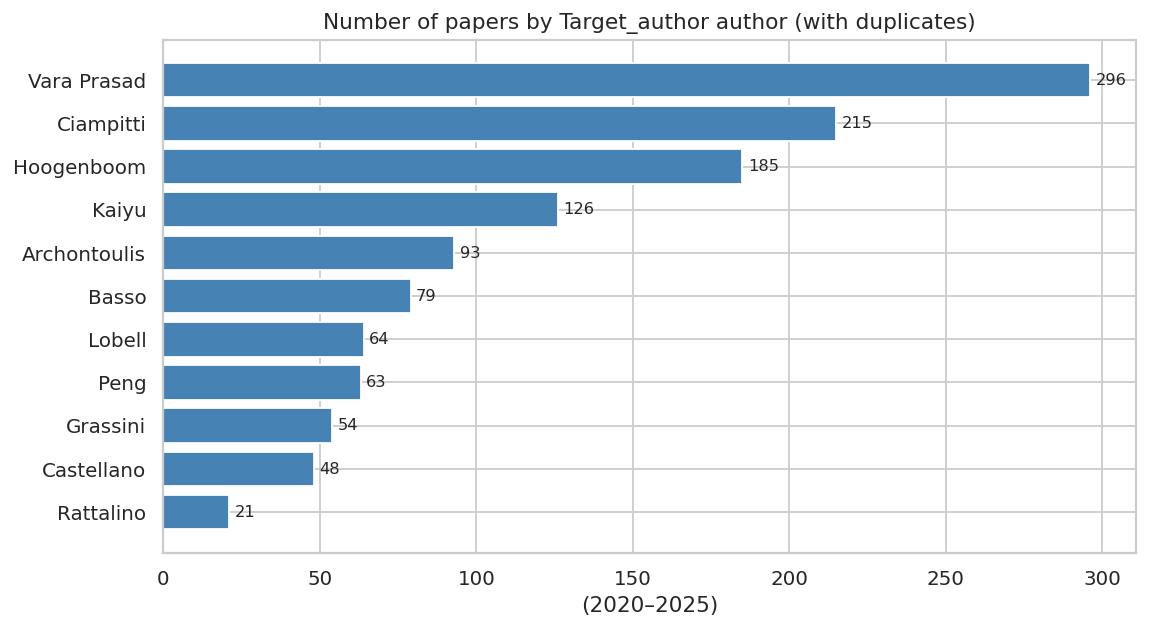

,queried_author,total_papers,avg_citations,corresponding
9,Ciampitti,215,21.697674,105
7,Kaiyu,126,45.674603,58
10,Vara Prasad,296,28.415541,31
6,Archontoulis,93,30.107527,26
2,Grassini,54,44.814815,24
4,Lobell,64,63.734375,18
5,Basso,79,35.683544,18
8,Hoogenboom,185,21.945946,11
3,Peng,63,42.873016,10
1,Castellano,48,39.500000,5


In [213]:
# ── Papers per Target_author author — total & yearly breakdown ─────────────────────
author_counts = (
     filtered_TargetA_df
    .groupby("queried_author")
    .agg(
        total_papers=("article_id", "count"),
        avg_citations=("total_citations", "mean"),
        corresponding=("is_corresponding_author", "sum"),
    )
    .sort_values("total_papers", ascending=True)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(author_counts["queried_author"], author_counts["total_papers"],
               color="steelblue", edgecolor="white")
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel("(2020–2025)")
ax.set_title("Number of papers by Target_author author (with duplicates)")
plt.tight_layout()
plt.show()
author_counts.sort_values('corresponding', ascending=False)


## Citation Analysis of Target Authors


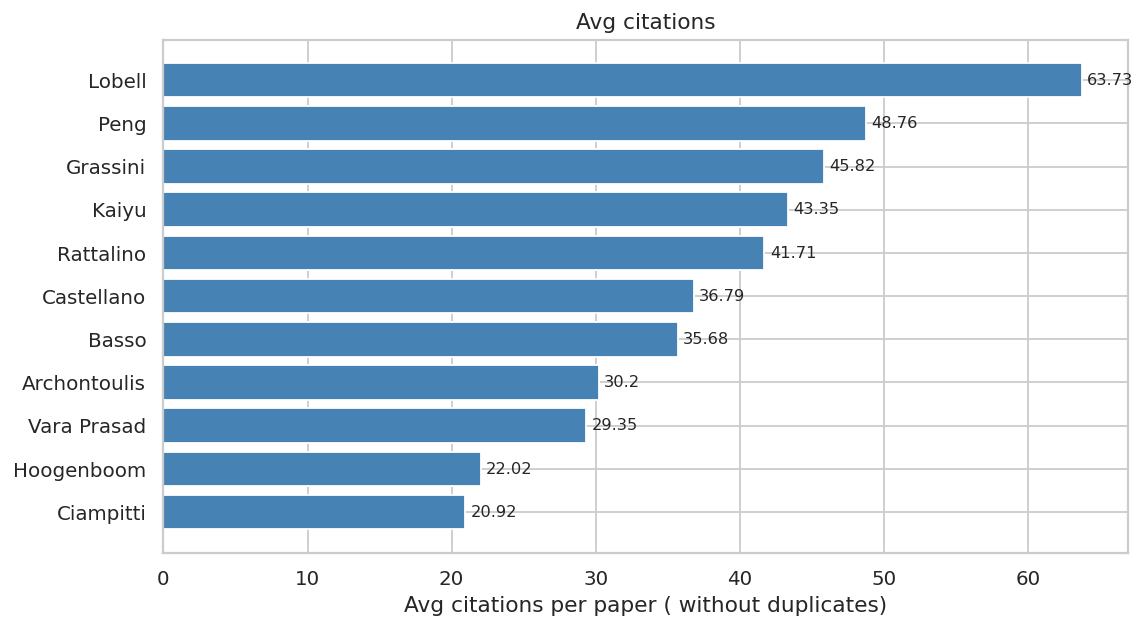

In [214]:
# ── Avg citations by Target author  ──
avg_cit_by_author = (
    filtered_TargetA_dedup.assign(total_citations=lambda d: d["total_citations"].fillna(0))
    .groupby("queried_author")["total_citations"]
    .mean()
    .sort_values(ascending=True)
    .round(2)
 )

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(avg_cit_by_author.index, avg_cit_by_author.values,
               color="steelblue", edgecolor="white")
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel("Avg citations per paper ( without duplicates)")
ax.set_title("Avg citations")
plt.tight_layout()
plt.show()

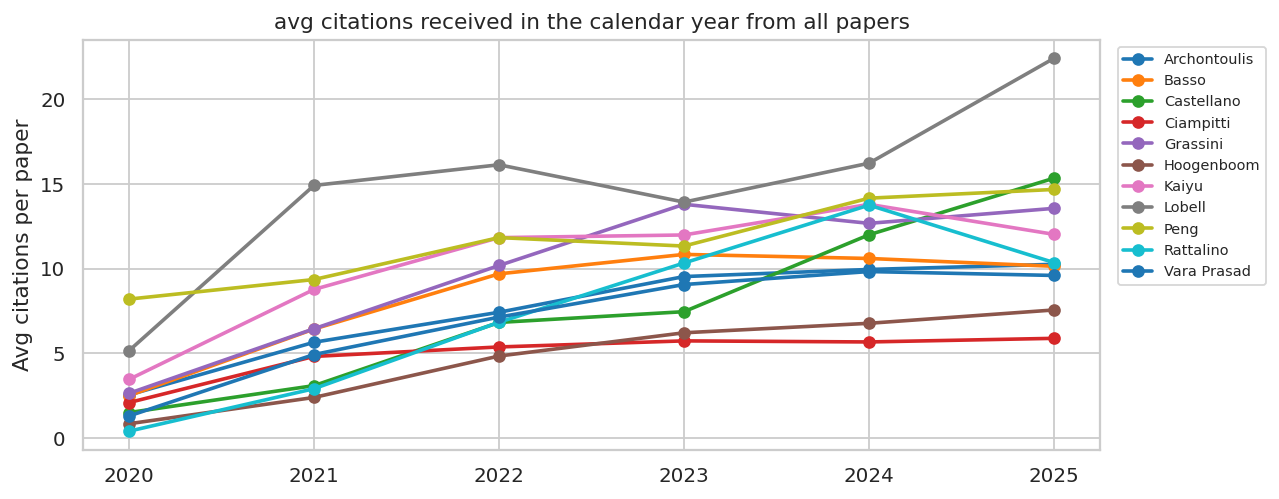

In [215]:
# ── Target-author time analysis (journals of interest, deduped) ────────────────
df_ta = filtered_TargetA_dedup.copy()
CURRENT_YEAR = 2026

# ---- Citations received per calendar year (total + average) ----
cit_year_cols = [c for c in df_ta.columns if c.startswith("citations_year_")]
melted_ta = (
    df_ta.dropna(subset=["publication_year"])[["article_id", "queried_author", "publication_year"] + cit_year_cols]
    .melt(id_vars=["article_id", "queried_author", "publication_year"],
          value_vars=cit_year_cols,
          var_name="cit_col", value_name="citations")
)
melted_ta["offset"] = melted_ta["cit_col"].str.extract(r"(\d+)$").astype(int)
melted_ta["calendar_year"] = melted_ta["publication_year"].astype(int) + melted_ta["offset"]
melted_ta["citations"] = melted_ta["citations"].fillna(0)
melted_ta = melted_ta[
    (melted_ta["calendar_year"] >= 2020)
    & (melted_ta["calendar_year"] <= CURRENT_YEAR - 1)
 ]

# ---- Citations per year by author (avg per paper) ----
top_authors = (
    df_ta.groupby("queried_author")["article_id"]
    .count()
    .sort_values(ascending=False)
    .head(11)
    .index.tolist()
 )
author_year_avg = (
    melted_ta[melted_ta["queried_author"].isin(top_authors)]
    .groupby(["queried_author", "calendar_year"])
    .agg(avg_cit=("citations", "mean"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
for author, grp in author_year_avg.groupby("queried_author"):
    grp = grp.sort_values("calendar_year")
    ax.plot(grp["calendar_year"], grp["avg_cit"], marker="o", linewidth=2, label=author)
ax.set_title("avg citations received in the calendar year from all papers")
# ax.set_xlabel("Calendar year")
ax.set_ylabel("Avg citations per paper")
ax.set_xticks(sorted(author_year_avg["calendar_year"].unique()))
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

#accumulated citations per calendar year

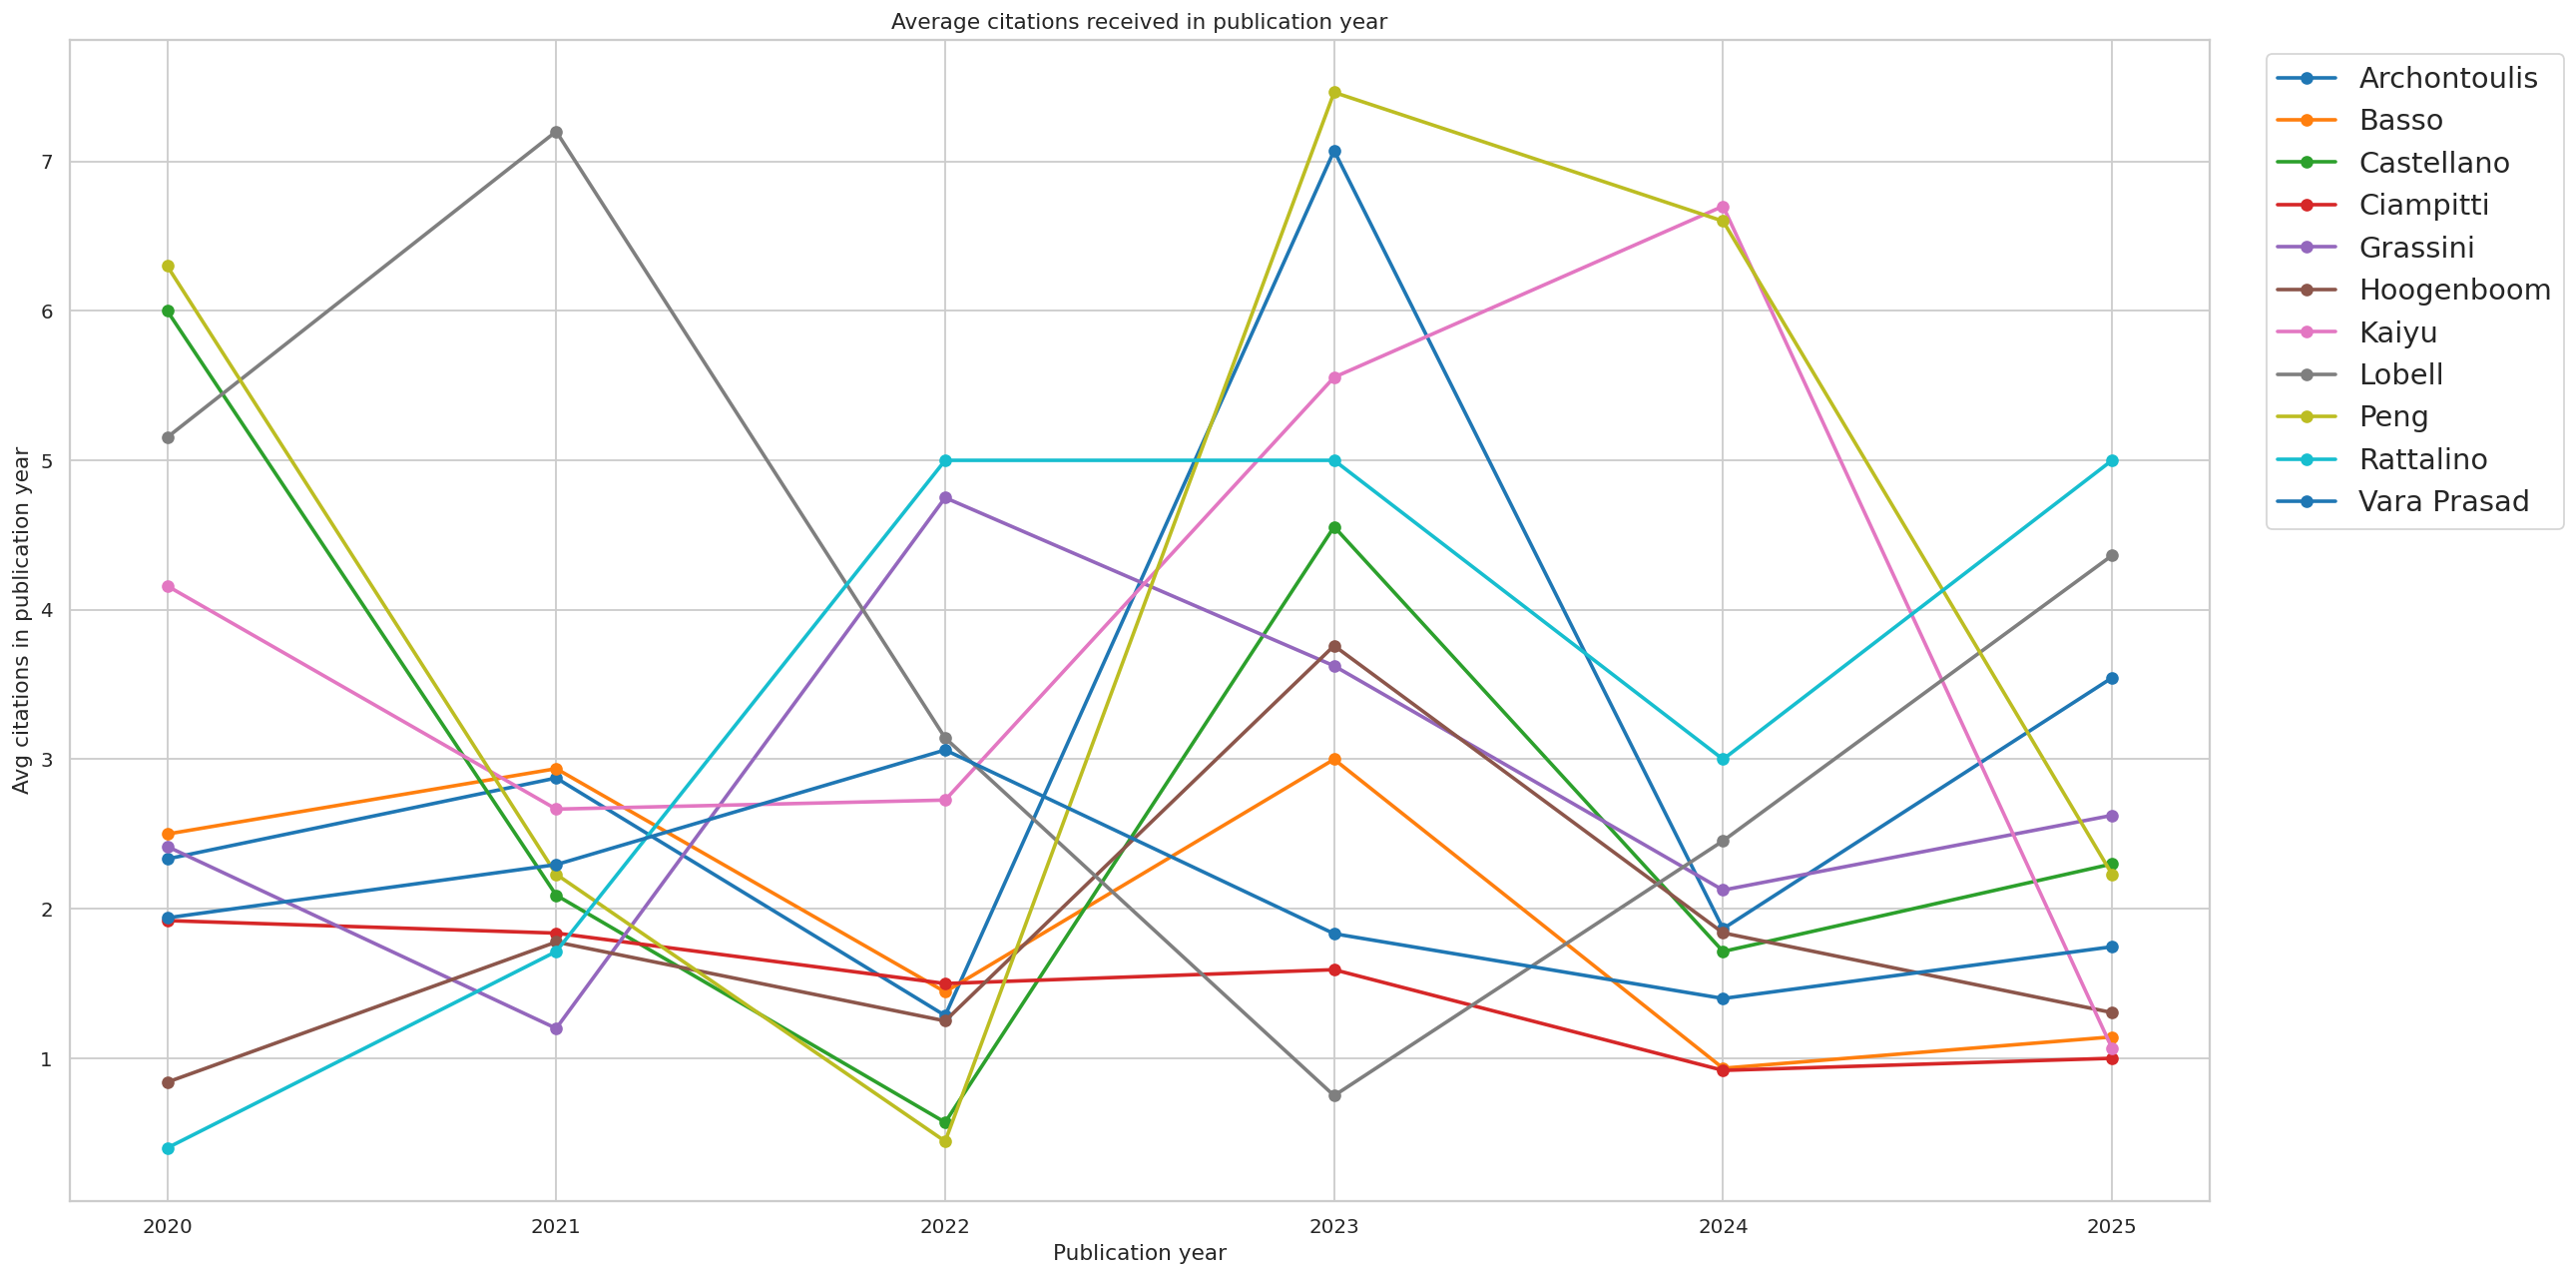

In [216]:
# ---- Same-year citations only (citations_year_0), per author ----
df_ta = filtered_TargetA_df.copy()

top_authors = (
    df_ta.groupby("queried_author")["article_id"]
    .count()
    .sort_values(ascending=False)
    .head(11)
    .index.tolist()
)

same_year = (
    df_ta[df_ta["queried_author"].isin(top_authors)]
    .dropna(subset=["publication_year"])
    .assign(cit_same_year=lambda d: d.get("citations_year_0", 0).fillna(0))
)

per_year = (
    same_year.groupby(["queried_author", "publication_year"])
    .agg(
        total_cit=("cit_same_year", "sum"),
        avg_cit=("cit_same_year", "mean"),
        n_papers=("article_id", "count"),
    )
    .reset_index()
)

fig, axes = plt.subplots( figsize=(20, 10))



# Right: average citations per paper in publication year
for author, grp in per_year.groupby("queried_author"):
    grp = grp.sort_values("publication_year")
    axes.plot(grp["publication_year"], grp["avg_cit"], marker="o", linewidth=2, label=author)

axes.set_title("Average citations received in publication year")
axes.set_xlabel("Publication year")
axes.set_ylabel("Avg citations in publication year")
axes.set_xticks(sorted(per_year["publication_year"].unique()))

axes.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Interactive chart: citations by year-of-life per author (Target authors, deduped)
try:
    import ipywidgets as widgets
except ImportError:
    print("ipywidgets not installed. Run: pip install ipywidgets")
    raise
from IPython.display import display, clear_output

year_labels = ["Year 1", "Year 2", "Year 3", "Year 4"]
year_columns = ["citations_year_0", "citations_year_1", "citations_year_2", "citations_year_3"]
year_offsets = [1, 2, 3, 4]

df_cit_src = (
    filtered_TargetA_dedup
    .dropna(subset=["queried_author", "publication_year"])
    .copy()
 )
df_cit_src["publication_year"] = df_cit_src["publication_year"].astype(int)

cit_authors = sorted(df_cit_src["queried_author"].unique().tolist())
author_cit_widget = widgets.Combobox(
    options=cit_authors,
    placeholder="Type last name",
    description="Author:",
    ensure_option=False,
    continuous_update=True,
 )
out_cit = widgets.Output()

def _resolve_author_cit(input_text: str | None):
    text = (input_text or "").strip()
    if not text:
        return None, "Type an author last name to filter."
    matches = [a for a in cit_authors if text.lower() in a.lower()]
    if len(matches) == 1:
        return matches[0], None
    exact = [a for a in matches if a.lower() == text.lower()]
    if len(exact) == 1:
        return exact[0], None
    if len(matches) == 0:
        return None, f"No author match for '{text}'."
    return None, "Multiple matches: " + ", ".join(matches)

def _calc_author_year_life(author_name: str):
    df_author = df_cit_src[df_cit_src["queried_author"] == author_name]
    rows = []
    for label, col, offset in zip(year_labels, year_columns, year_offsets):
        eligible = df_author[df_author["publication_year"] <= CURRENT_YEAR - offset]
        n_papers = len(eligible)
        avg_cit = eligible[col].fillna(0).mean() if n_papers > 0 else np.nan
        rows.append({"year_label": label, "avg_citations": avg_cit, "n_papers": n_papers})
    return pd.DataFrame(rows)

def _render_cit(_change=None):
    with out_cit:
        clear_output()
        selected, msg = _resolve_author_cit(author_cit_widget.value)
        if msg:
            print(msg)
            return
        data = _calc_author_year_life(selected)
        if data["n_papers"].sum() == 0:
            print("No eligible papers for this author.")
            return
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(data["year_label"], data["avg_citations"], marker="o", linewidth=2, color="steelblue")
        ax.set_title(f"{selected}: average citations by paper year-of-life")
        ax.set_xlabel("Paper year-of-life")
        ax.set_ylabel("Avg citations (that year only)")
        ax.set_ylim(0, max(1, np.nanmax(data["avg_citations"]) * 1.25))
        for x, y, n in zip(data["year_label"], data["avg_citations"], data["n_papers"]):
            if np.isfinite(y):
                ax.text(x, y + 0.03, f"n={n}", ha="center", va="bottom", fontsize=8, color="dimgray")
        plt.tight_layout()
        plt.show()
        display(data.assign(avg_citations=data["avg_citations"].round(2)))

author_cit_widget.observe(_render_cit, names="value")
display(widgets.VBox([
    widgets.HTML("<b>Average citations by year-of-life</b>"),
    author_cit_widget,
    out_cit,
 ]))
_render_cit()

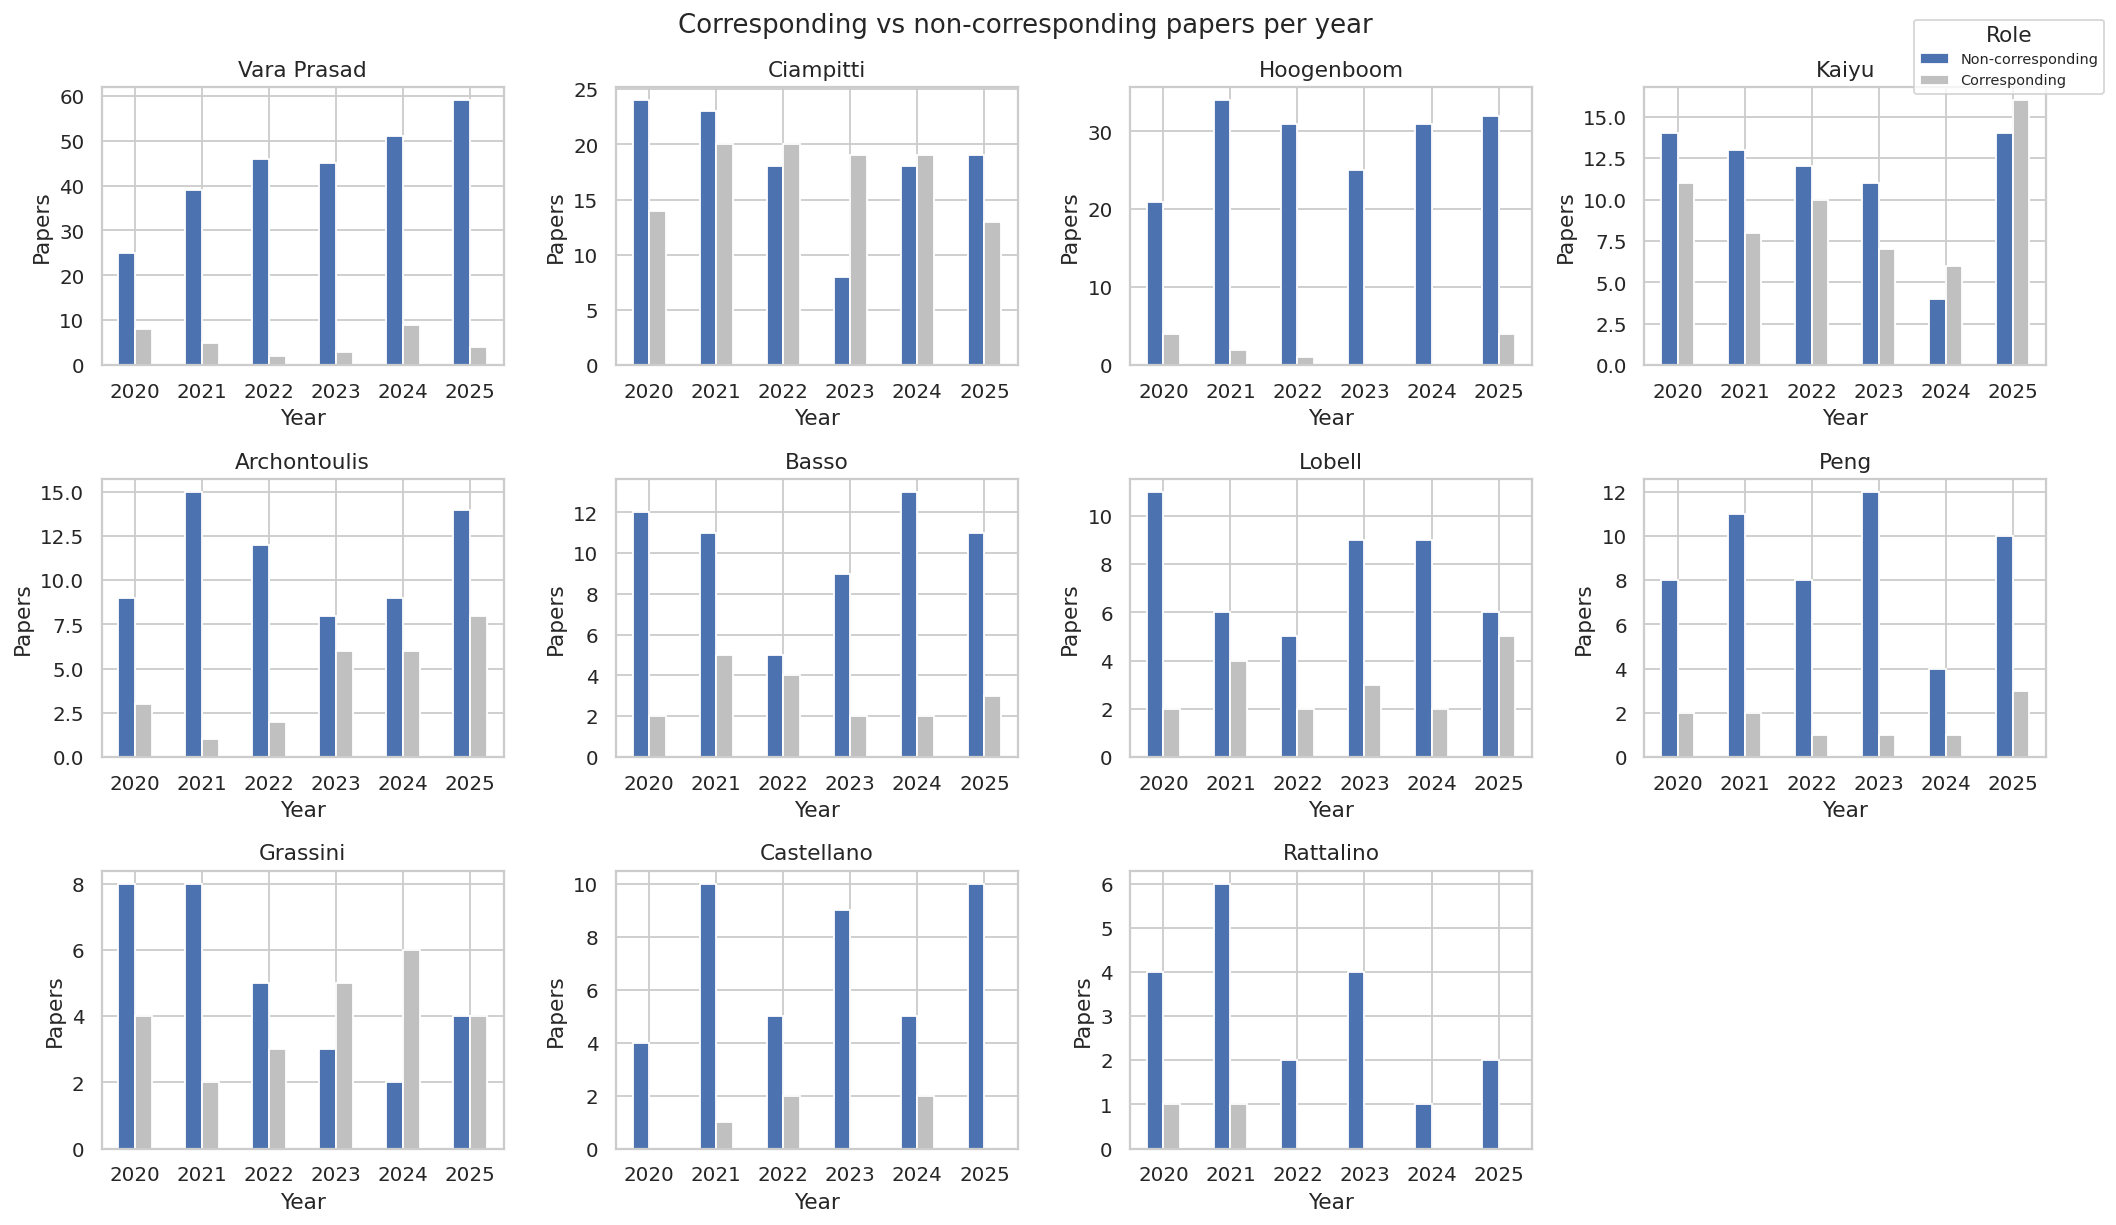

In [218]:


# ---- Corresponding vs non-corresponding papers per year by author ----
top_authors = (
    df_ta.groupby("queried_author")["article_id"]
    .count()
    .sort_values(ascending=False)
    .head(11)
    .index.tolist()
)

corr_year_author = (
    df_ta[df_ta["queried_author"].isin(top_authors)]
    .dropna(subset=["publication_year"])
    .groupby(["queried_author", "publication_year", "is_corresponding_author"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={True: "Corresponding", False: "Non-corresponding"})
)

n_authors = len(top_authors)
ncols = 4
nrows = int(np.ceil(n_authors / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows), squeeze=False)
axes_flat = axes.flatten()

for i, author in enumerate(top_authors):
    ax = axes_flat[i]
    data = corr_year_author.loc[author].sort_index()
    data.plot(kind="bar", stacked=False, ax=ax, color=["#4C72B0", "#C0C0C0"], edgecolor="white", legend=False)
    ax.set_title(author)
    ax.set_xlabel("Year")
    ax.set_ylabel("Papers")
    ax.tick_params(axis="x", rotation=0)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("Corresponding vs non-corresponding papers per year ")
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.02, 0.98), fontsize=8, title="Role")
plt.tight_layout()
plt.show()

## Topic Analysis

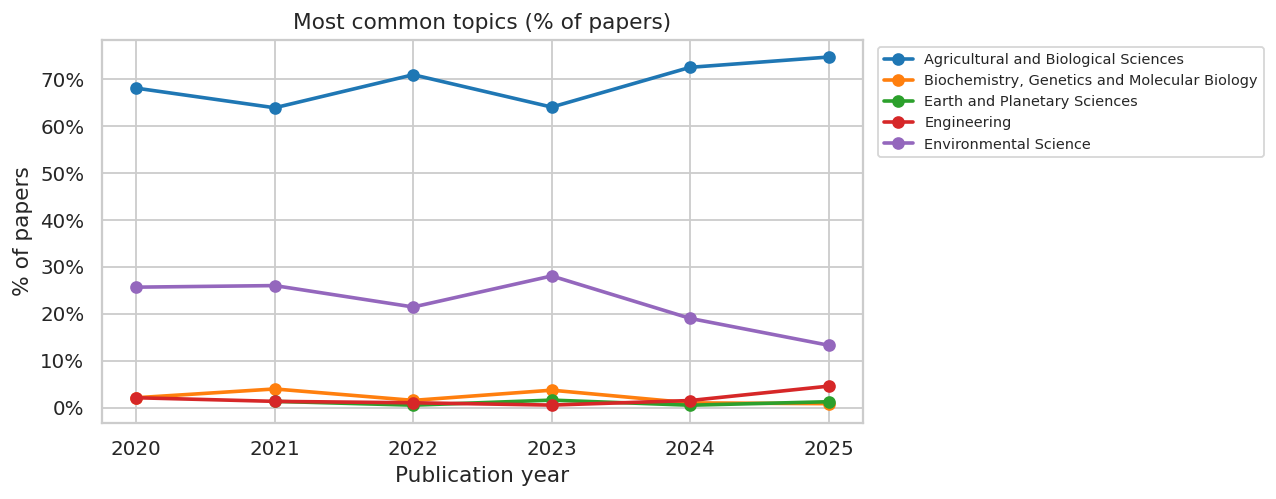

In [219]:
# ---- Topic trends over time (topic_field) ----
topic_col = "topic_field"
top_fields = (
    df_ta.dropna(subset=[topic_col])
    .groupby(topic_col)["article_id"].count()
    .nlargest(5).index.tolist()
 )

topic_year = (
    df_ta.dropna(subset=[topic_col, "publication_year"])
    .query("topic_field in @top_fields")
    .groupby(["publication_year", topic_col])
    .size()
    .reset_index(name="n")
 )
total_per_year = (
    df_ta.dropna(subset=["publication_year"])
    .groupby("publication_year")["article_id"].count()
    .rename("total")
 )
topic_year = topic_year.merge(total_per_year.reset_index(), on="publication_year")
topic_year["pct"] = topic_year["n"] / topic_year["total"] * 100

# Remove topics that are zero in at least 3 years
topic_pivot = topic_year.pivot_table(
    index=topic_col,
    columns="publication_year",
    values="n",
    fill_value=0,
)
zero_years = (topic_pivot == 0).sum(axis=1)
kept_topics = zero_years[zero_years < 3].index
topic_year = topic_year[topic_year[topic_col].isin(kept_topics)]

# print("Exact % of papers by topic and year (after filtering):")
# print(
#     topic_year
#     .sort_values(["publication_year", topic_col])
#     [["publication_year", topic_col, "n", "total", "pct"]]
#     .to_string(index=False)
# )

fig, ax = plt.subplots(figsize=(10, 4))
for field, grp in topic_year.groupby(topic_col):
    grp = grp.sort_values("publication_year")
    ax.plot(grp["publication_year"], grp["pct"], marker="o", linewidth=2, label=field)
ax.set_title("Most common topics (% of papers)")
ax.set_xlabel("Publication year")
ax.set_ylabel("% of papers")
ax.set_xticks(sorted(topic_year["publication_year"].unique()))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### Dominant subfield per author per year (interactive)
Run the cell below once, then use the dropdown to view a single author without re-running the cell.

In [274]:
# Interactive table: dominant subfield per author per year (target authors, duplicates kept)
try:
    import ipywidgets as widgets
except ImportError:
    print("ipywidgets not installed. Run: pip install ipywidgets")
    raise
from IPython.display import display, clear_output

topic_col_for_year = "topic_subfield"

df_topic_src = (
    filtered_TargetA_df
    .dropna(subset=["queried_author", "publication_year", topic_col_for_year])
    .copy()
 )
df_topic_src["publication_year"] = df_topic_src["publication_year"].astype(int)

topic_year_counts = (
    df_topic_src
    .groupby(["queried_author", "publication_year", topic_col_for_year])
    .size()
    .reset_index(name="n_papers")
 )

dominant_by_year = (
    topic_year_counts
    .sort_values(
        ["queried_author", "publication_year", "n_papers", topic_col_for_year],
        ascending=[True, True, False, True],
    )
    .groupby(["queried_author", "publication_year"])
    .head(1)
    .rename(columns={topic_col_for_year: "dominant_topic"})
    .reset_index(drop=True)
 )

authors = sorted(dominant_by_year["queried_author"].unique().tolist())
author_widget = widgets.Combobox(
    options=authors,
    placeholder="Type last name",
    description="Author:",
    ensure_option=False,
    continuous_update=True,
 )
out = widgets.Output()

def _resolve_author(input_text: str | None):
    text = (input_text or "").strip()
    if not text:
        return None, "Type an author last name to filter."
    matches = [a for a in authors if text.lower() in a.lower()]
    if len(matches) == 1:
        return matches[0], None
    exact = [a for a in matches if a.lower() == text.lower()]
    if len(exact) == 1:
        return exact[0], None
    if len(matches) == 0:
        return None, f"No author match for '{text}'."
    return None, "Multiple matches: " + ", ".join(matches)

def _render(_change=None):
    with out:
        clear_output()
        selected, msg = _resolve_author(author_widget.value)
        if msg:
            print(msg)
            return
        view = (
            dominant_by_year[dominant_by_year["queried_author"] == selected]
            .sort_values("publication_year")
            [["publication_year", "dominant_topic", "n_papers"]]
            .reset_index(drop=True)
        )
        display(view)

author_widget.observe(_render, names="value")
display(widgets.VBox([
    widgets.HTML("<b>Dominant subfield per year</b>"),
    author_widget,
    out,
 ]))
_render()

In [221]:
# # ── Author position breakdown (pie – proportions) ─────────────────────────────
# pos_counts = (
#     filtered_TargetA_dedup
#     .groupby(["queried_author", "author_position"])
#     .size()
#     .unstack(fill_value=0)
# )
# pos_order = ["first", "middle", "last"]
# pos_counts = pos_counts.reindex(columns=[c for c in pos_order if c in pos_counts.columns])

# colors = {"first": "#4C72B0", "middle": "#C0C0C0", "last": "#DD8452"}

# n_authors = len(pos_counts)
# ncols = min(3, n_authors)
# nrows = int(np.ceil(n_authors / ncols))

# fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
# axes_flat = axes.flatten()

# for i, (author_name, row) in enumerate(pos_counts.iterrows()):
#     row = row[row > 0]
#     col_colors = [colors.get(c, "gray") for c in row.index]
#     axes_flat[i].pie(
#         row.values,
#         labels=row.index,
#         colors=col_colors,
#         autopct="%1.1f%%",
#         startangle=90,
#         wedgeprops={"edgecolor": "white"},
#     )
#     axes_flat[i].set_title(author_name)

# for j in range(i + 1, len(axes_flat)):
#     axes_flat[j].set_visible(False)

# fig.suptitle("Author position breakdown per Target_author author (proportion)", fontsize=13)
# plt.tight_layout()
# plt.show()

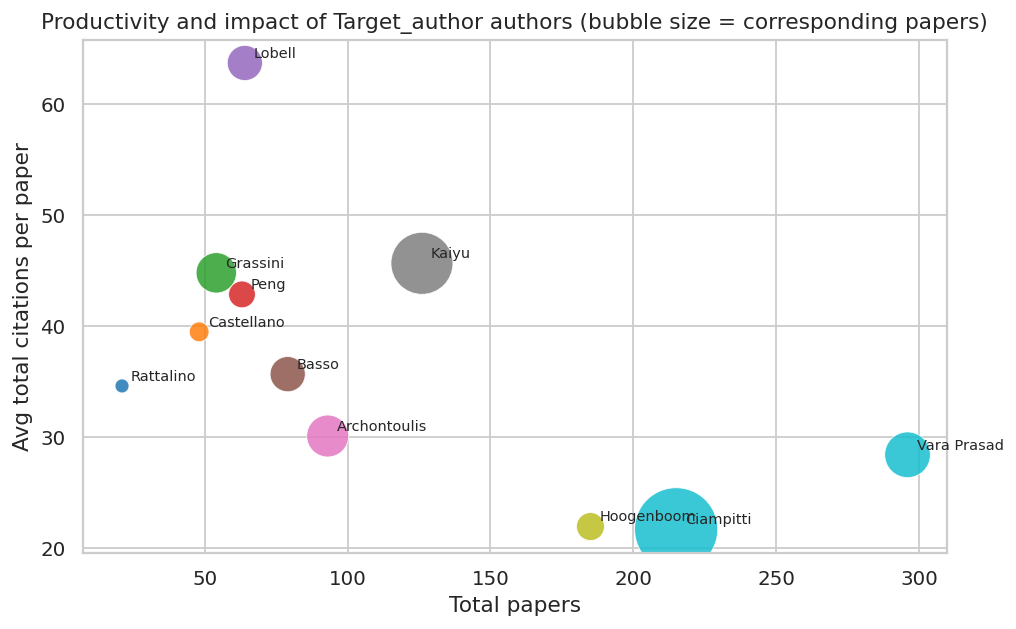

In [222]:
# ── Ranked dot plot: papers count vs avg citations per Target_author author ─────────
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    author_counts["total_papers"],
    author_counts["avg_citations"],
    s=author_counts["corresponding"]*20 + 20,  # bubble size based on corresponding-author count
    c=range(len(author_counts)),
    cmap="tab10",
    alpha=0.85,
    edgecolors="white",
    linewidths=0.5,
)
for _, row in author_counts.iterrows():
    ax.annotate(row["queried_author"], 
                xy=(row["total_papers"], row["avg_citations"]),
                xytext=(5, 3), textcoords="offset points", fontsize=8)
ax.set_xlabel("Total papers")
ax.set_ylabel("Avg total citations per paper")
ax.set_title("Productivity and impact of Target_author authors (bubble size = corresponding papers)")
plt.tight_layout()
plt.show()
#Solo contar paper donde son crresponding

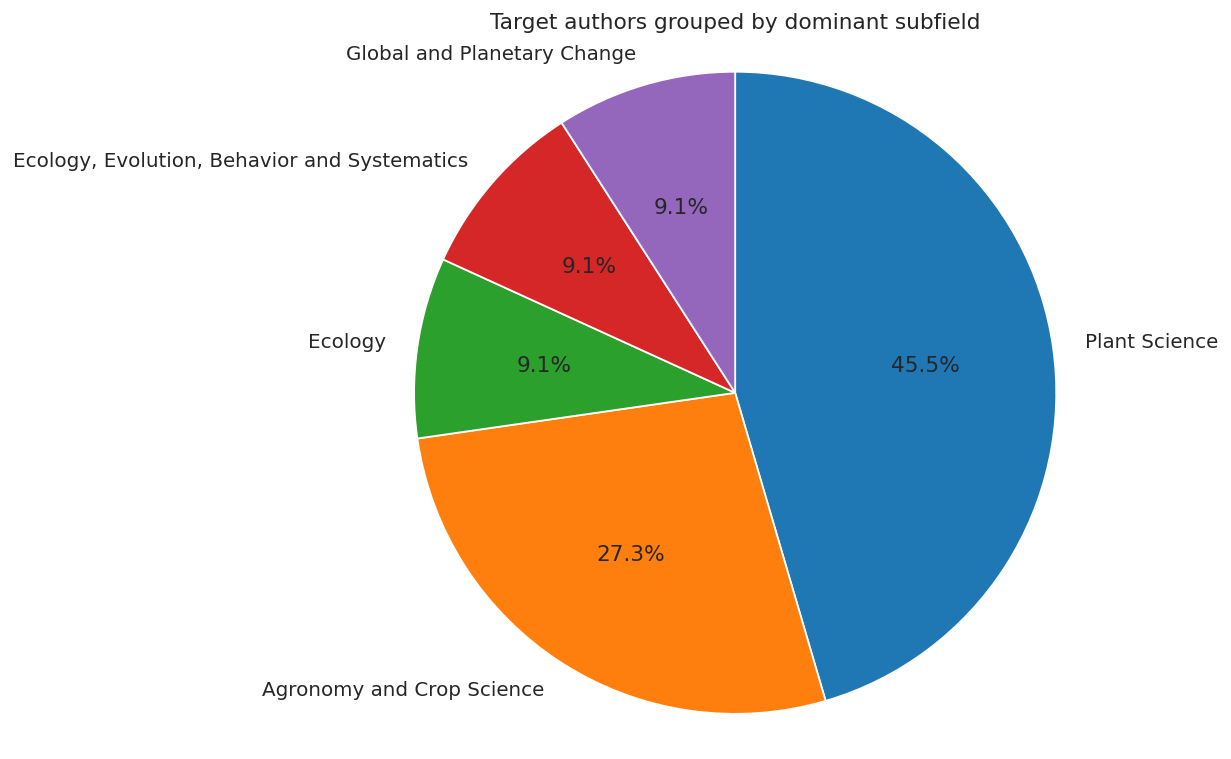

topic_subfield
Plant Science                                   5
Agronomy and Crop Science                       3
Ecology                                         1
Ecology, Evolution, Behavior and Systematics    1
Global and Planetary Change                     1
Name: queried_author, dtype: int64


,queried_author,topic_subfield,n
0,Archontoulis,Agronomy and Crop Science,37
1,Basso,Agronomy and Crop Science,13
2,Castellano,Agronomy and Crop Science,11
3,Ciampitti,Plant Science,73
4,Grassini,Plant Science,22
5,Hoogenboom,Plant Science,63
6,Kaiyu,Ecology,32
7,Lobell,"Ecology, Evolution, Behavior and Systematics",12
8,Peng,Global and Planetary Change,13
9,Rattalino,Plant Science,9


In [223]:
specific_topic_col = "topic_subfield"
dominant_topic = (
    df_ta.dropna(subset=["queried_author", specific_topic_col])
    .groupby(["queried_author", specific_topic_col])
    .size()
    .reset_index(name="n")
    .sort_values(["queried_author", "n"], ascending=[True, False])
    .groupby("queried_author").head(1).reset_index(drop=True)
 )

topic_counts = (
    dominant_topic.groupby(specific_topic_col)["queried_author"]
    .nunique()
    .sort_values(ascending=False)
 )

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(
    topic_counts.values,
    labels=topic_counts.index.astype(str),
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white"},
 )
ax.set_title("Target authors grouped by dominant subfield")
ax.axis("equal")
plt.tight_layout()
plt.show()

# fig, ax = plt.subplots(figsize=(9, 6))
# bars = ax.barh(dominant_topic["queried_author"], dominant_topic["n"], color="red", edgecolor="white")
# ax.bar_label(bars, padding=3, fontsize=8)

# ax.set_title("Target authors: each author's most-written topic")
# ax.set_xlabel("Papers in top topic")
# plt.tight_layout()
# plt.show()
print(topic_counts)
dominant_topic

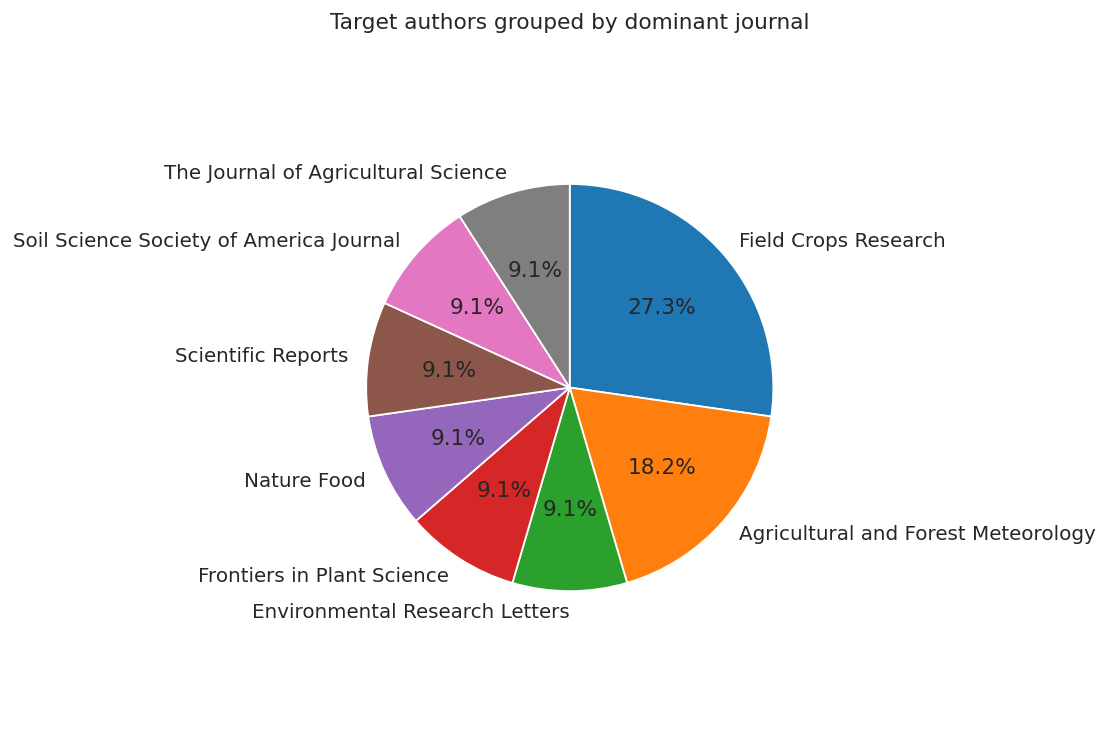

top_journal
Field Crops Research                       3
Agricultural and Forest Meteorology        2
Environmental Research Letters             1
Frontiers in Plant Science                 1
Nature Food                                1
Scientific Reports                         1
Soil Science Society of America Journal    1
The Journal of Agricultural Science        1
Name: queried_author, dtype: int64


,queried_author,top_journal,n_papers
0,Archontoulis,Field Crops Research,13
1,Basso,Scientific Reports,5
2,Castellano,Soil Science Society of America Journal,3
3,Ciampitti,Field Crops Research,30
4,Grassini,Field Crops Research,11
5,Hoogenboom,The Journal of Agricultural Science,16
6,Kaiyu,Agricultural and Forest Meteorology,14
7,Lobell,Environmental Research Letters,9
8,Peng,Agricultural and Forest Meteorology,5
9,Rattalino,Nature Food,3


In [224]:
# ── Most-published journal per Target_author author ─────────────────────────────────
top_journal_per_author = (
    filtered_TargetA_dedup.dropna(subset=["journal_display_name"])
    .groupby(["queried_author", "journal_display_name"])
    .size()
    .reset_index(name="n_papers")
    .sort_values("n_papers", ascending=False)
    .groupby("queried_author")
    .first()
    .reset_index()
    .rename(columns={"journal_display_name": "top_journal"})
    [["queried_author", "top_journal", "n_papers"]]
)

journal_counts = (
    top_journal_per_author.groupby("top_journal")["queried_author"]
    .nunique()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(
    journal_counts.values,
    labels=journal_counts.index.astype(str),
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white"},
 )
ax.set_title("Target authors grouped by dominant journal")
ax.axis("equal")
plt.tight_layout()
plt.show()
# fig, ax = plt.subplots(figsize=(10, 5))
# bars = ax.barh(
#     top_journal_per_author["queried_author"],
#     top_journal_per_author["n_papers"],
#     color="steelblue", edgecolor="white"
# )
# ax.bar_label(bars, padding=3, fontsize=8)

# ax.set_xlabel("Papers in top journal")
# ax.set_title("Most-published journal per Target_author author")
# plt.tight_layout()
# plt.show()
print(journal_counts)

top_journal_per_author


In [225]:
# # ── Avg citations by Target author (duplicates included, journals of interest) ──
# avg_cit_by_author = (
#     filtered_TargetA_df.assign(total_citations=lambda d: d["total_citations"].fillna(0))
#     .groupby("queried_author")["total_citations"]
#     .mean()
#     .sort_values(ascending=True)
#     .round(2)
#  )

# fig, ax = plt.subplots(figsize=(9, 5))
# bars = ax.barh(avg_cit_by_author.index, avg_cit_by_author.values,
#                color="steelblue", edgecolor="white")
# ax.bar_label(bars, padding=3, fontsize=9)
# ax.set_xlabel("Avg citations per paper (duplicates included)")
# ax.set_title("Avg citations per Target author")
# plt.tight_layout()
# plt.show()


---
# CoAuthors Analysis

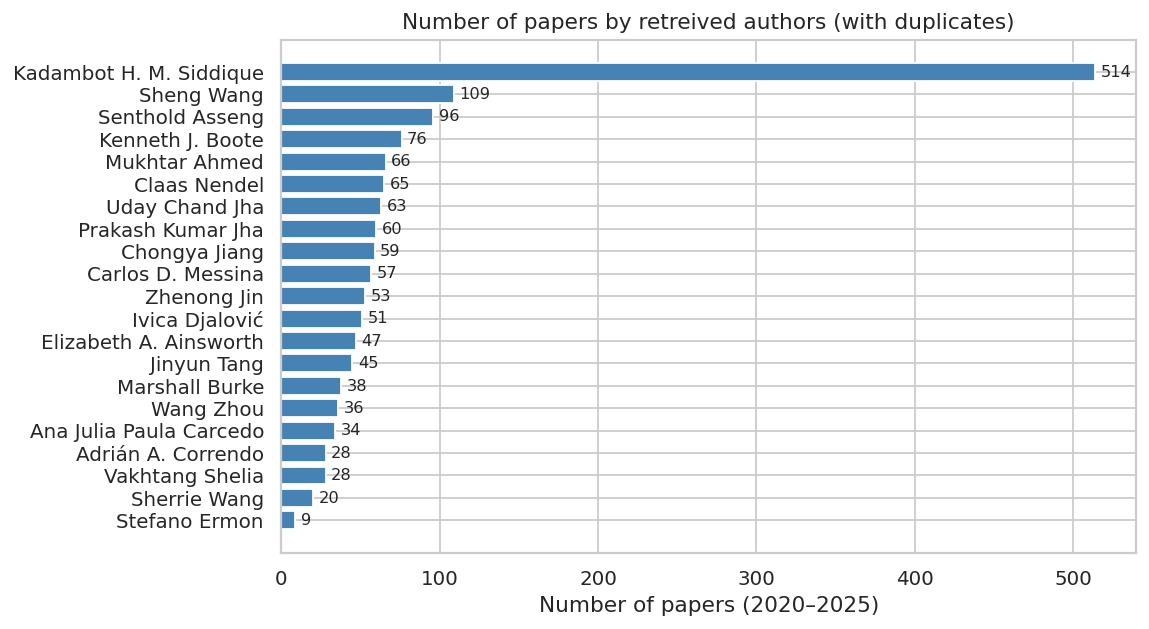

,queried_author,total_papers,avg_citations,corresponding
20,Kadambot H. M. Siddique,514,32.503891,61
14,Uday Chand Jha,63,30.841270,30
9,Ivica Djalović,51,15.941176,21
19,Sheng Wang,109,23.899083,20
16,Mukhtar Ahmed,66,35.515152,19
10,Zhenong Jin,53,49.943396,19
18,Senthold Asseng,96,43.875000,16
3,Adrián A. Correndo,28,19.035714,11
11,Carlos D. Messina,57,34.894737,11
8,Elizabeth A. Ainsworth,47,53.659574,10


In [226]:
# ── Papers per Target_author author — total & yearly breakdown ─────────────────────
Coauthor_counts = (
     filtered_coauthors_df
    .groupby("queried_author")
    .agg(
        total_papers=("article_id", "count"),
        avg_citations=("total_citations", "mean"),
        corresponding=("is_corresponding_author", "sum"),
    )
    .sort_values("total_papers", ascending=True)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(Coauthor_counts["queried_author"], Coauthor_counts["total_papers"],
               color="steelblue", edgecolor="white")
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel("Number of papers (2020–2025)")
ax.set_title("Number of papers by retreived authors (with duplicates)")
plt.tight_layout()
plt.show()
Coauthor_counts.sort_values('corresponding', ascending=False)


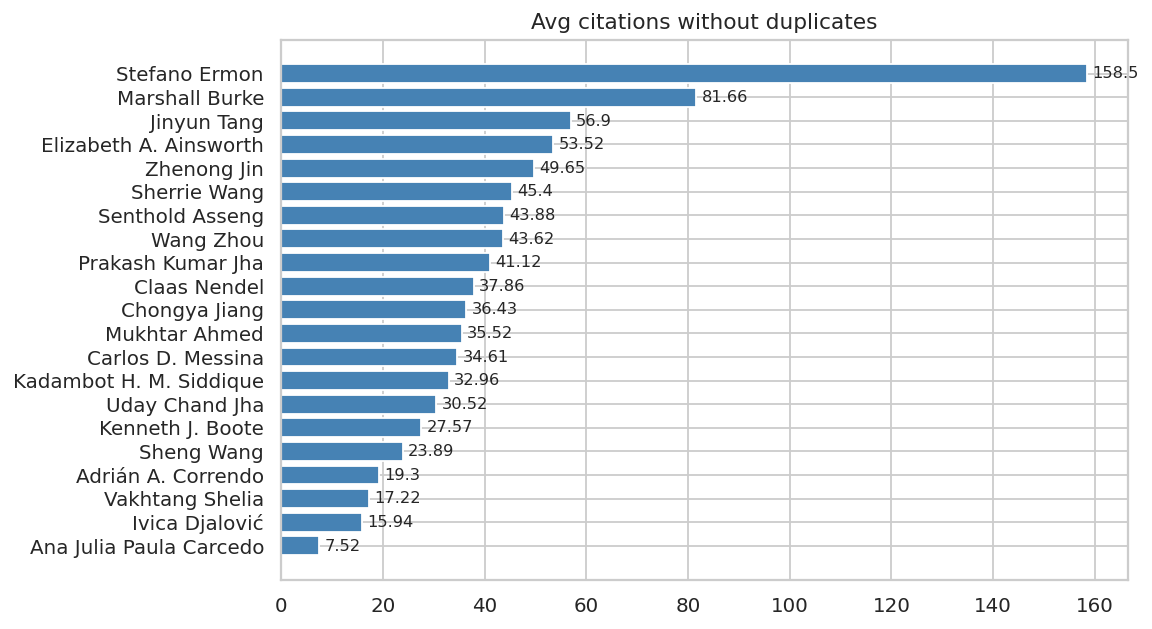

In [227]:
# ── Avg citations by Target author  ──
avg_cit_by_author = (
    filtered_coauthors_dedup.assign(total_citations=lambda d: d["total_citations"].fillna(0))
    .groupby("queried_author")["total_citations"]
    .mean()
    .sort_values(ascending=True)
    .round(2)
 )

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(avg_cit_by_author.index, avg_cit_by_author.values,
               color="steelblue", edgecolor="white")
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title("Avg citations without duplicates")
plt.tight_layout()
plt.show()

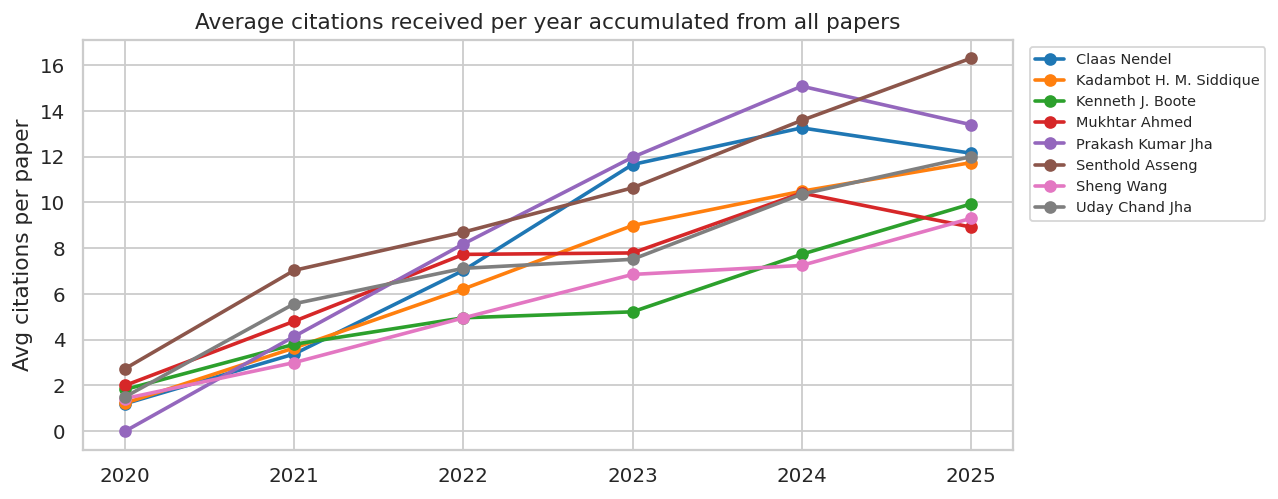

In [228]:
# ── Target-author time analysis (journals of interest, deduped) ────────────────
df_ca = filtered_coauthors_dedup.copy()
CURRENT_YEAR = 2026

# ---- Citations received per calendar year (total + average) ----
cit_year_cols = [c for c in df_ca.columns if c.startswith("citations_year_")]
melted_ca = (
    df_ca.dropna(subset=["publication_year"])[["article_id", "queried_author", "publication_year"] + cit_year_cols]
    .melt(id_vars=["article_id", "queried_author", "publication_year"],
          value_vars=cit_year_cols,
          var_name="cit_col", value_name="citations")
)
melted_ca["offset"] = melted_ca["cit_col"].str.extract(r"(\d+)$").astype(int)
melted_ca["calendar_year"] = melted_ca["publication_year"].astype(int) + melted_ca["offset"]
melted_ca["citations"] = melted_ca["citations"].fillna(0)
melted_ca = melted_ca[
    (melted_ca["calendar_year"] >= 2020)
    & (melted_ca["calendar_year"] <= CURRENT_YEAR - 1)
 ]

# ---- Citations per year by author (avg per paper) ----
top_authors = (
    df_ca.groupby("queried_author")["article_id"]
    .count()
    .sort_values(ascending=False)
    .head(8)
    .index.tolist()
 )
author_year_avg = (
    melted_ca[melted_ca["queried_author"].isin(top_authors)]
    .groupby(["queried_author", "calendar_year"])
    .agg(avg_cit=("citations", "mean"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
for author, grp in author_year_avg.groupby("queried_author"):
    grp = grp.sort_values("calendar_year")
    ax.plot(grp["calendar_year"], grp["avg_cit"], marker="o", linewidth=2, label=author)
ax.set_title("Average citations received per year accumulated from all papers")
ax.set_ylabel("Avg citations per paper")
ax.set_xticks(sorted(author_year_avg["calendar_year"].unique()))
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

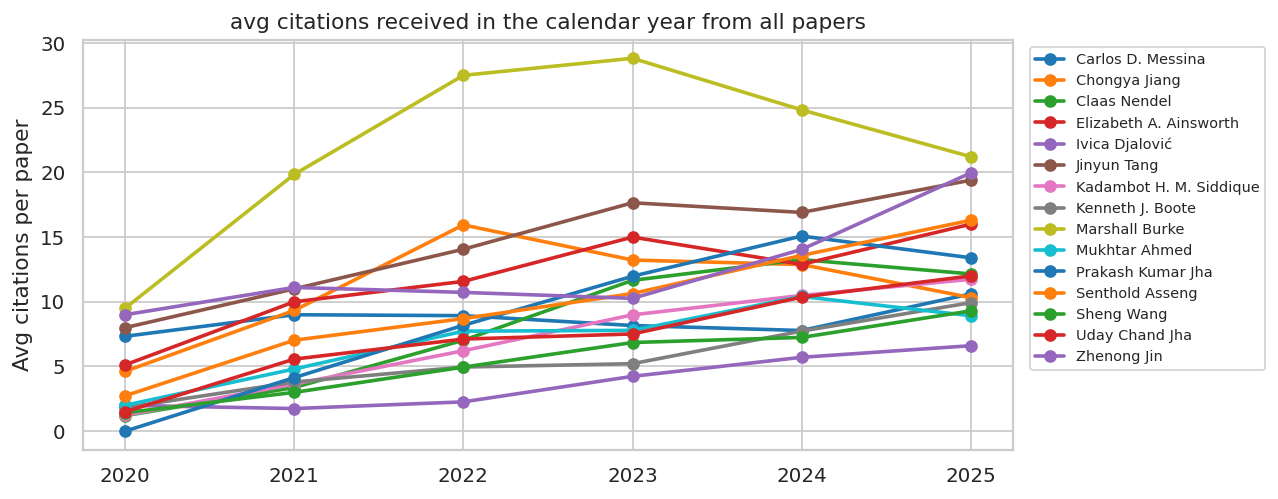

In [229]:
# ── Target-author time analysis (journals of interest, deduped) ────────────────
df_ca = filtered_coauthors_dedup.copy()
CURRENT_YEAR = 2026

# ---- Citations received per calendar year (total + average) ----
cit_year_cols = [c for c in df_ca.columns if c.startswith("citations_year_")]
melted_ca = (
    df_ca.dropna(subset=["publication_year"])[["article_id", "queried_author", "publication_year"] + cit_year_cols]
    .melt(id_vars=["article_id", "queried_author", "publication_year"],
          value_vars=cit_year_cols,
          var_name="cit_col", value_name="citations")
)
melted_ca["offset"] = melted_ca["cit_col"].str.extract(r"(\d+)$").astype(int)
melted_ca["calendar_year"] = melted_ca["publication_year"].astype(int) + melted_ca["offset"]
melted_ca["citations"] = melted_ca["citations"].fillna(0)
melted_ca = melted_ca[
    (melted_ca["calendar_year"] >= 2020)
    & (melted_ca["calendar_year"] <= CURRENT_YEAR - 1)
 ]

# ---- Citations per year by author (avg per paper) ----
top_authors = (
    df_ca.groupby("queried_author")["article_id"]
    .count()
    .sort_values(ascending=False)
    .head(15)
    .index.tolist()
 )
author_year_avg = (
    melted_ca[melted_ca["queried_author"].isin(top_authors)]
    .groupby(["queried_author", "calendar_year"])
    .agg(avg_cit=("citations", "mean"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
for author, grp in author_year_avg.groupby("queried_author"):
    grp = grp.sort_values("calendar_year")
    ax.plot(grp["calendar_year"], grp["avg_cit"], marker="o", linewidth=2, label=author)
ax.set_title("avg citations received in the calendar year from all papers")
# ax.set_xlabel("Calendar year")
ax.set_ylabel("Avg citations per paper")
ax.set_xticks(sorted(author_year_avg["calendar_year"].unique()))
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


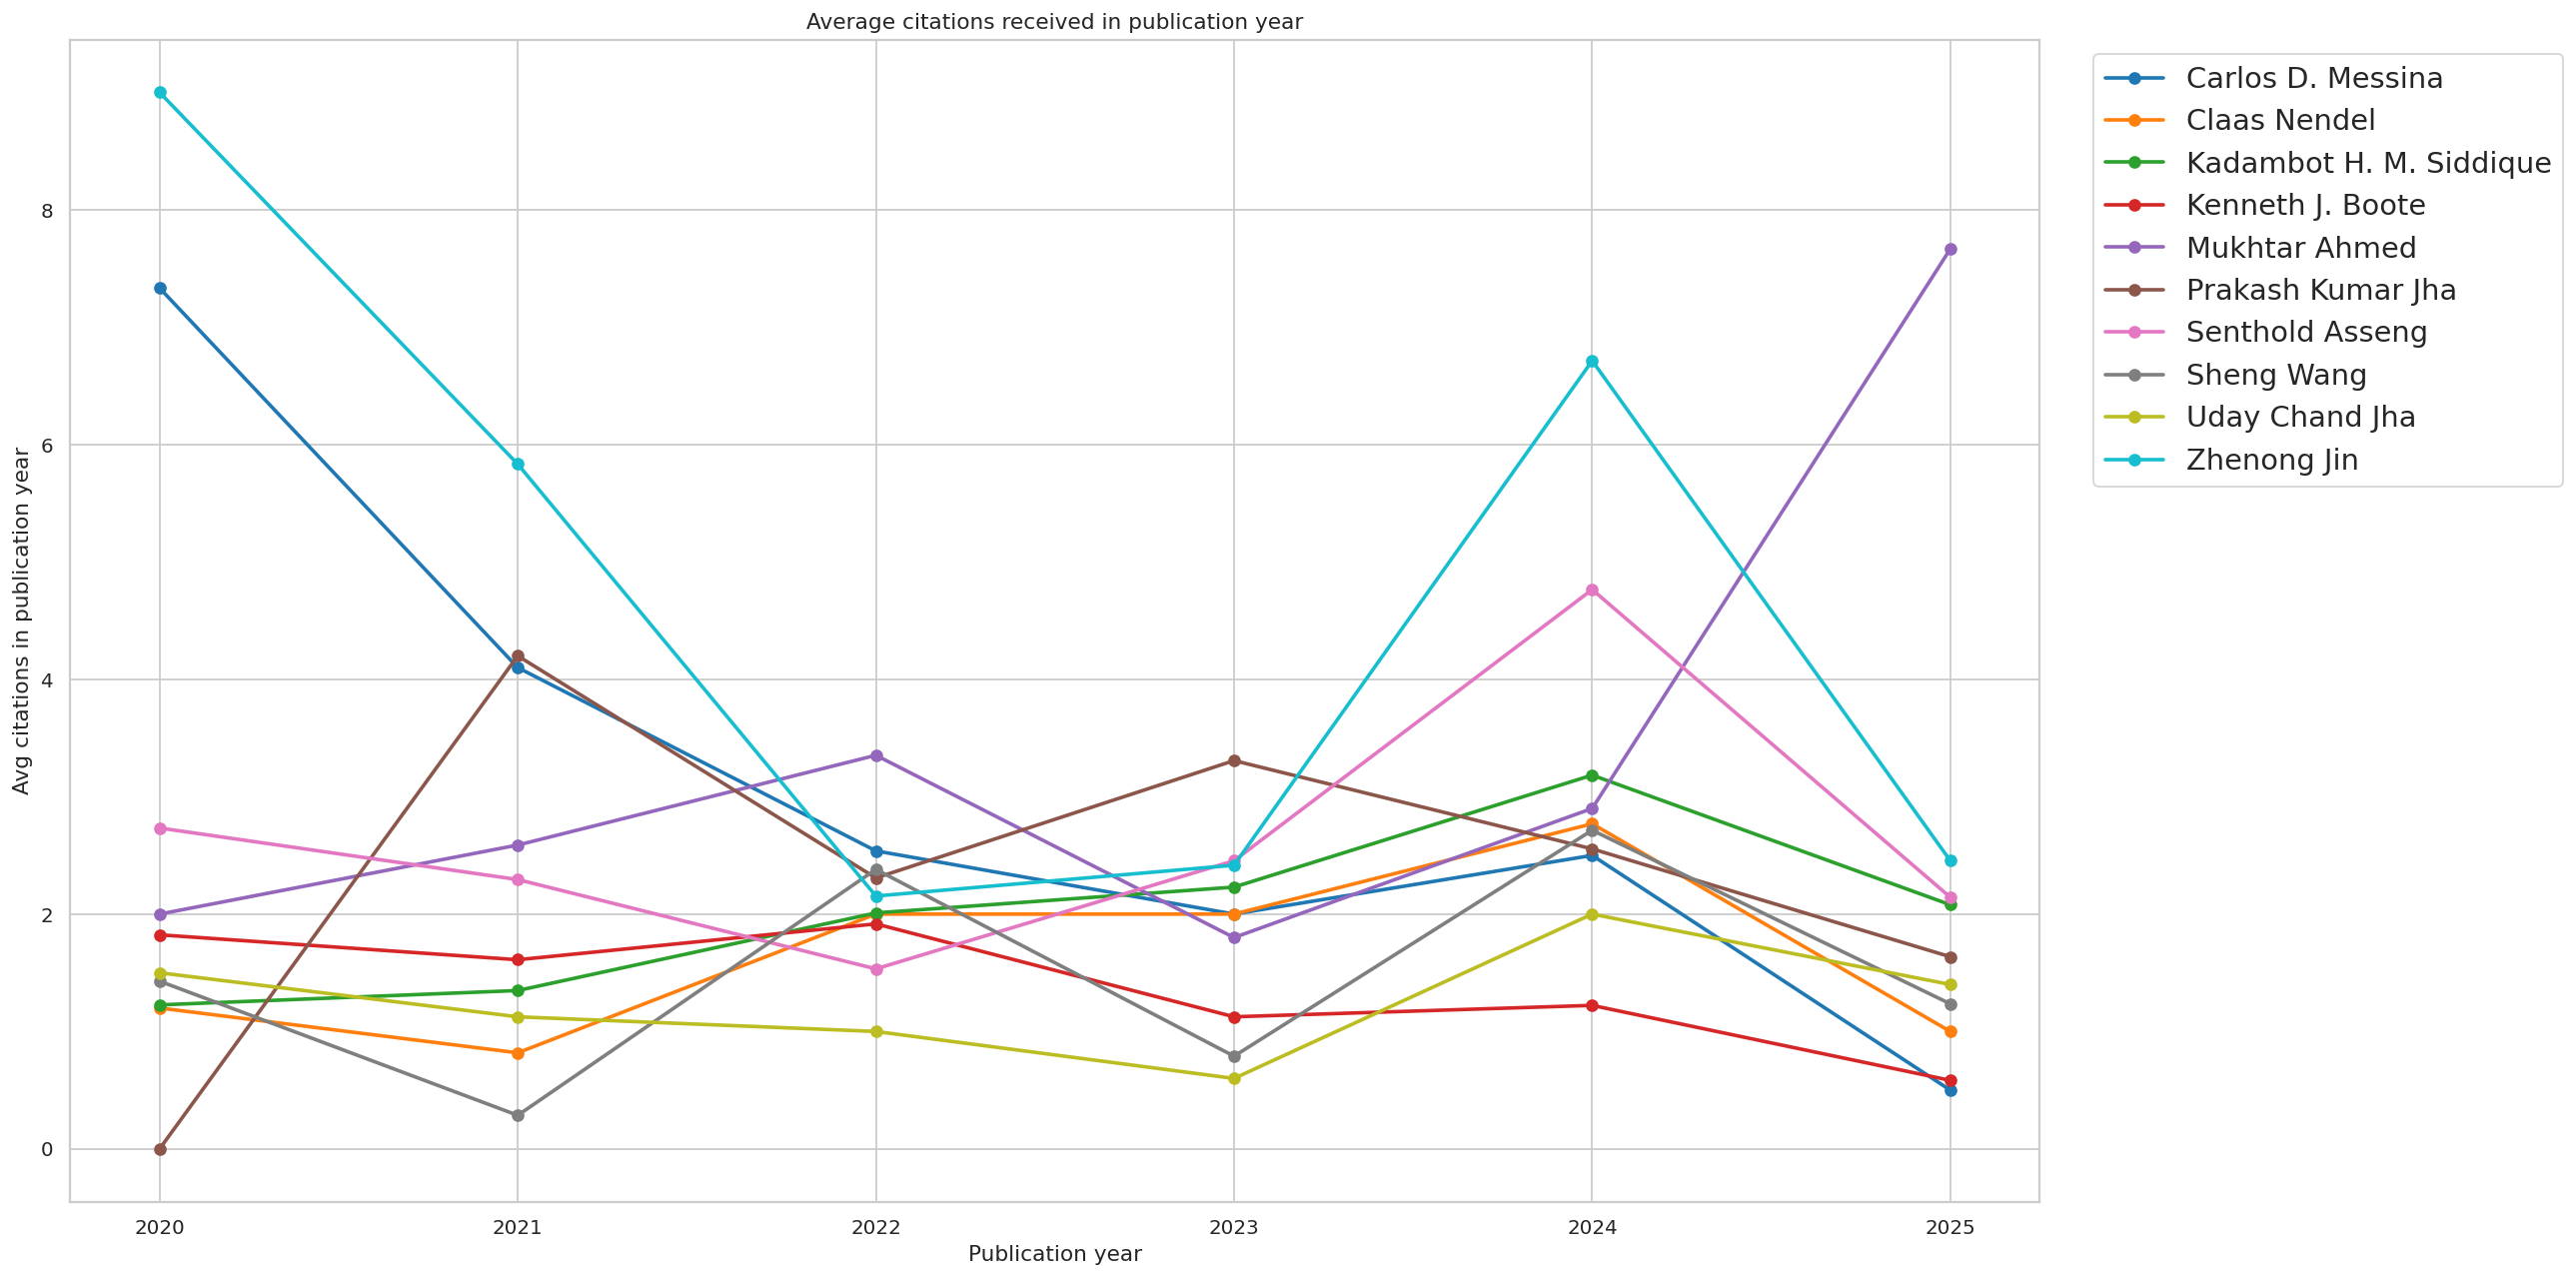

In [230]:
# ---- Same-year citations only (citations_year_0), per author ----
df_ca = filtered_coauthors_dedup.copy()

top_authors = (
    df_ca.groupby("queried_author")["article_id"]
    .count()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

same_year = (
    df_ca[df_ca["queried_author"].isin(top_authors)]
    .dropna(subset=["publication_year"])
    .assign(cit_same_year=lambda d: d.get("citations_year_0", 0).fillna(0))
)

per_year = (
    same_year.groupby(["queried_author", "publication_year"])
    .agg(
        total_cit=("cit_same_year", "sum"),
        avg_cit=("cit_same_year", "mean"),
        n_papers=("article_id", "count"),
    )
    .reset_index()
)

fig, axes = plt.subplots( figsize=(20, 10))



# Right: average citations per paper in publication year
for author, grp in per_year.groupby("queried_author"):
    grp = grp.sort_values("publication_year")
    axes.plot(grp["publication_year"], grp["avg_cit"], marker="o", linewidth=2, label=author)

axes.set_title("Average citations received in publication year")
axes.set_xlabel("Publication year")
axes.set_ylabel("Avg citations in publication year")
axes.set_xticks(sorted(per_year["publication_year"].unique()))

axes.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=16)
plt.tight_layout()
plt.show()

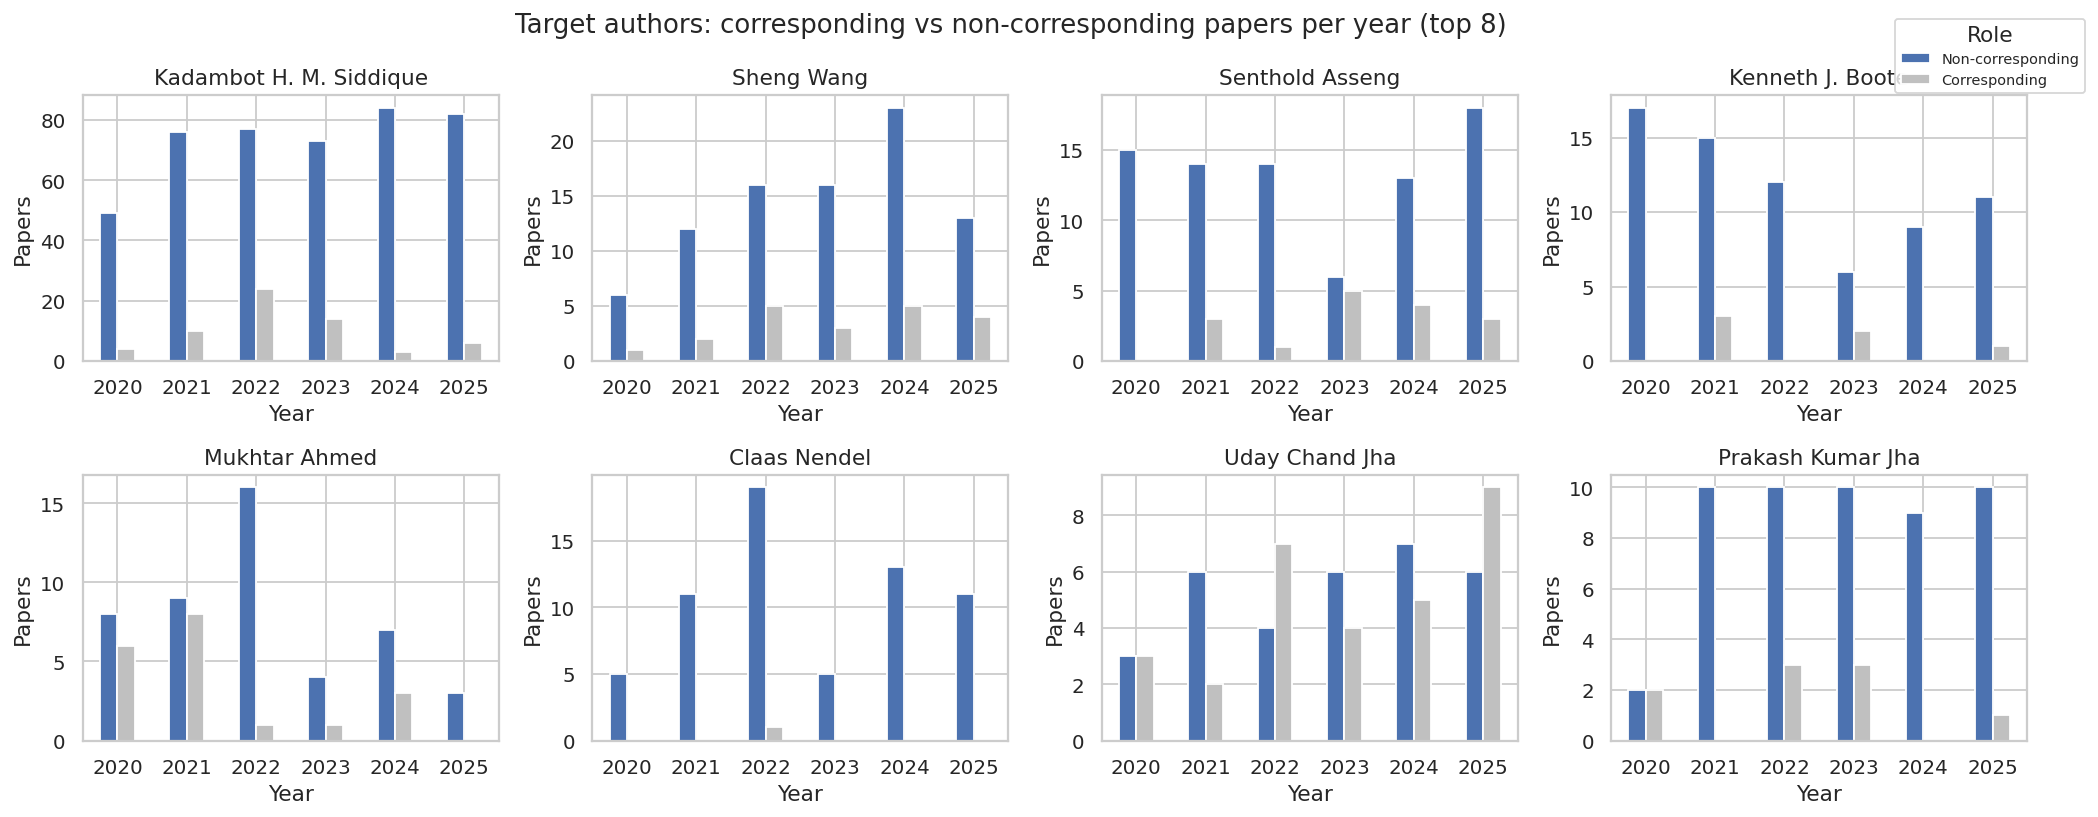

In [231]:


# ---- Corresponding vs non-corresponding papers per year by author ----
top_authors = (
    df_ca.groupby("queried_author")["article_id"]
    .count()
    .sort_values(ascending=False)
    .head(8)
    .index.tolist()
)

corr_year_author = (
    df_ca[df_ca["queried_author"].isin(top_authors)]
    .dropna(subset=["publication_year"])
    .groupby(["queried_author", "publication_year", "is_corresponding_author"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={True: "Corresponding", False: "Non-corresponding"})
)

n_authors = len(top_authors)
ncols = 4
nrows = int(np.ceil(n_authors / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows), squeeze=False)
axes_flat = axes.flatten()

for i, author in enumerate(top_authors):
    ax = axes_flat[i]
    data = corr_year_author.loc[author].sort_index()
    data.plot(kind="bar", stacked=False, ax=ax, color=["#4C72B0", "#C0C0C0"], edgecolor="white", legend=False)
    ax.set_title(author)
    ax.set_xlabel("Year")
    ax.set_ylabel("Papers")
    ax.tick_params(axis="x", rotation=0)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("Target authors: corresponding vs non-corresponding papers per year (top 8)")
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.02, 0.98), fontsize=8, title="Role")
plt.tight_layout()
plt.show()

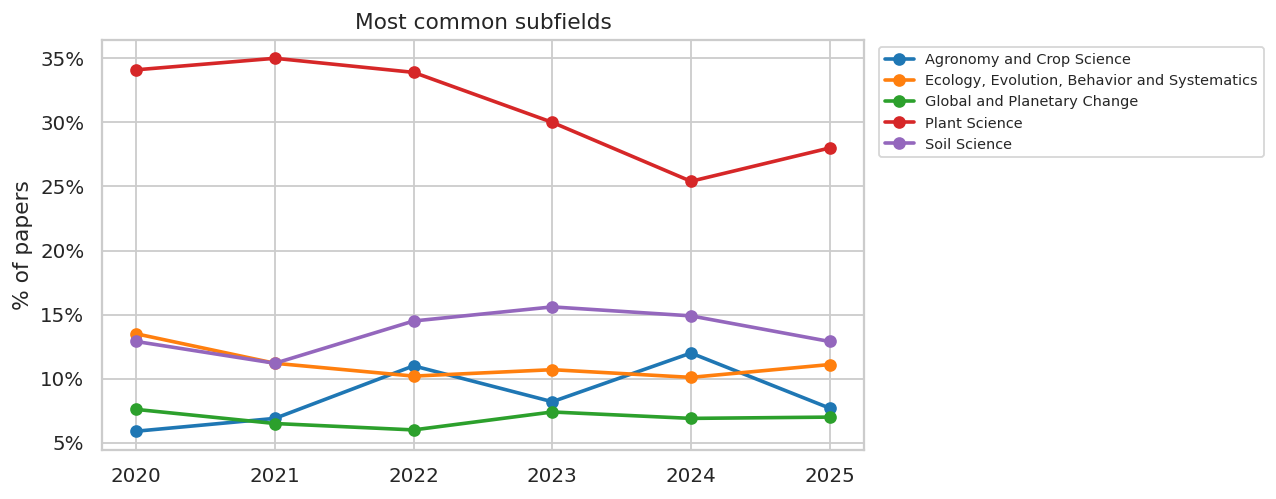

In [232]:
# ---- Topic trends over time (topic_subfield) ----
topic_col = "topic_subfield"
top_subfields = (
    df_ca.dropna(subset=[topic_col])
    .groupby(topic_col)["article_id"].count()
    .nlargest(5).index.tolist()
)

topic_year = (
    df_ca.dropna(subset=[topic_col, "publication_year"])
    .query("topic_subfield in @top_subfields")
    .groupby(["publication_year", topic_col])
    .size()
    .reset_index(name="n")
)
total_per_year = (
    df_ca.dropna(subset=["publication_year"])
    .groupby("publication_year")["article_id"].count()
    .rename("total")
)
topic_year = topic_year.merge(total_per_year.reset_index(), on="publication_year")
topic_year["pct"] = (topic_year["n"] / topic_year["total"] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 4))
for subfield, grp in topic_year.groupby(topic_col):
    grp = grp.sort_values("publication_year")
    ax.plot(grp["publication_year"], grp["pct"], marker="o", linewidth=2, label=subfield)
ax.set_title("Most common subfields")
ax.set_ylabel("% of papers")
ax.set_xticks(sorted(topic_year["publication_year"].unique()))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [275]:
# Interactive table: dominant subfield per author per year (target authors, duplicates kept)
try:
    import ipywidgets as widgets
except ImportError:
    print("ipywidgets not installed. Run: pip install ipywidgets")
    raise
from IPython.display import display, clear_output

topic_col_for_year = "topic_subfield"

df_topic_src = (
    filtered_coauthors_df
    .dropna(subset=["queried_author", "publication_year", topic_col_for_year])
    .copy()
 )
df_topic_src["publication_year"] = df_topic_src["publication_year"].astype(int)

topic_year_counts = (
    df_topic_src
    .groupby(["queried_author", "publication_year", topic_col_for_year])
    .size()
    .reset_index(name="n_papers")
 )

dominant_by_year = (
    topic_year_counts
    .sort_values(
        ["queried_author", "publication_year", "n_papers", topic_col_for_year],
        ascending=[True, True, False, True],
    )
    .groupby(["queried_author", "publication_year"])
    .head(1)
    .rename(columns={topic_col_for_year: "dominant_topic"})
    .reset_index(drop=True)
 )

authors = sorted(dominant_by_year["queried_author"].unique().tolist())
author_widget = widgets.Combobox(
    options=authors,
    placeholder="Type last name",
    description="Author:",
    ensure_option=False,
    continuous_update=True,
 )
out = widgets.Output()

def _resolve_author(input_text: str | None):
    text = (input_text or "").strip()
    if not text:
        return None, "Type an author last name to filter."
    matches = [a for a in authors if text.lower() in a.lower()]
    if len(matches) == 1:
        return matches[0], None
    exact = [a for a in matches if a.lower() == text.lower()]
    if len(exact) == 1:
        return exact[0], None
    if len(matches) == 0:
        return None, f"No author match for '{text}'."
    return None, "Multiple matches: " + ", ".join(matches)

def _render(_change=None):
    with out:
        clear_output()
        selected, msg = _resolve_author(author_widget.value)
        if msg:
            print(msg)
            return
        view = (
            dominant_by_year[dominant_by_year["queried_author"] == selected]
            .sort_values("publication_year")
            [["publication_year", "dominant_topic", "n_papers"]]
            .reset_index(drop=True)
        )
        display(view)

author_widget.observe(_render, names="value")
display(widgets.VBox([
    widgets.HTML("<b>Dominant subfield per year</b>"),
    author_widget,
    out,
 ]))
_render()

In [ ]:
# Interactive chart: citations by year-of-life per author (Target authors, deduped)
try:
    import ipywidgets as widgets
except ImportError:
    print("ipywidgets not installed. Run: pip install ipywidgets")
    raise
from IPython.display import display, clear_output

year_labels = ["Year 1", "Year 2", "Year 3", "Year 4"]
year_columns = ["citations_year_0", "citations_year_1", "citations_year_2", "citations_year_3"]
year_offsets = [1, 2, 3, 4]

df_cit_src = (
    filtered_coauthors_dedup
    .dropna(subset=["queried_author", "publication_year"])
    .copy()
 )
df_cit_src["publication_year"] = df_cit_src["publication_year"].astype(int)

cit_authors = sorted(df_cit_src["queried_author"].unique().tolist())
author_cit_widget = widgets.Combobox(
    options=cit_authors,
    placeholder="Type last name",
    description="Author:",
    ensure_option=False,
    continuous_update=True,
 )
out_cit = widgets.Output()

def _resolve_author_cit(input_text: str | None):
    text = (input_text or "").strip()
    if not text:
        return None, "Type an author last name to filter."
    matches = [a for a in cit_authors if text.lower() in a.lower()]
    if len(matches) == 1:
        return matches[0], None
    exact = [a for a in matches if a.lower() == text.lower()]
    if len(exact) == 1:
        return exact[0], None
    if len(matches) == 0:
        return None, f"No author match for '{text}'."
    return None, "Multiple matches: " + ", ".join(matches)

def _calc_author_year_life(author_name: str):
    df_author = df_cit_src[df_cit_src["queried_author"] == author_name]
    rows = []
    for label, col, offset in zip(year_labels, year_columns, year_offsets):
        eligible = df_author[df_author["publication_year"] <= CURRENT_YEAR - offset]
        n_papers = len(eligible)
        avg_cit = eligible[col].fillna(0).mean() if n_papers > 0 else np.nan
        rows.append({"year_label": label, "avg_citations": avg_cit, "n_papers": n_papers})
    return pd.DataFrame(rows)

def _render_cit(_change=None):
    with out_cit:
        clear_output()
        selected, msg = _resolve_author_cit(author_cit_widget.value)
        if msg:
            print(msg)
            return
        data = _calc_author_year_life(selected)
        if data["n_papers"].sum() == 0:
            print("No eligible papers for this author.")
            return
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(data["year_label"], data["avg_citations"], marker="o", linewidth=2, color="steelblue")
        ax.set_title(f"{selected}: average citations by paper year-of-life")
        ax.set_xlabel("Paper year-of-life")
        ax.set_ylabel("Avg citations (that year only)")
        ax.set_ylim(0, max(1, np.nanmax(data["avg_citations"]) * 1.25))
        for x, y, n in zip(data["year_label"], data["avg_citations"], data["n_papers"]):
            if np.isfinite(y):
                ax.text(x, y + 0.03, f"n={n}", ha="center", va="bottom", fontsize=8, color="dimgray")
        plt.tight_layout()
        plt.show()
        display(data.assign(avg_citations=data["avg_citations"].round(2)))

author_cit_widget.observe(_render_cit, names="value")
display(widgets.VBox([
    widgets.HTML("<b>Average citations by year-of-life</b>"),
    author_cit_widget,
    out_cit,
 ]))
_render_cit()

### Author citation lifecycle (interactive)
Run the cell below once, then pick an author to see average citations by paper year-of-life.

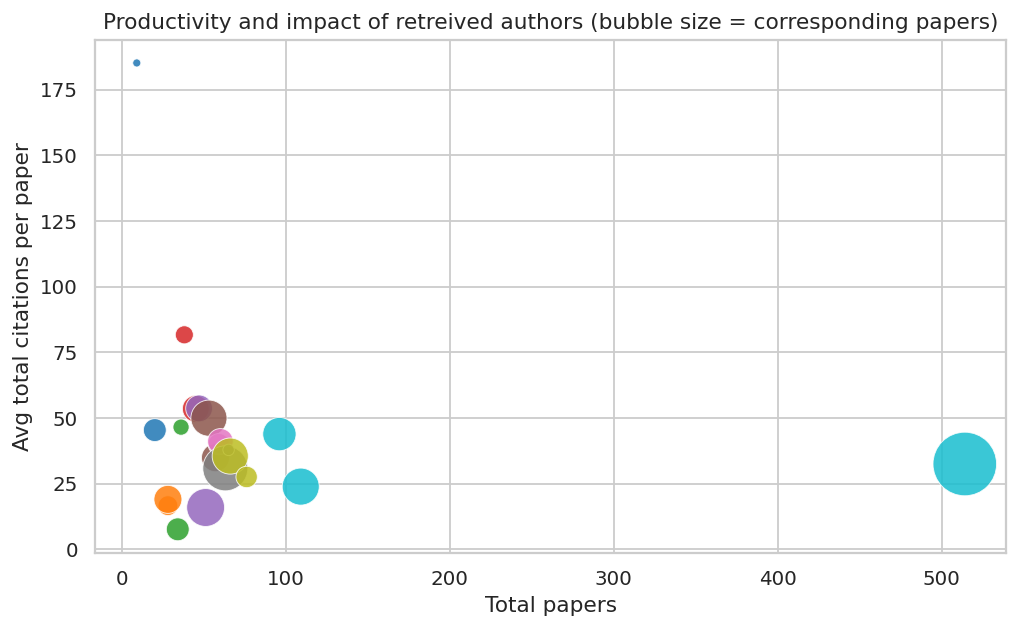

In [235]:
# ── Ranked dot plot: papers count vs avg citations per Target_author author ─────────
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    Coauthor_counts["total_papers"],
    Coauthor_counts["avg_citations"],
    s=Coauthor_counts["corresponding"]*20 + 20,  # bubble size based on corresponding-author count
    c=range(len(Coauthor_counts)),
    cmap="tab10",
    alpha=0.85,
    edgecolors="white",
    linewidths=0.5,
)
for _, row in Coauthor_counts.iterrows():
    ax.annotate(#row["queried_author"],
                None, 
                xy=(row["total_papers"], row["avg_citations"]),
                xytext=(5, 3), textcoords="offset points", fontsize=8)
ax.set_xlabel("Total papers")
ax.set_ylabel("Avg total citations per paper")
ax.set_title("Productivity and impact of retreived authors (bubble size = corresponding papers)")
plt.tight_layout()
plt.show()
#Solo contar paper donde son crresponding

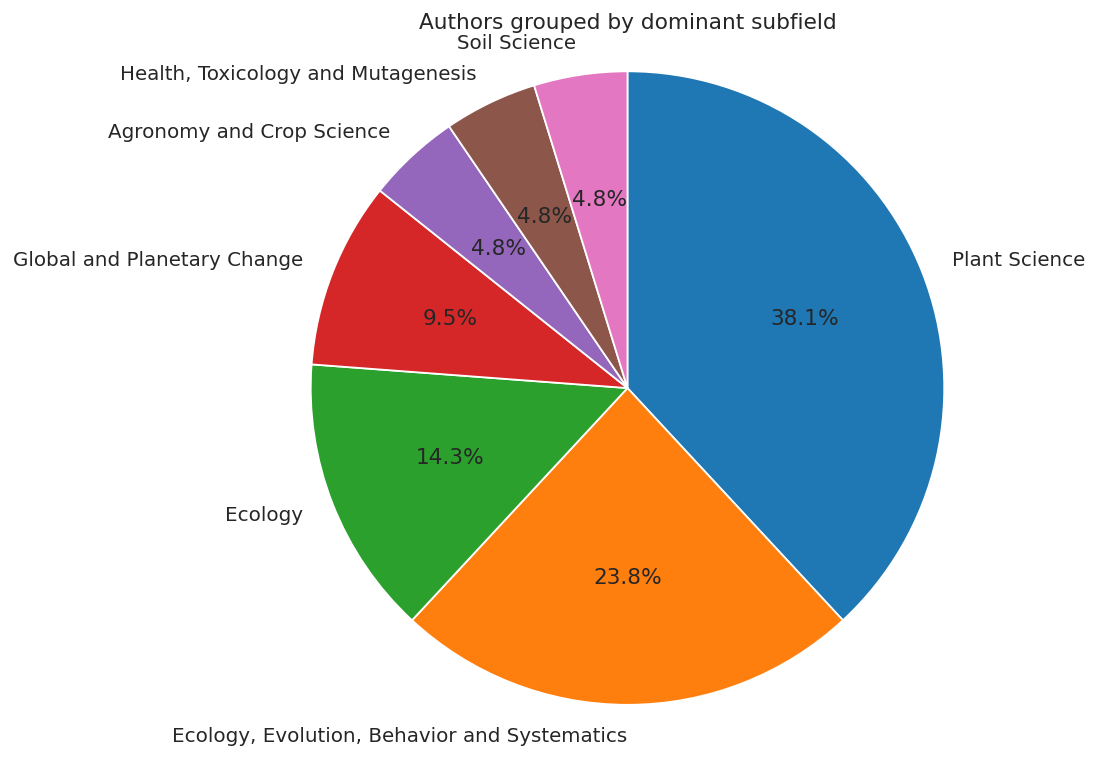

In [277]:
specific_topic_col = "topic_subfield"

dominant_CAtopic = (
    df_ca.dropna(subset=["queried_author", specific_topic_col])
    .groupby(["queried_author", specific_topic_col])
    .size()
    .reset_index(name="n")
    .sort_values(["queried_author", "n"], ascending=[True, False])
    .groupby("queried_author")
    .head(1)
    .reset_index(drop=True)
)

topic_counts = (
    dominant_CAtopic.groupby(specific_topic_col)["queried_author"]
    .nunique()
    .sort_values(ascending=False)
)
fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(
    topic_counts.values,
    labels=topic_counts.index.astype(str),
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white"},
 )
ax.set_title("Authors grouped by dominant subfield")
ax.axis("equal")
plt.tight_layout()
plt.show()

# fig, ax = plt.subplots(figsize=(10, 5))
# bars = ax.barh(topic_counts.index, topic_counts.values, color="steelblue", edgecolor="white")

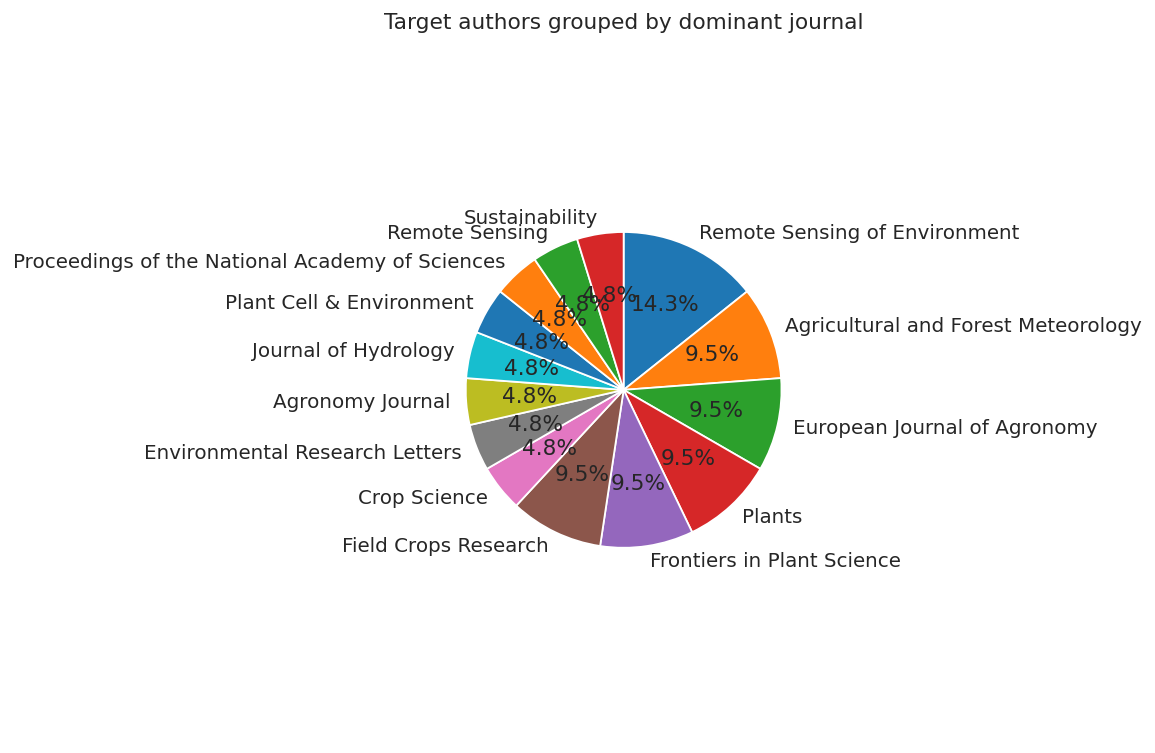

top_journal
Remote Sensing of Environment                      3
Agricultural and Forest Meteorology                2
European Journal of Agronomy                       2
Plants                                             2
Frontiers in Plant Science                         2
Field Crops Research                               2
Crop Science                                       1
Environmental Research Letters                     1
Agronomy Journal                                   1
Journal of Hydrology                               1
Plant Cell & Environment                           1
Proceedings of the National Academy of Sciences    1
Remote Sensing                                     1
Sustainability                                     1
Name: queried_author, dtype: int64


,queried_author,top_journal,n_papers
0,Adrián A. Correndo,Field Crops Research,6
1,Ana Julia Paula Carcedo,Field Crops Research,4
2,Carlos D. Messina,Crop Science,11
3,Chongya Jiang,Remote Sensing of Environment,8
4,Claas Nendel,European Journal of Agronomy,10
5,Elizabeth A. Ainsworth,Plant Cell & Environment,7
6,Ivica Djalović,Plants,6
7,Jinyun Tang,Environmental Research Letters,4
8,Kadambot H. M. Siddique,Frontiers in Plant Science,46
9,Kenneth J. Boote,Agronomy Journal,14


In [237]:
# ── Most-published journal per Target_author author ─────────────────────────────────
top_journal_per_author = (
    filtered_coauthors_dedup.dropna(subset=["journal_display_name"])
    .groupby(["queried_author", "journal_display_name"])
    .size()
    .reset_index(name="n_papers")
    .sort_values("n_papers", ascending=False)
    .groupby("queried_author")
    .first()
    .reset_index()
    .rename(columns={"journal_display_name": "top_journal"})
    [["queried_author", "top_journal", "n_papers"]]
)

journal_counts = (
    top_journal_per_author.groupby("top_journal")["queried_author"]
    .nunique()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(
    journal_counts.values,
    labels=journal_counts.index.astype(str),
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white"},
 )
ax.set_title("Target authors grouped by dominant journal")
ax.axis("equal")
plt.tight_layout()
plt.show()
# fig, ax = plt.subplots(figsize=(10, 5))
# bars = ax.barh(
#     top_journal_per_author["queried_author"],
#     top_journal_per_author["n_papers"],
#     color="steelblue", edgecolor="white"
# )
# ax.bar_label(bars, padding=3, fontsize=8)

# ax.set_xlabel("Papers in top journal")
# ax.set_title("Most-published journal per Target_author author")
# plt.tight_layout()
# plt.show()
print(journal_counts)

top_journal_per_author


In [238]:
# # ── Avg citations by Target author (duplicates included, journals of interest) ──
# avg_cit_by_author = (
#     filtered_coauthors_df.assign(total_citations=lambda d: d["total_citations"].fillna(0))
#     .groupby("queried_author")["total_citations"]
#     .mean()
#     .sort_values(ascending=True)
#     .round(2)
#  )

# fig, ax = plt.subplots(figsize=(9, 5))
# bars = ax.barh(avg_cit_by_author.index, avg_cit_by_author.values,
#                color="steelblue", edgecolor="white")
# ax.bar_label(bars, padding=3, fontsize=9)
# ax.set_xlabel("Avg citations per paper (duplicates included)")
# ax.set_title("Avg citations per Target author")
# plt.tight_layout()
# plt.show()


# Topic Analysis

topic_subfield
Pollution                                       40.0
Soil Science                                    20.0
Ecology, Evolution, Behavior and Systematics    20.0
Global and Planetary Change                     20.0
Plant Science                                    0.0
Agronomy and Crop Science                        0.0
Ecology                                          0.0
Name: count, dtype: float64
topic_subfield
Pollution                                        0.0
Soil Science                                    11.7
Ecology, Evolution, Behavior and Systematics    11.9
Global and Planetary Change                      0.0
Plant Science                                   29.7
Agronomy and Crop Science                       11.6
Ecology                                          7.7
Name: count, dtype: float64


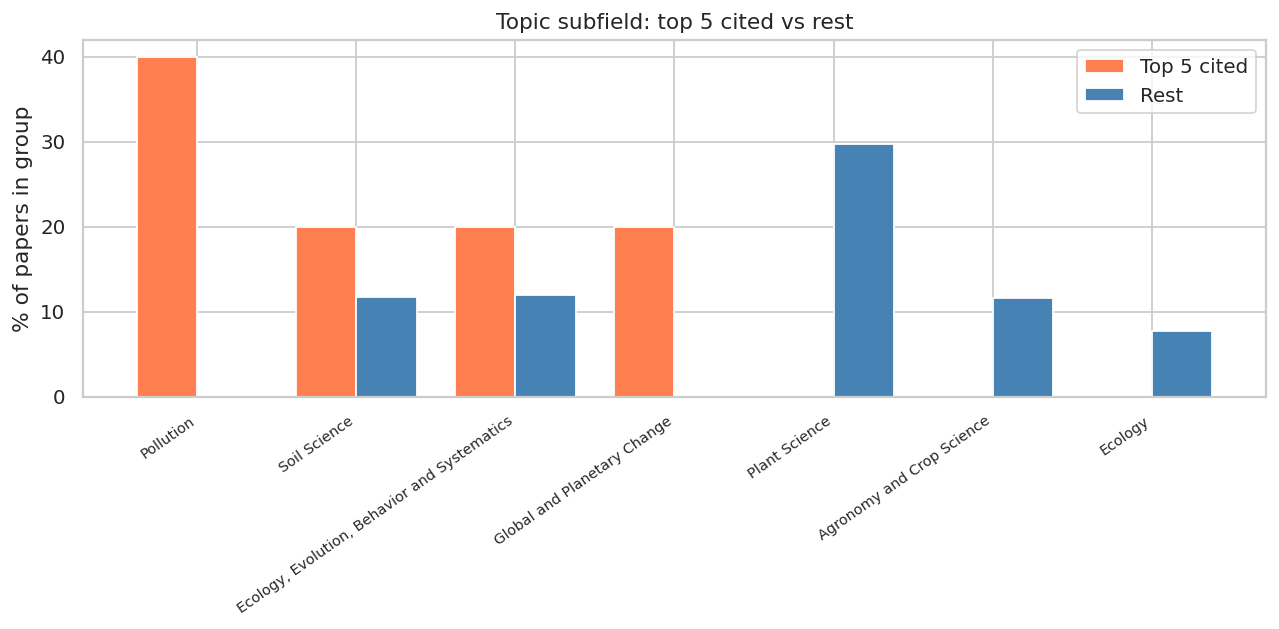

In [239]:
# ── What topics do the top-cited papers share? ───────────────────────────────
TOP_CITE_N = 5   # look at the top-5 most-cited papers

top_cited = filtered_all_df.nlargest(TOP_CITE_N, "total_citations")

subfield_top   = top_cited["topic_subfield"].value_counts().head(5)
subfield_rest  = filtered_all_df[~filtered_all_df["article_id"].isin(top_cited["article_id"])]["topic_subfield"].value_counts().head(5)

all_subfields = list(dict.fromkeys(list(subfield_top.index) + list(subfield_rest.index)))
top_pct  = (subfield_top.reindex(all_subfields, fill_value=0) / len(top_cited)  * 100).round(1)
print(top_pct)
rest_pct = (subfield_rest.reindex(all_subfields, fill_value=0) / (len(filtered_all_df) - len(top_cited)) * 100).round(1)
print(rest_pct)
x = np.arange(len(all_subfields))
w = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, top_pct.values,  w, label=f"Top {TOP_CITE_N} cited", color="coral",     edgecolor="white")
ax.bar(x + w/2, rest_pct.values, w, label="Rest",                    color="steelblue", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(all_subfields, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("% of papers in group")
ax.set_title(f"Topic subfield: top {TOP_CITE_N} cited vs rest")
ax.legend()
plt.tight_layout()
plt.show()


## Topic Analysis: Citations vs Paper Counts
This section uses `topic_subfield` to compare topic dominance by citations received (calendar year) versus paper counts (publication year).

Most cited topic per calendar year (citations received that year):


,calendar_year,topic_subfield,citations
5,2025,Plant Science,8059.0
4,2024,Plant Science,6050.0
3,2023,Plant Science,4285.0
2,2022,Plant Science,2325.0
6,2026,Plant Science,1713.0
1,2021,Plant Science,1106.0
0,2020,Plant Science,155.0


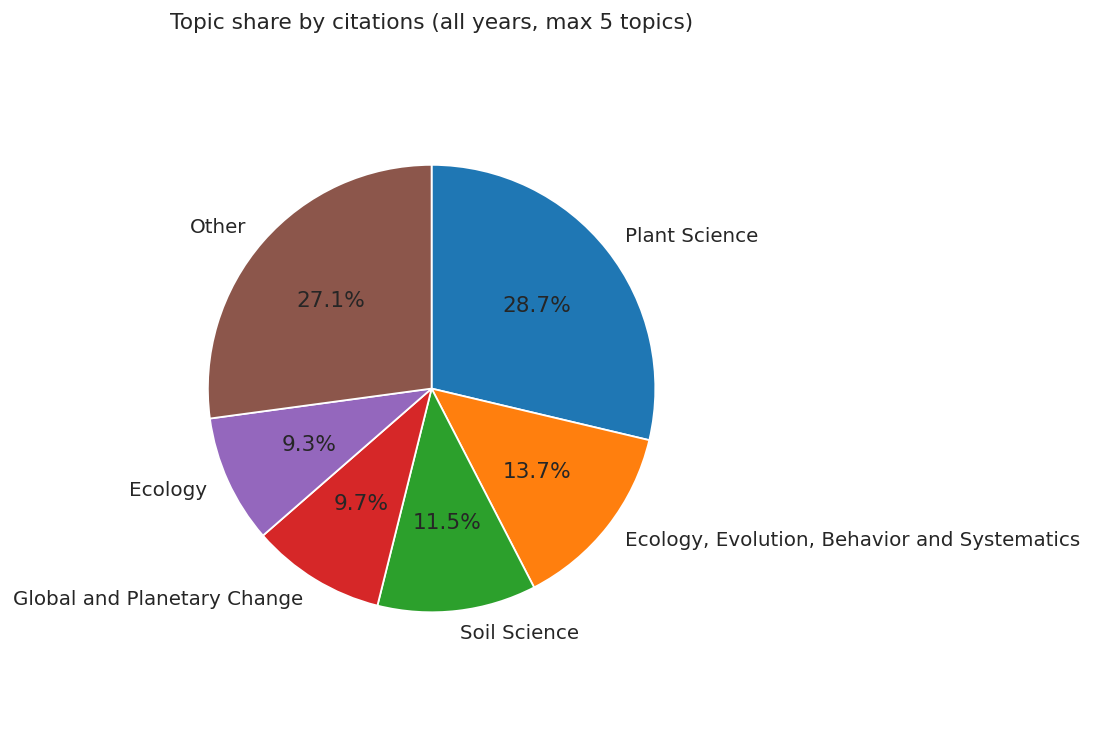

In [240]:
# ── Most cited topic per calendar year (citations received in that year) ──
topic_col = "topic_subfield"
df_topic = filtered_all_dedup.copy()
cit_year_cols = [c for c in df_topic.columns if c.startswith("citations_year_")]
current_year = CURRENT_YEAR if "CURRENT_YEAR" in globals() else 2026

if not cit_year_cols:
    print("No citations_year_* columns found. Cannot compute calendar-year citations.")
else:
    df_cit = df_topic.dropna(subset=[topic_col, "publication_year"]).copy()
    melted = (
        df_cit[["article_id", "publication_year", topic_col] + cit_year_cols]
        .melt(
            id_vars=["article_id", "publication_year", topic_col],
            value_vars=cit_year_cols,
            var_name="cit_col",
            value_name="citations",
        )
    )
    melted["offset"] = melted["cit_col"].str.extract(r"(\d+)$").astype(int)
    melted["calendar_year"] = melted["publication_year"].astype(int) + melted["offset"]
    melted["citations"] = melted["citations"].fillna(0)
    melted = melted[melted["calendar_year"] <= current_year]

    citations_by_year_topic = (
        melted.groupby(["calendar_year", topic_col])["citations"]
        .sum()
        .reset_index()
    )

    top_topic_by_year = (
        citations_by_year_topic
        .sort_values(["calendar_year", "citations", topic_col], ascending=[True, False, True])
        .groupby("calendar_year")
        .head(1)
        .reset_index(drop=True)
    )

    print("Most cited topic per calendar year (citations received that year):")
    display(top_topic_by_year.sort_values('citations', ascending=False))

    # fig, ax = plt.subplots(figsize=(11, 4))
    # ax.bar(
    #     top_topic_by_year["calendar_year"],
    #     top_topic_by_year["citations"],
    #     color="steelblue", edgecolor="white",
    # )
    # for x, y, t in zip(
    #     top_topic_by_year["calendar_year"],
    #     top_topic_by_year["citations"],
    #     top_topic_by_year[topic_col],
    # ):
    #     ax.text(
    #         x, y + max(1, y * 0.02), str(t),
    #         ha="center", va="bottom", fontsize=8, rotation=90, color="dimgray",
    #     )
    # ax.set_title("Most cited topic per calendar year\n(citations received that year)")
    # ax.set_xlabel("Calendar year")
    # ax.set_ylabel("Citations received in that year")
    # ax.set_xticks(sorted(top_topic_by_year["calendar_year"].unique()))
    # plt.tight_layout()
    # plt.show()

    # ── Overall topic share by citations (max 5 topics) ───────────────────────
    total_citations_by_topic = (
        citations_by_year_topic.groupby(topic_col)["citations"]
        .sum()
        .sort_values(ascending=False)
    )
    top_n = 5
    top_topics = total_citations_by_topic.head(top_n)
    other_sum = total_citations_by_topic.iloc[top_n:].sum()
    pie_values = top_topics.copy()
    if other_sum > 0:
        pie_values.loc["Other"] = other_sum

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.pie(
        pie_values.values,
        labels=pie_values.index.astype(str),
        autopct="%1.1f%%",
        startangle=90,
        counterclock=False,
        wedgeprops={"edgecolor": "white"},
    )
    ax.set_title("Topic share by citations (all years, max 5 topics)")
    ax.axis("equal")
    plt.tight_layout()
    plt.show()

Most common subfield per publication year (paper counts):


,publication_year,topic_subfield,n_papers
1,2021,Plant Science,136
2,2022,Plant Science,134
5,2025,Plant Science,133
4,2024,Plant Science,127
0,2020,Plant Science,108
3,2023,Plant Science,106


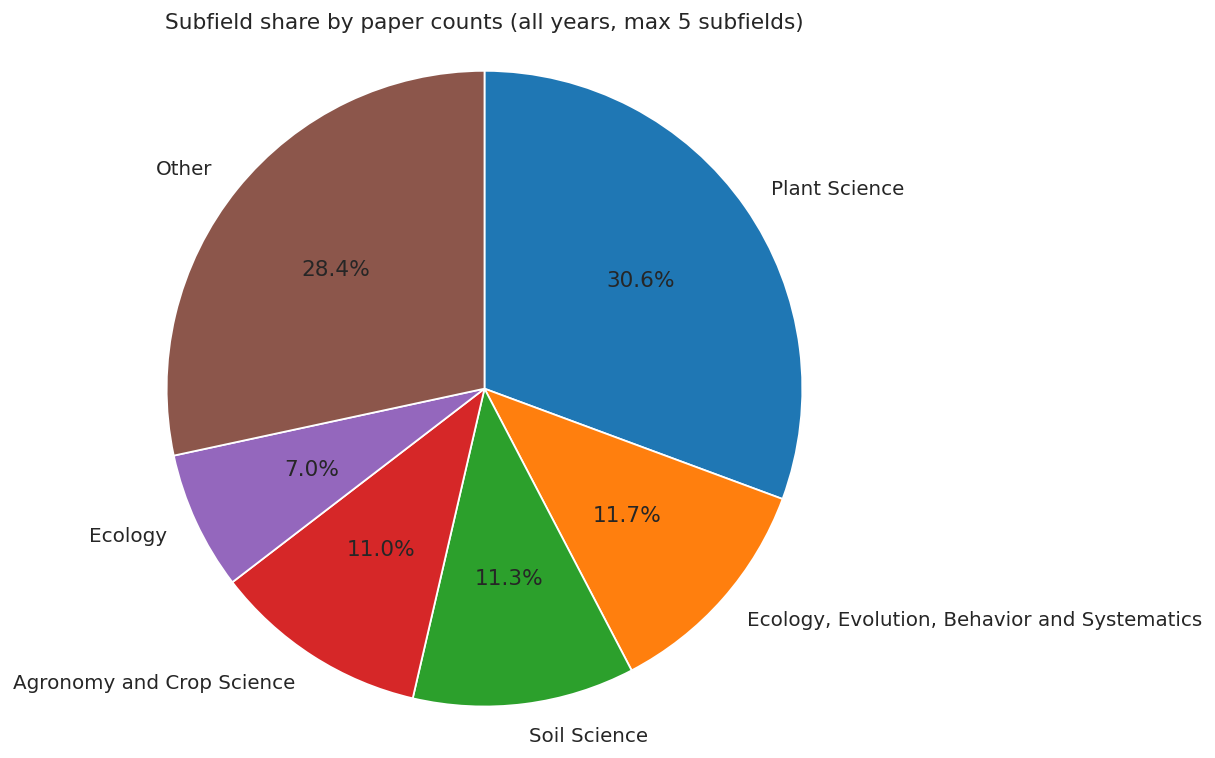

In [241]:
# ── Same view using paper counts (publication year) ─────────────────────────
df_counts = df_topic.dropna(subset=[topic_col, "publication_year"]).copy()
counts_by_year_topic = (
    df_counts.groupby(["publication_year", topic_col])
    .size()
    .reset_index(name="n_papers")
 )

top_topic_by_year_counts = (
    counts_by_year_topic
    .sort_values(["publication_year", "n_papers", topic_col], ascending=[True, False, True])
    .groupby("publication_year")
    .head(1)
    .reset_index(drop=True)
 )

print("Most common subfield per publication year (paper counts):")
display(top_topic_by_year_counts.sort_values('n_papers', ascending=False))

# fig, ax = plt.subplots(figsize=(11, 4))
# ax.bar(
#     top_topic_by_year_counts["publication_year"],
#     top_topic_by_year_counts["n_papers"],
#     color="coral", edgecolor="white",
#  )
# for x, y, t in zip(
#     top_topic_by_year_counts["publication_year"],
#     top_topic_by_year_counts["n_papers"],
#     top_topic_by_year_counts[topic_col],
#  ):
#     ax.text(
#         x, y + max(1, y * 0.02), str(t),
#         ha="center", va="bottom", fontsize=8, rotation=90, color="dimgray",
#     )
# ax.set_title("Most common subfield per publication year\n(paper counts)")
# ax.set_xlabel("Publication year")
# ax.set_ylabel("Papers published")
# ax.set_xticks(sorted(top_topic_by_year_counts["publication_year"].unique()))
# plt.tight_layout()
# plt.show()

# ── Overall topic share by paper counts (max 5 topics) ─────────────────────
total_counts_by_topic = (
    counts_by_year_topic.groupby(topic_col)["n_papers"]
    .sum()
    .sort_values(ascending=False)
 )
top_n = 5
top_topics = total_counts_by_topic.head(top_n)
other_sum = total_counts_by_topic.iloc[top_n:].sum()
pie_values = top_topics.copy()
if other_sum > 0:
    pie_values.loc["Other"] = other_sum

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(
    pie_values.values,
    labels=pie_values.index.astype(str),
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white"},
 )
ax.set_title("Subfield share by paper counts (all years, max 5 subfields)")
ax.axis("equal")
plt.tight_layout()
plt.show()

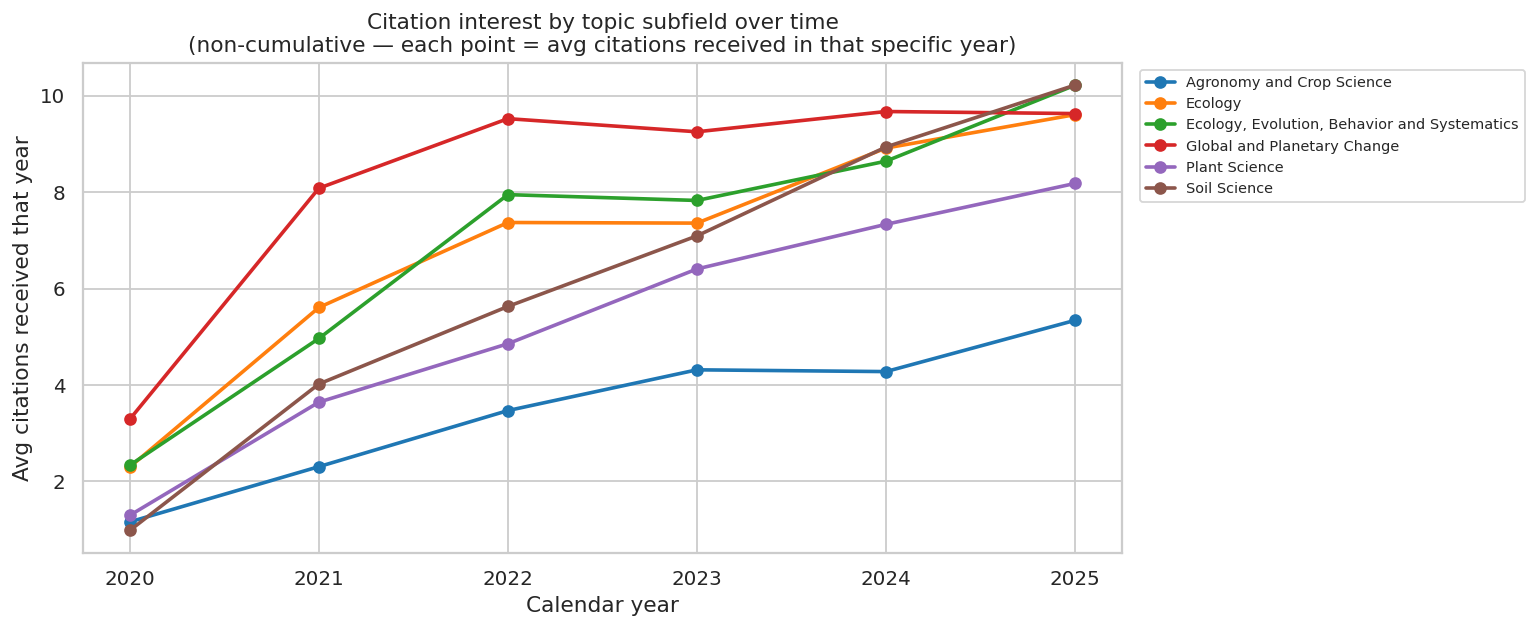

In [242]:
# ── Citation interest trend by topic subfield ─────────────────────────────────
# For each paper, citations_year_k = citations received in (publication_year + k).
# We convert offsets to actual calendar years, so every paper contributes its
# citations to the year they were received — not cumulative, purely that year.
# This lets us see whether a subfield's interest is rising or declining over time.

CURRENT_YEAR = 2026
cit_year_cols = [c for c in all_df_dedup.columns if c.startswith("citations_year_")]

top_subfields = (
    all_df_dedup.dropna(subset=["topic_subfield"])
    .groupby("topic_subfield")["article_id"].count()
    .nlargest(6).index.tolist()
)

df_top = (
    all_df_dedup
    .dropna(subset=["topic_subfield", "publication_year"])
    .query("topic_subfield in @top_subfields")
)

# Melt citation-year columns into long form, then map offset → calendar year
melted = (
    df_top[["article_id", "topic_subfield", "publication_year"] + cit_year_cols]
    .melt(id_vars=["article_id", "topic_subfield", "publication_year"],
          value_vars=cit_year_cols,
          var_name="cit_col", value_name="citations")
)
melted["offset"]        = melted["cit_col"].str.extract(r"(\d+)$").astype(int)
melted["calendar_year"] = melted["publication_year"].astype(int) + melted["offset"]
melted["citations"]     = melted["citations"].fillna(0)

# Keep only complete past calendar years (2020–2025)
melted = melted[(melted["calendar_year"] >= 2020) & (melted["calendar_year"] <= CURRENT_YEAR - 1)]

# Average citations received that calendar year, per subfield
subfield_year_avg = (
    melted.groupby(["topic_subfield", "calendar_year"])["citations"]
    .mean()
    .reset_index()
)

# ── Line chart: one line per subfield, X = calendar year ────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
for subfield, grp in subfield_year_avg.groupby("topic_subfield"):
    grp = grp.sort_values("calendar_year")
    ax.plot(grp["calendar_year"], grp["citations"], marker="o", linewidth=2, label=subfield)

ax.set_xlabel("Calendar year")
ax.set_ylabel("Avg citations received that year")
ax.set_title("Citation interest by topic subfield over time\n(non-cumulative — each point = avg citations received in that specific year)")
ax.set_xticks(range(2020, CURRENT_YEAR))
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


In [243]:

# # ── Cumulative citations by year of a paper's life ─────────────────────────────
# # Each point shows the TOTAL citations accumulated from publication up to that year.
# # e.g. Year 3 point = avg(citations_year_0 + citations_year_1 + citations_year_2)
# # Eligibility: only papers old enough to have completed that year are included.

# avg_cum_per_year = []
# n_papers_cum     = []

# for i, (label, col, offset) in enumerate(zip(year_labels, year_columns, [1, 2, 3, 4])):
#     eligible = filtered_all_dedup[filtered_all_dedup["publication_year"] <= CURRENT_YEAR - offset]
#     cum_cols = year_columns[:i + 1]
#     avg = eligible[cum_cols].fillna(0).sum(axis=1).mean()
#     avg_cum_per_year.append(avg)
#     n_papers_cum.append(len(eligible))
#     print(f"{label} (cumulative, up to {col}): {len(eligible):>4} papers eligible  →  avg {avg:.2f} citations")

# # ── Plot ───────────────────────────────────────────────────────────────────────
# fig, ax = plt.subplots(figsize=(8, 5))
# x = np.arange(len(year_labels))
# ax.plot(x, avg_cum_per_year, color="steelblue", marker="o", linewidth=2)
# ax.fill_between(x, avg_cum_per_year, color="steelblue", alpha=0.15)

# for xi, avg, n in zip(x, avg_cum_per_year, n_papers_cum):
#     ax.text(xi, avg + 0.05, f"{avg:.1f}\n(n={n})", ha="center", va="bottom", fontsize=9)

# ax.set_xticks(x)
# ax.set_xticklabels(year_labels)
# ax.set_ylabel("Avg cumulative citations")
# ax.set_title("Citation growth across a paper's life\n(each point = total citations accumulated by that year)")
# ax.set_ylim(0, max(avg_cum_per_year) * 1.25)
# plt.tight_layout()
# plt.show()

#

---

# Journal Analysis
Where are these agronomists publishing? Which journals have the highest citation impact for this community?

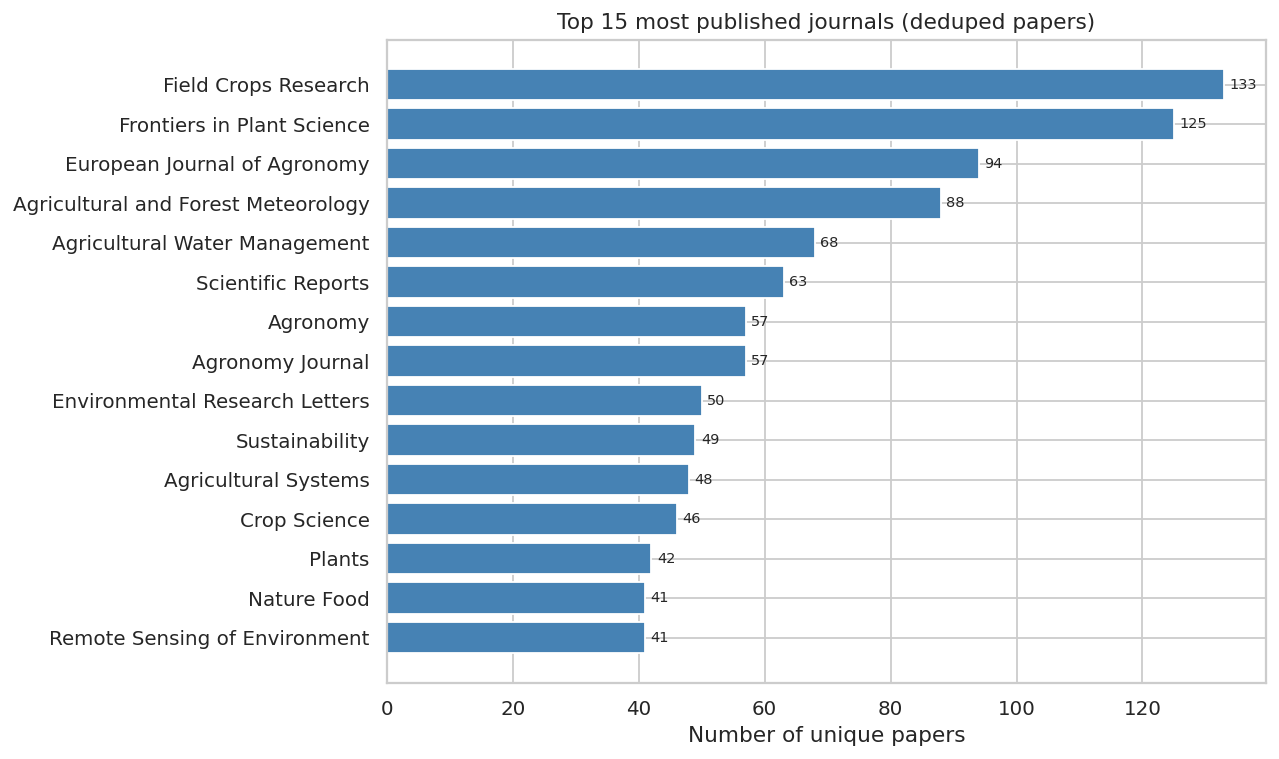

               journal_display_name  total_publications  avg_citations
               Field Crops Research                 133      19.729323
         Frontiers in Plant Science                 125      39.672000
       European Journal of Agronomy                  94      28.925532
Agricultural and Forest Meteorology                  88      30.488636
      Agricultural Water Management                  68      22.073529
                 Scientific Reports                  63      22.492063
                   Agronomy Journal                  57      11.157895
                           Agronomy                  57      18.350877
     Environmental Research Letters                  50      32.980000
                     Sustainability                  49      63.040816
               Agricultural Systems                  48      21.833333
                       Crop Science                  46      18.565217
                             Plants                  42      30.571429
      

In [244]:
# ── Top 15 journals by publication count (deduped) ────────────────────────────
journal_counts = (
    filtered_all_dedup
    .dropna(subset=["journal_display_name"])
    .groupby("journal_display_name")
    .agg(
        total_publications=("article_id", "count"),
        avg_citations=("total_citations", "mean"),
    )
    .sort_values("total_publications", ascending=False)
    .head(15)
    .sort_values("total_publications", ascending=True)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(journal_counts["journal_display_name"],
               journal_counts["total_publications"],
               color="steelblue", edgecolor="white")
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_xlabel("Number of unique papers")
ax.set_title("Top 15 most published journals (deduped papers)")
plt.tight_layout()
plt.show()
print(journal_counts.sort_values("total_publications", ascending=False).to_string(index=False))

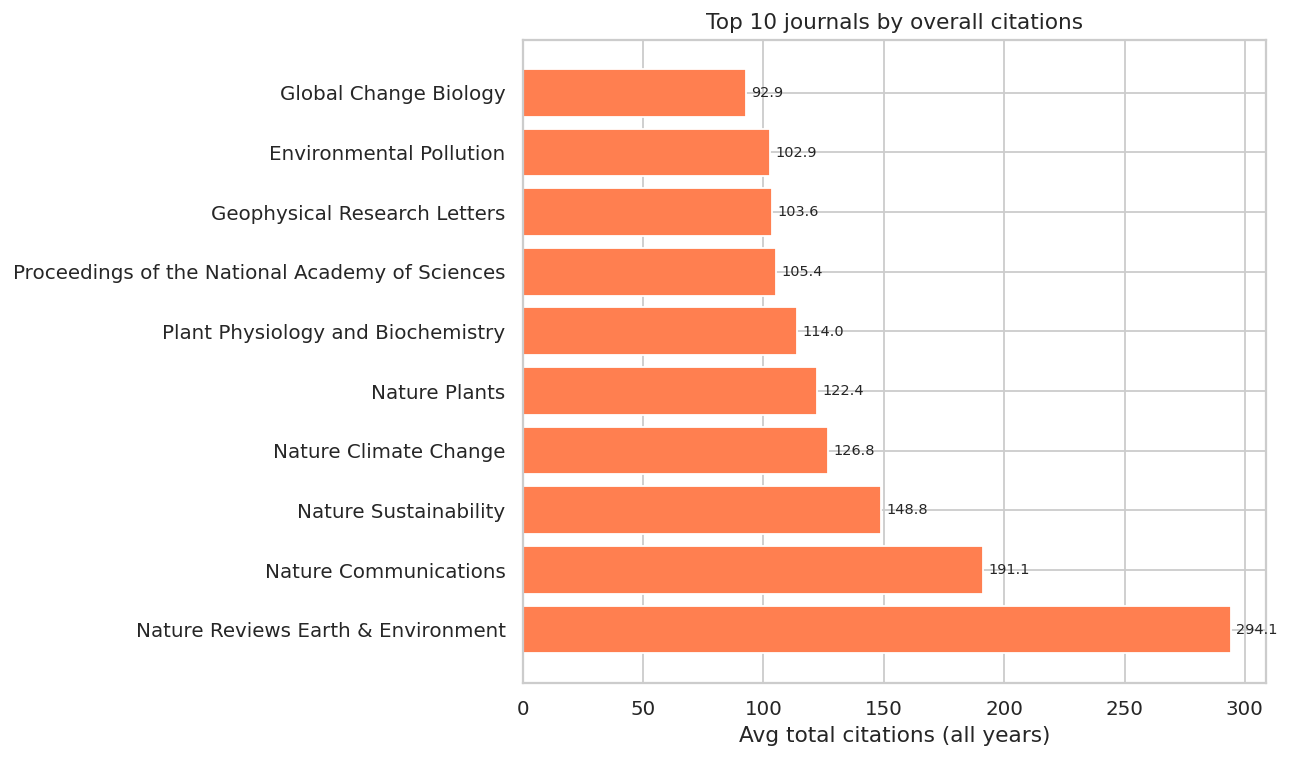

In [245]:
# ── Journal avg total citations (papers old enough) ─────────────────────────
CURRENT_YEAR = 2026
df_jnl = filtered_all_dedup.copy()
df_jnl["age"] = CURRENT_YEAR - df_jnl["publication_year"].fillna(CURRENT_YEAR)

# Filter to papers with at least 2 years since publication
eligible = df_jnl[df_jnl["age"] >= 2].dropna(subset=["journal_display_name", "total_citations"])
jnl_avg = (
    eligible.groupby("journal_display_name")
    .agg(
        n=("article_id", "count"),
        avg_cit_all_years=("total_citations", "mean"),
        total_pubs_in_dataset=("article_id", "count"),
    )
    .query("n >= 5")
    .sort_values("avg_cit_all_years", ascending=False)
    .head(10)
    .reset_index()
 )

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    jnl_avg["journal_display_name"].str[:55],
    jnl_avg["avg_cit_all_years"],
    color="coral", edgecolor="white",
 )
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)
ax.set_xlabel("Avg total citations (all years)")
ax.set_title("Top 10 journals by overall citations")
plt.tight_layout()
plt.show()

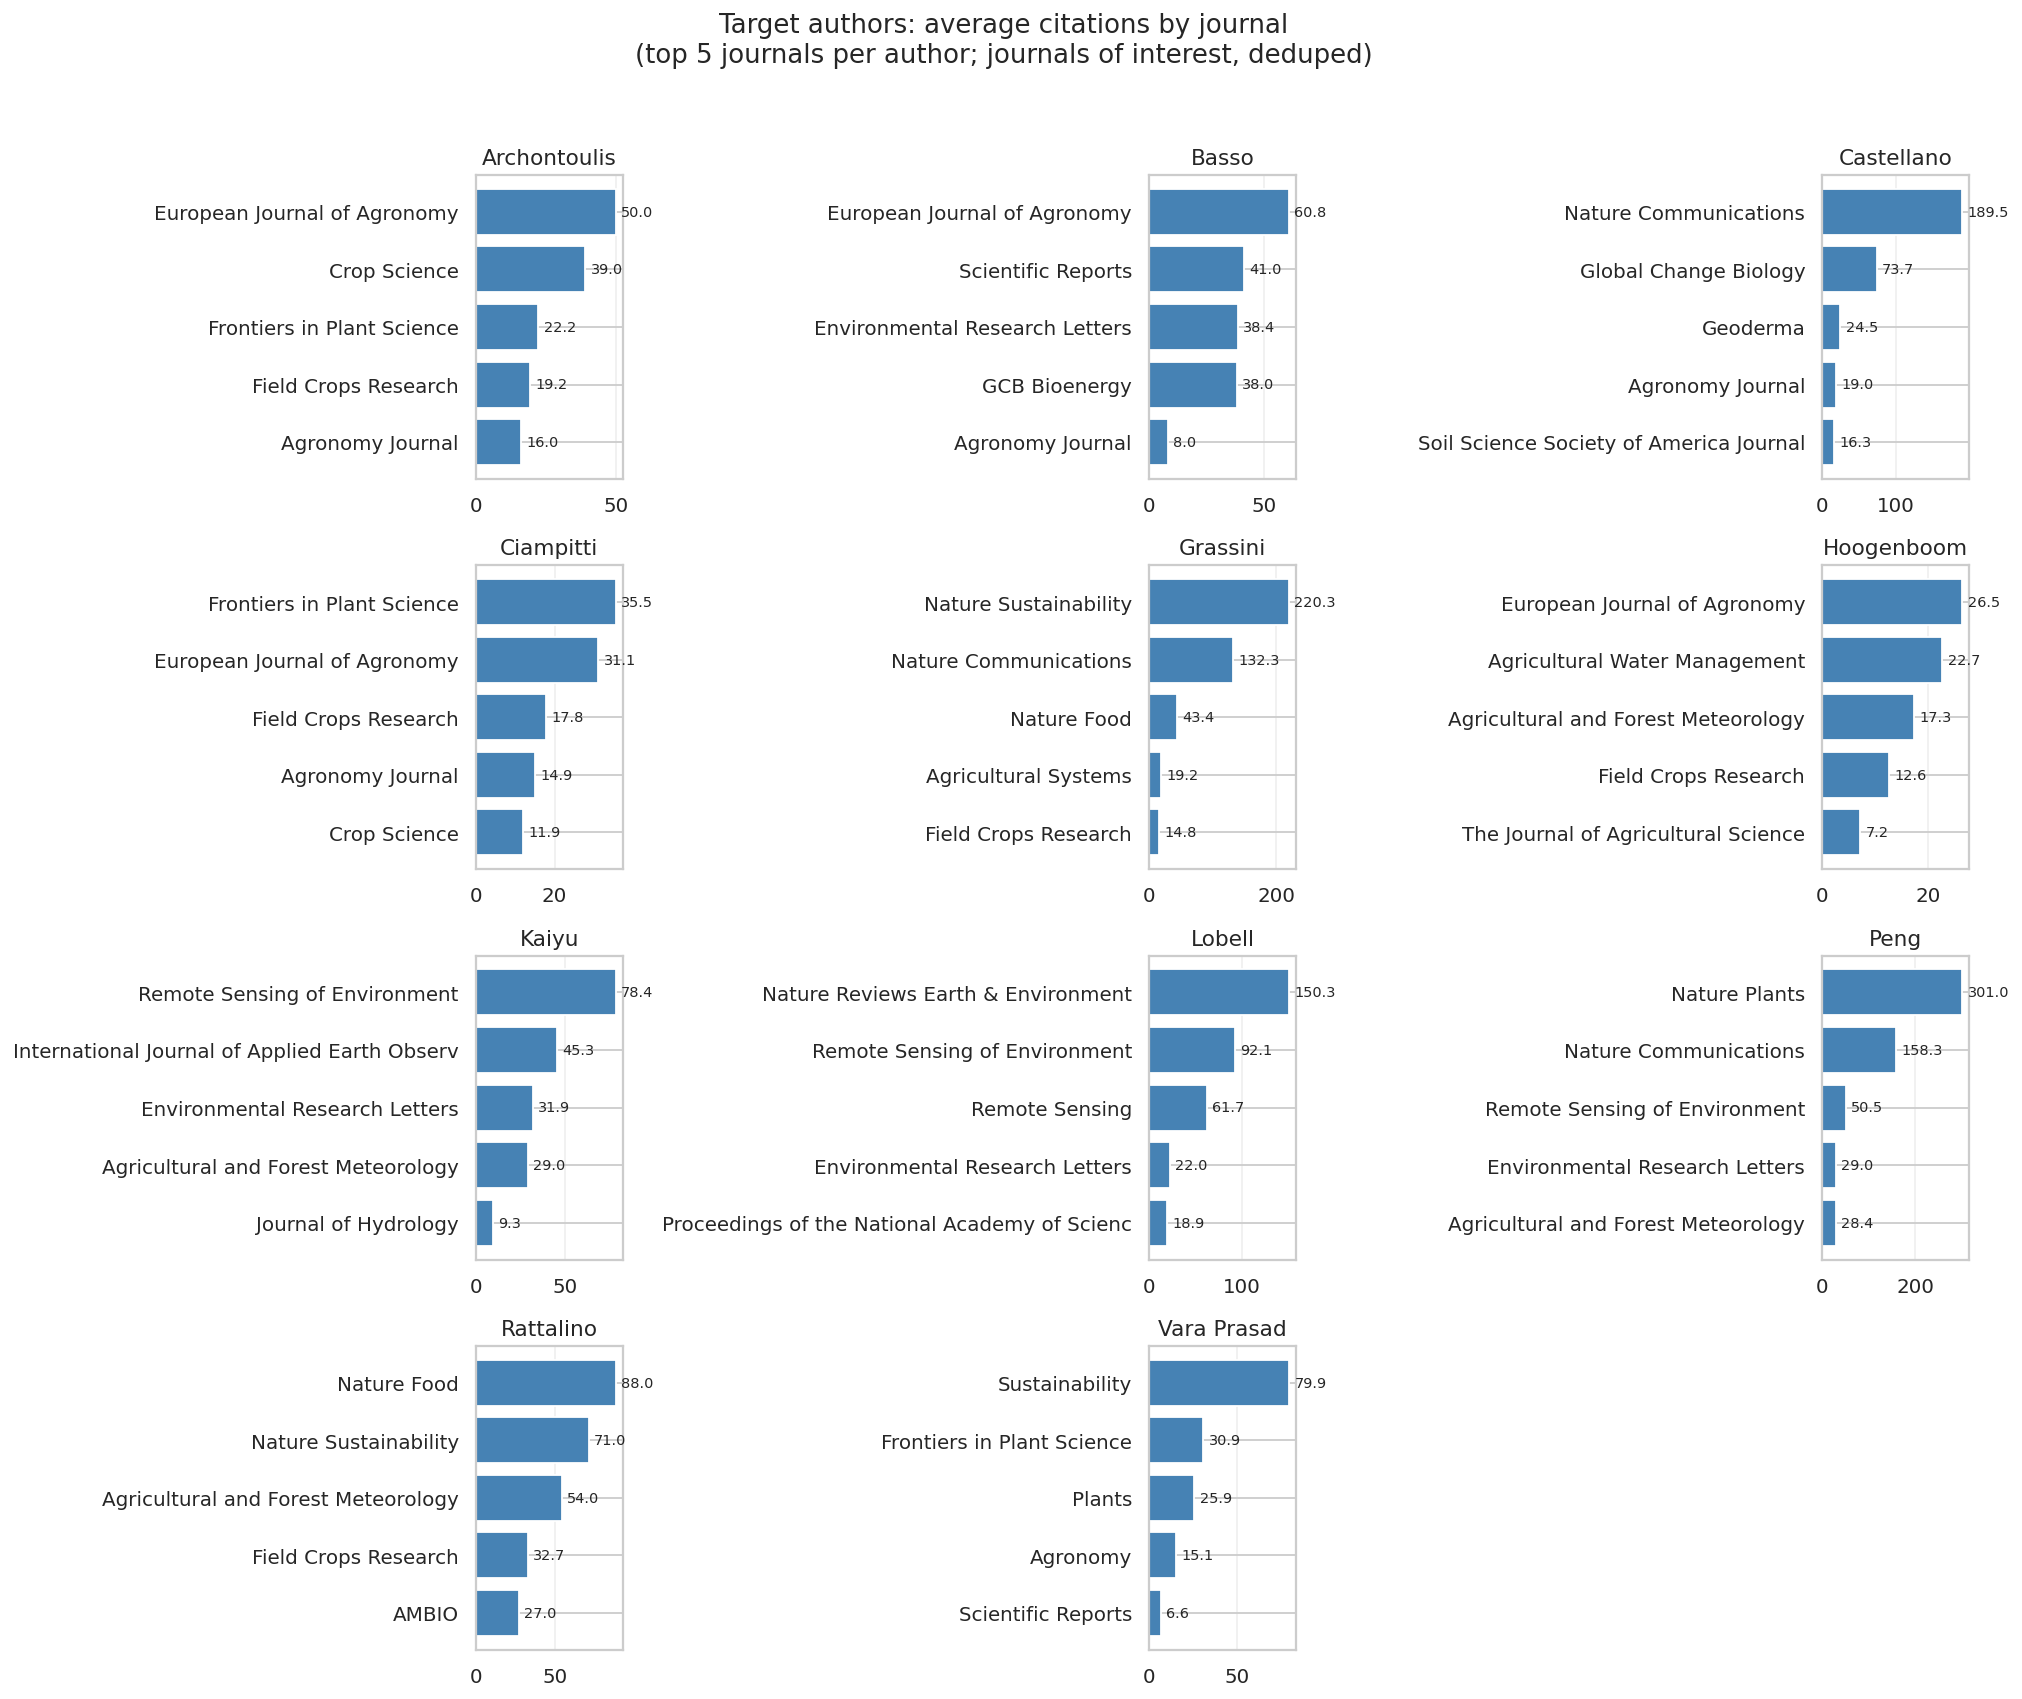

In [246]:
# ── Target authors: avg citations by journal (top 5 per author) ─────────────────
TOP_JOURNALS_PER_AUTHOR = 5

df_aj = (
    filtered_TargetA_dedup
    .dropna(subset=["journal_display_name", "total_citations", "queried_author"])
    .groupby(["queried_author", "journal_display_name"])
    .agg(
        n_papers=("article_id", "count"),
        avg_citations=("total_citations", "mean"),
        median_citations=("total_citations", "median"),
    )
    .reset_index()
)

# Keep top journals per author by paper count
Top_journals = (
    df_aj.sort_values(["queried_author", "n_papers", "avg_citations"], ascending=[True, False, False])
    .groupby("queried_author")
    .head(TOP_JOURNALS_PER_AUTHOR)
)

authors = Top_journals["queried_author"].unique().tolist()
n_authors = len(authors)

ncols = 3
nrows = int(np.ceil(n_authors / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.2 * nrows), squeeze=False)
axes_flat = axes.flatten()

for i, author in enumerate(authors):
    ax = axes_flat[i]
    data = (
        Top_journals[Top_journals["queried_author"] == author]
        .sort_values("avg_citations", ascending=True)
    )
    bars = ax.barh(
        data["journal_display_name"].str[:45],
        data["avg_citations"],
        color="steelblue",
        edgecolor="white",
    )
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)
    ax.set_title(author)
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.3)

# Hide unused axes
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("Target authors: average citations by journal\n(top 5 journals per author; journals of interest, deduped)", y=1.02)
plt.tight_layout()
plt.show()



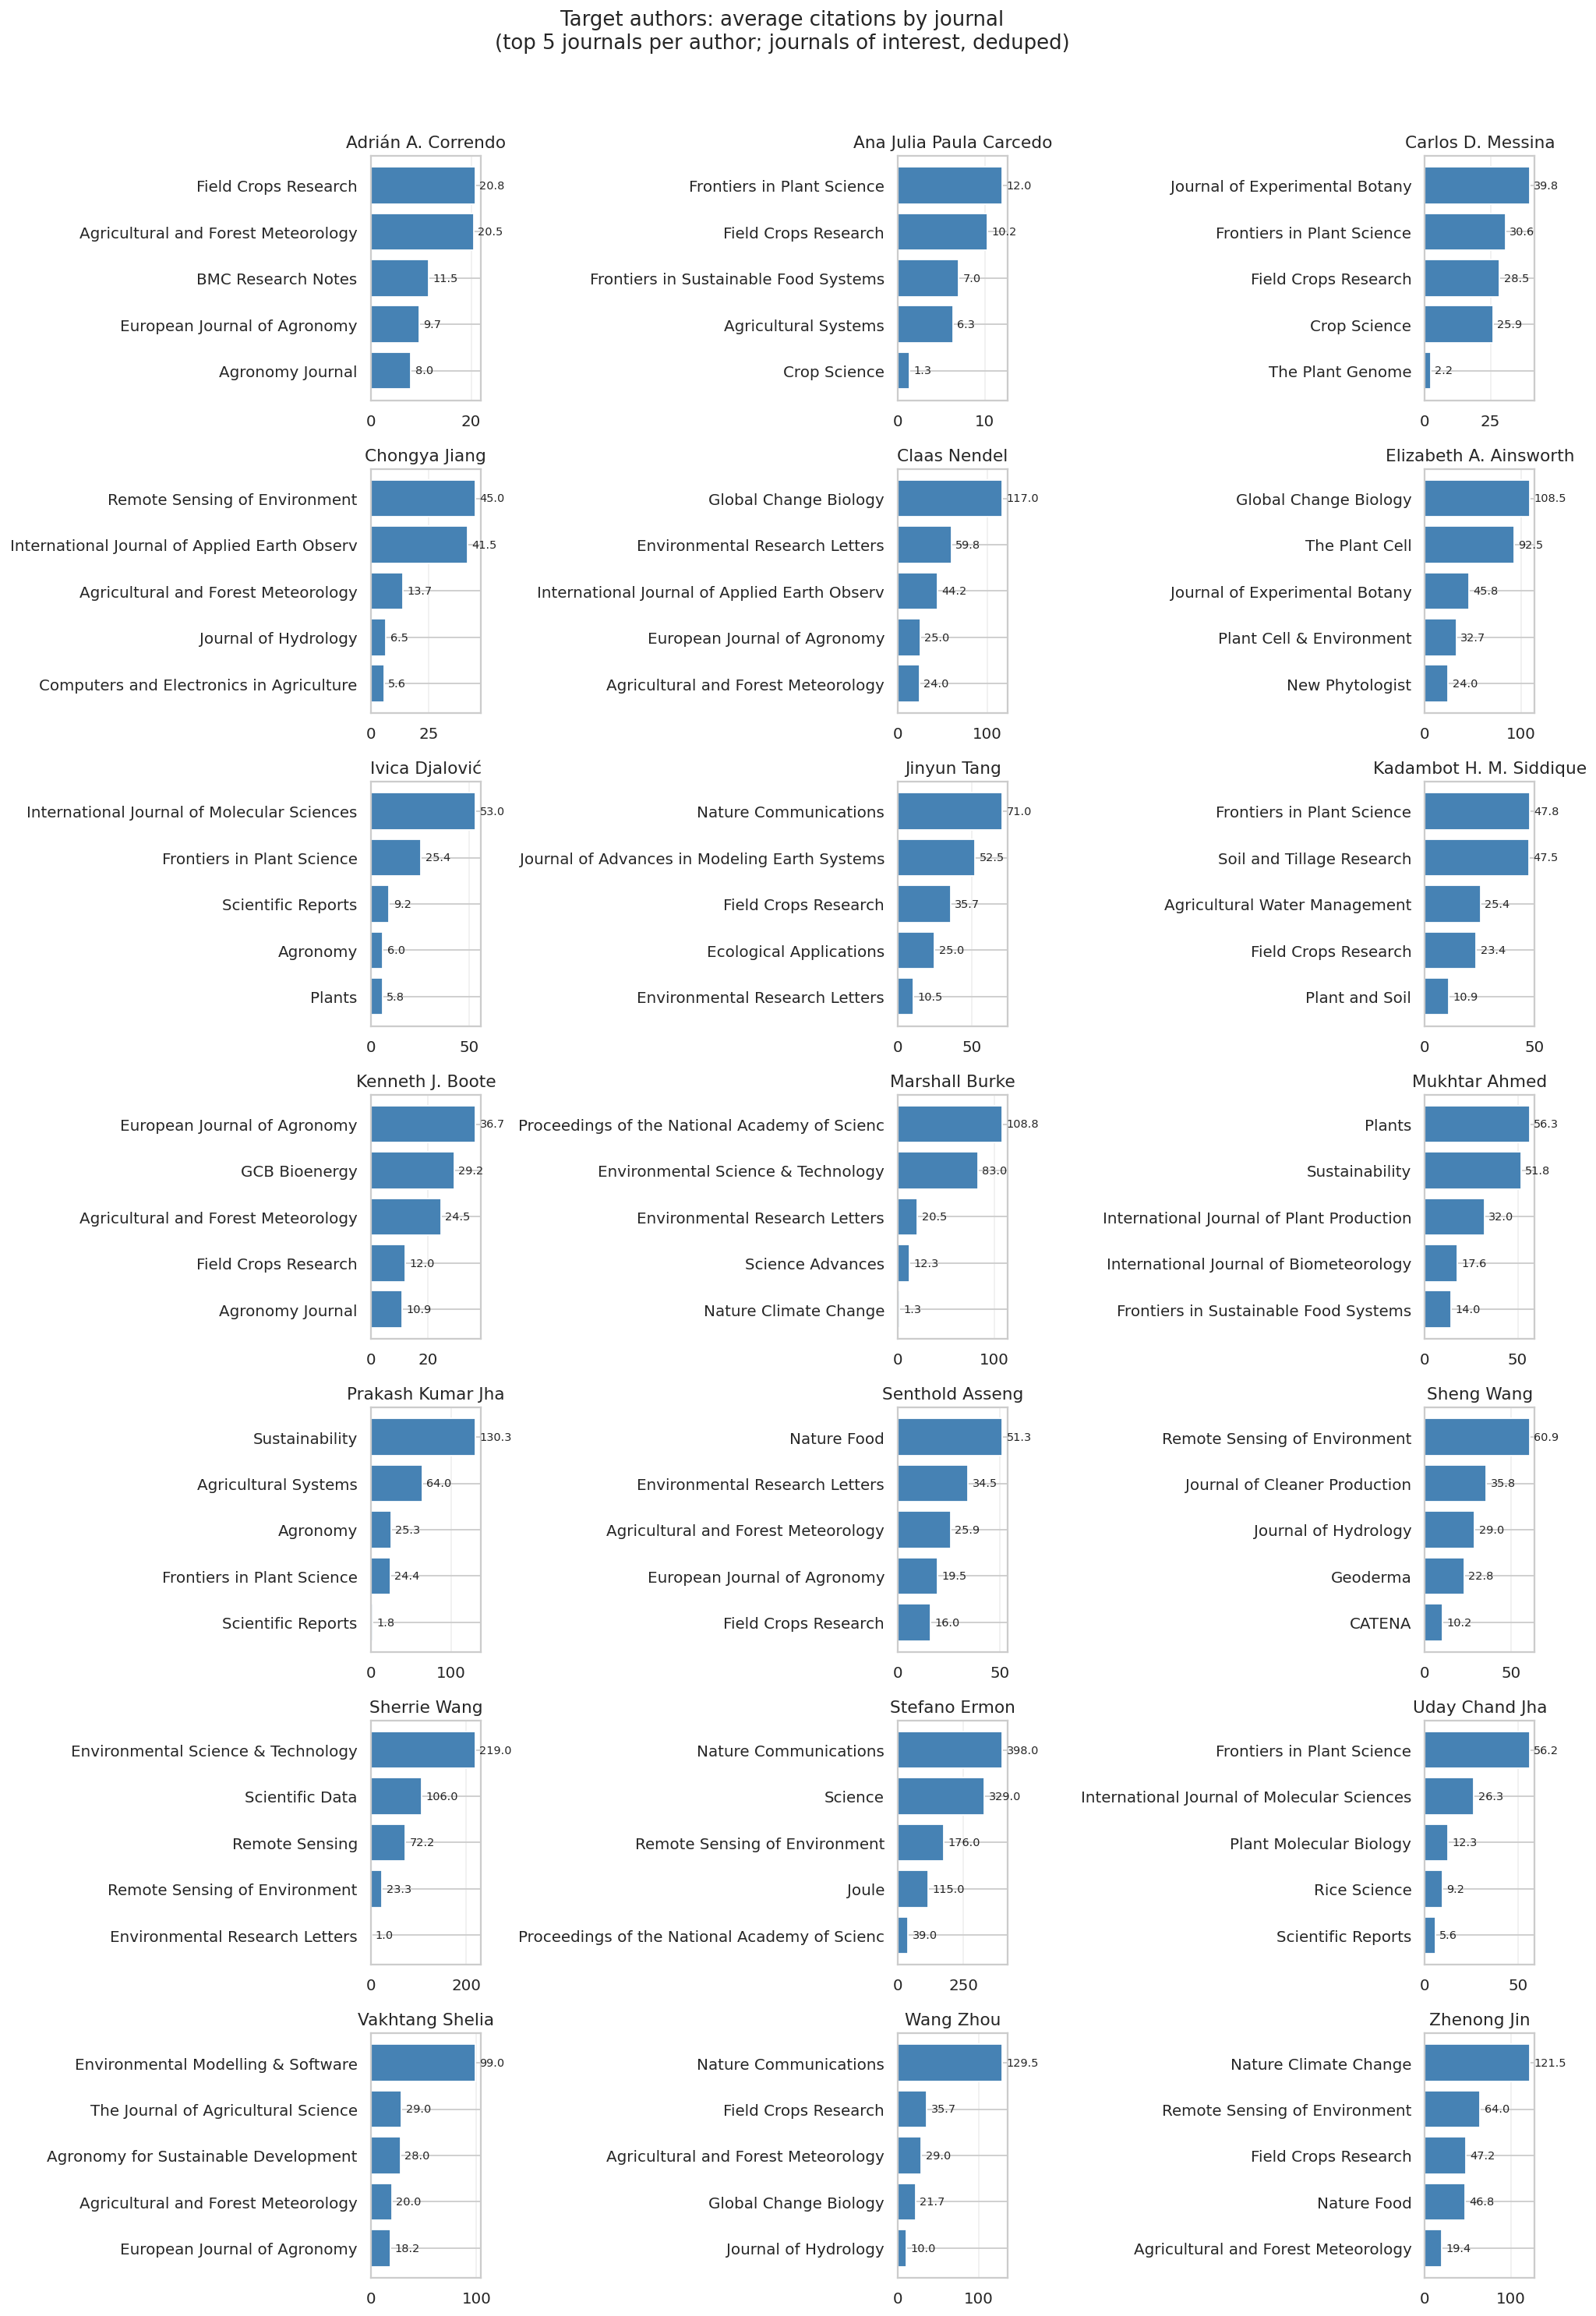

In [247]:
# ── Target authors: avg citations by journal (top 5 per author) ─────────────────
TOP_JOURNALS_PER_AUTHOR = 5

df_aj = (
    filtered_coauthors_dedup
    .dropna(subset=["journal_display_name", "total_citations", "queried_author"])
    .groupby(["queried_author", "journal_display_name"])
    .agg(
        n_papers=("article_id", "count"),
        avg_citations=("total_citations", "mean"),
        median_citations=("total_citations", "median"),
    )
    .reset_index()
)

# Keep top journals per author by paper count
Top_journals = (
    df_aj.sort_values(["queried_author", "n_papers", "avg_citations"], ascending=[True, False, False])
    .groupby("queried_author")
    .head(TOP_JOURNALS_PER_AUTHOR)
)

authors = Top_journals["queried_author"].unique().tolist()
n_authors = len(authors)

ncols = 3
nrows = int(np.ceil(n_authors / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.2 * nrows), squeeze=False)
axes_flat = axes.flatten()

for i, author in enumerate(authors):
    ax = axes_flat[i]
    data = (
        Top_journals[Top_journals["queried_author"] == author]
        .sort_values("avg_citations", ascending=True)
    )
    bars = ax.barh(
        data["journal_display_name"].str[:45],
        data["avg_citations"],
        color="steelblue",
        edgecolor="white",
    )
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)
    ax.set_title(author)
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.3)

# Hide unused axes
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("Target authors: average citations by journal\n(top 5 journals per author; journals of interest, deduped)", y=1.02)
plt.tight_layout()
plt.show()



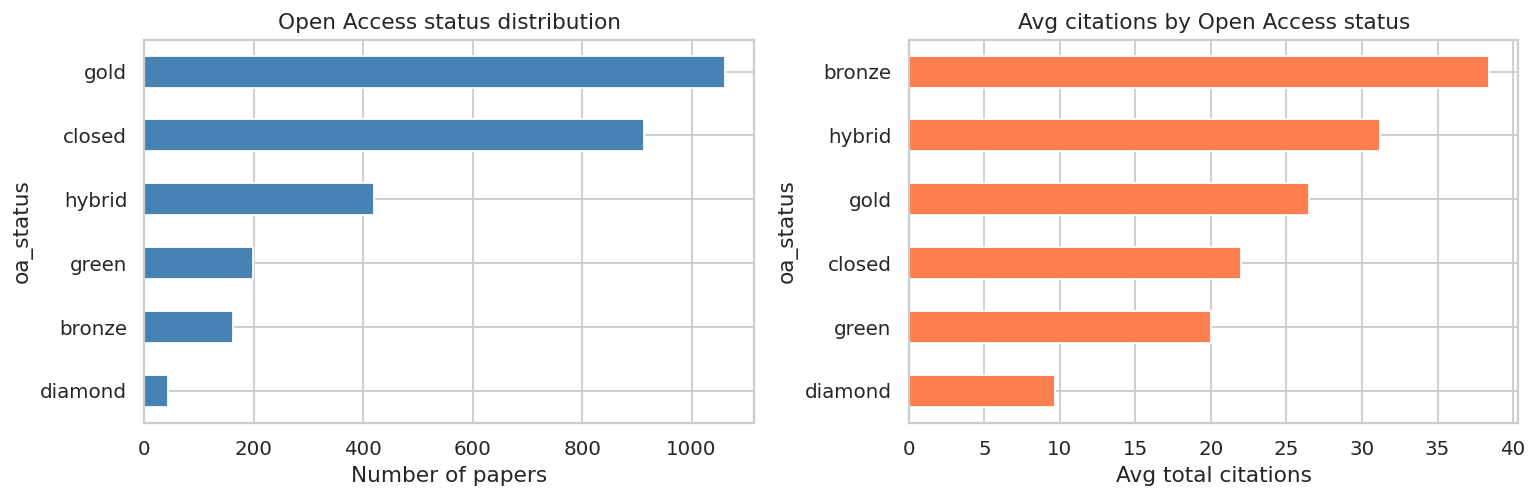

In [248]:
# ── Open Access status breakdown ──────────────────────────────────────────────
oa_counts = (
    filtered_all_df["oa_status"]
    .fillna("unknown")
    .value_counts()
    .sort_values(ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# OA status distribution
oa_counts.plot.barh(ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Open Access status distribution")
axes[0].set_xlabel("Number of papers")

# OA status vs avg citations
oa_cit = (
    all_df_dedup
    .assign(oa_status=lambda d: d["oa_status"].fillna("unknown"))
    .groupby("oa_status")["total_citations"]
    .mean()
    .sort_values(ascending=True)
)
oa_cit.plot.barh(ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Avg citations by Open Access status")
axes[1].set_xlabel("Avg total citations")

plt.tight_layout()
plt.show()

## Labels
### Diamond,
"The ""Gold Standard"": Published in a journal that is free for both authors to publish in and readers to read. No fees involved."
### Gold,
"Published in a fully Open Access journal. Usually, authors (or their institutions) pay an APC (Article Processing Charge) to make it free for everyone."
### Hybrid,
"Published in a ""subscription"" journal (like Nature), but the author paid a specific fee to make their individual article open access."
### Bronze,
"Free to read on the publisher's website, but it has no clear license (like Creative Commons). The publisher could put it back behind a paywall at any time."
### Green,
"The version on the publisher's site is ""Closed,"" but the author has uploaded a free copy (like a preprint or post-print) to a repository (like arXiv or a university library)."

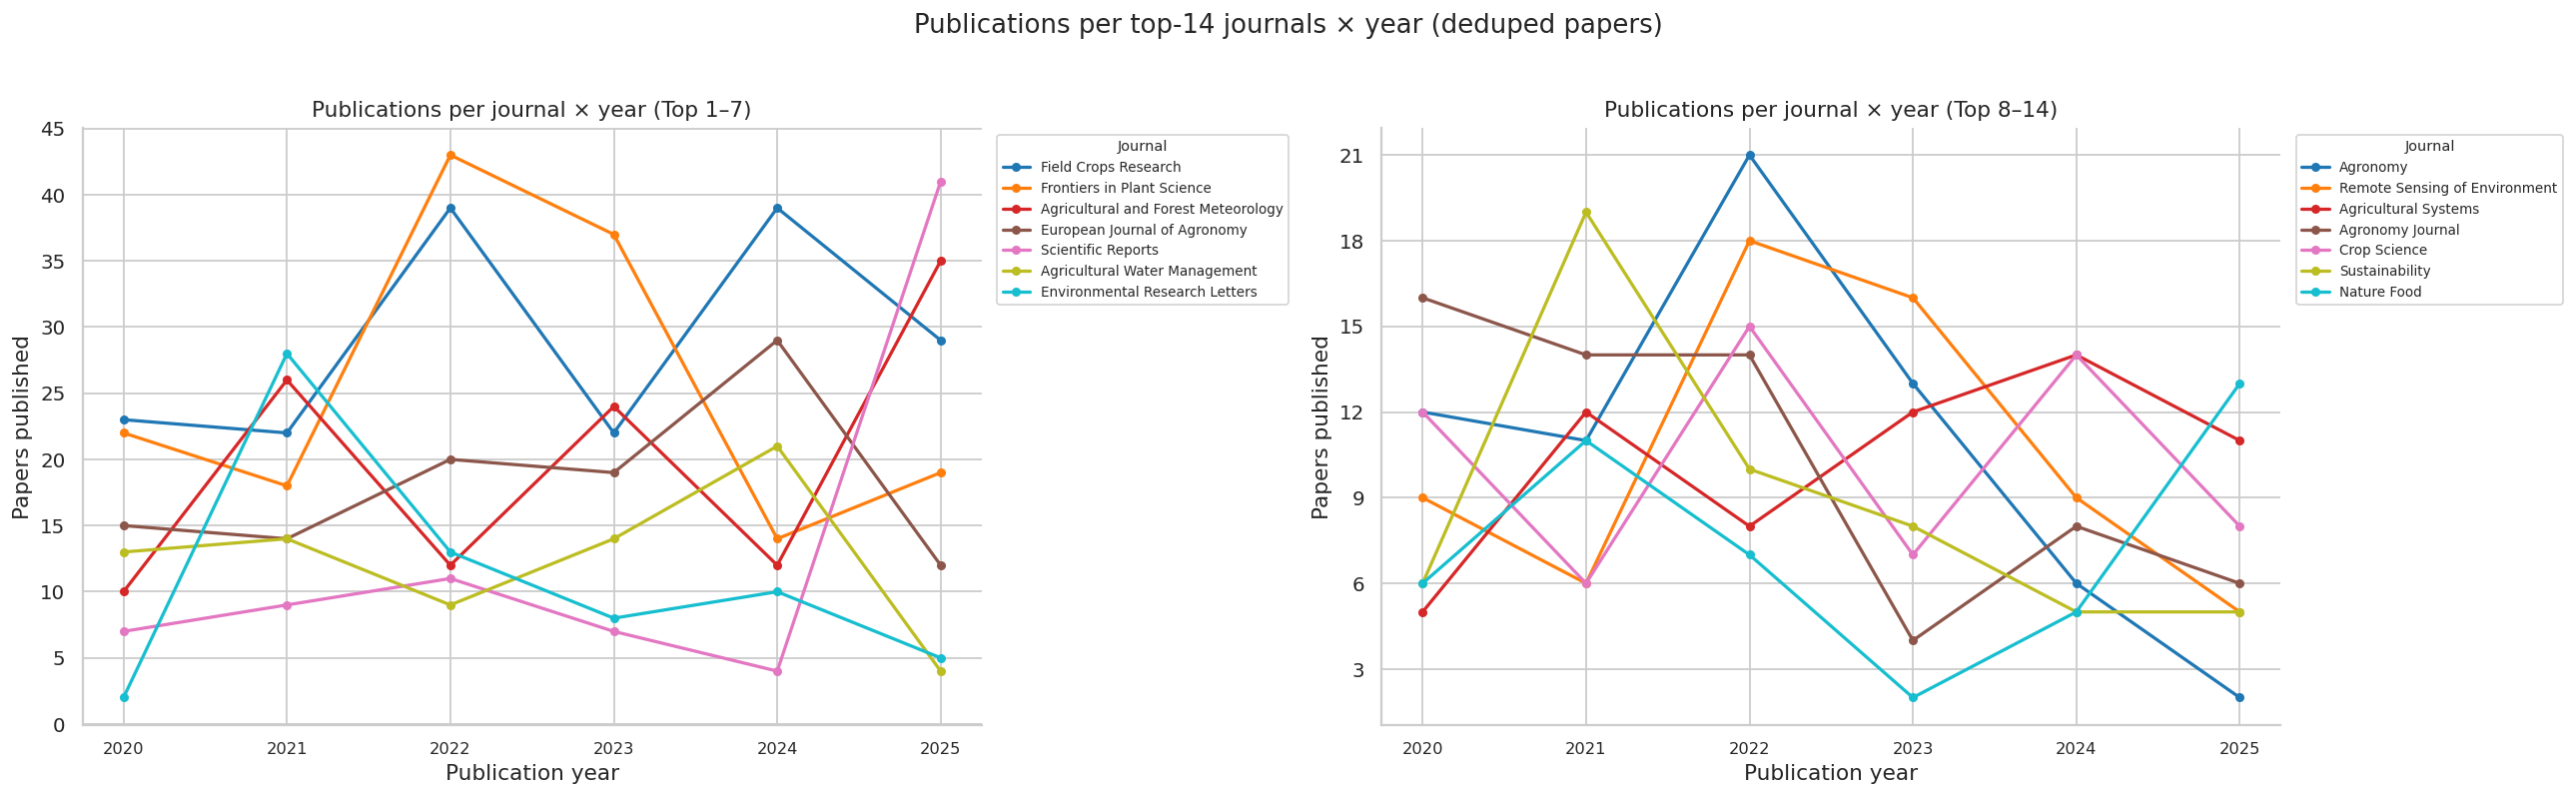

In [249]:

# ── Publications per top journal × year (line charts, split into 2 groups of 7) ──
top15_journals = (
    filtered_all_df.dropna(subset=["journal_display_name"])
    .groupby("journal_display_name")["article_id"].count()
    .nlargest(14).index.tolist()
)

jnl_year_pivot = (
    filtered_all_df
    .dropna(subset=["journal_display_name", "publication_year"])
    .query("journal_display_name in @top15_journals")
    .groupby(["journal_display_name", "publication_year"])
    .size()
    .unstack(fill_value=0)
    .reindex(top15_journals)
)
# Sort by total publications descending
jnl_year_pivot = jnl_year_pivot.loc[jnl_year_pivot.sum(axis=1).sort_values(ascending=False).index]

groups = [jnl_year_pivot.iloc[:7], jnl_year_pivot.iloc[7:]]
group_labels = ["Top 1–7", "Top 8–14"]

fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=False)

for ax, group_df, g_label in zip(axes, groups, group_labels):
    cmap_lines = plt.get_cmap("tab10", len(group_df))
    for i, (journal, row) in enumerate(group_df.iterrows()):
        ax.plot(row.index.astype(int), row.values, marker="o", markersize=4,
                linewidth=1.8, label=journal, color=cmap_lines(i))
    ax.set_title(f"Publications per journal × year ({g_label})")
    ax.set_xlabel("Publication year")
    ax.set_ylabel("Papers published")
    ax.tick_params(axis="x", rotation=0, labelsize=9)
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=7.5,
              frameon=True, title="Journal", title_fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Publications per top-14 journals × year (deduped papers)", y=1.02)
plt.tight_layout()
plt.show()


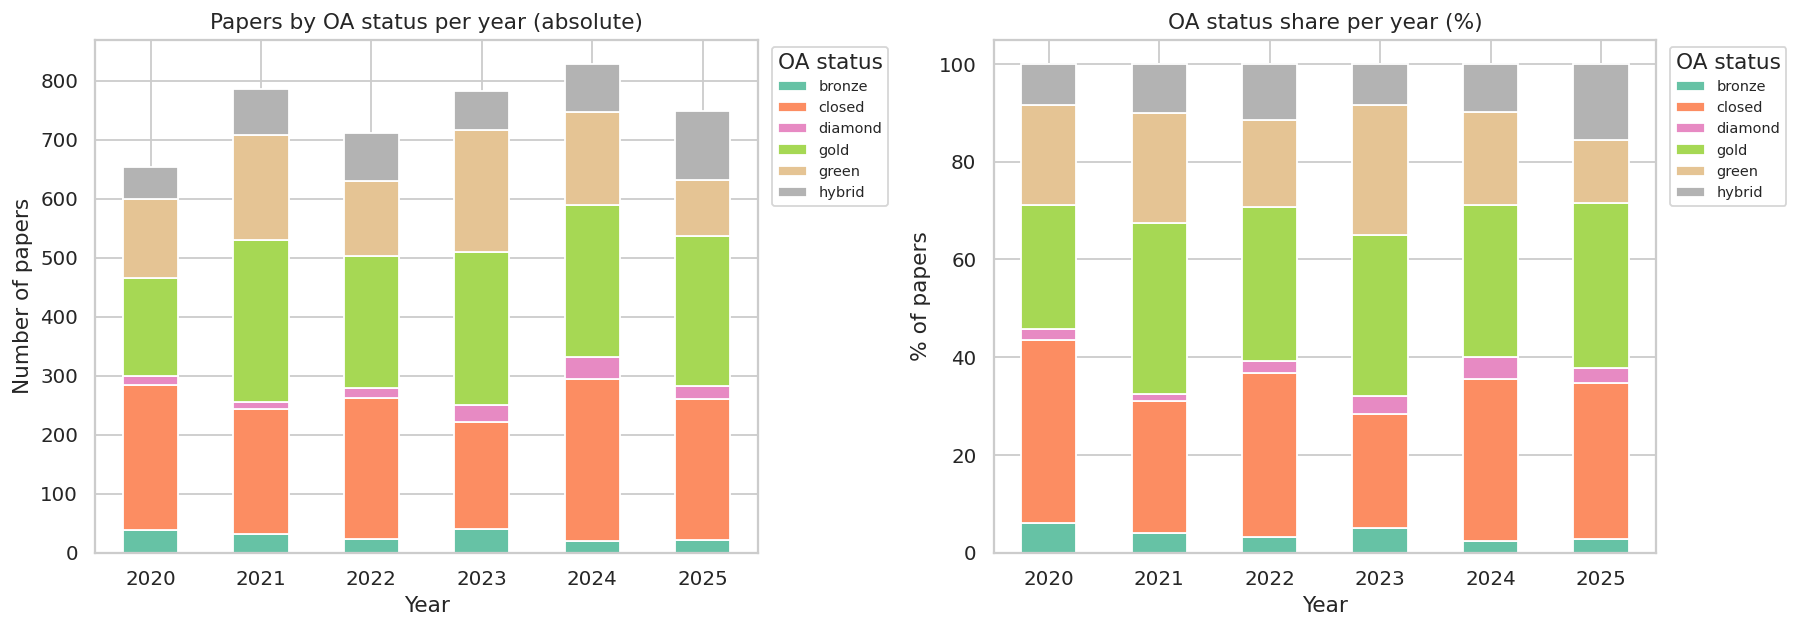

In [250]:
# ── Open Access trends over time ──────────────────────────────────────────────
oa_yearly = (
    all_df_dedup
    .dropna(subset=["publication_year", "oa_status"])
    .groupby(["publication_year", "oa_status"])
    .size()
    .unstack(fill_value=0)
)
# Express as % of papers per year
oa_yearly_pct = oa_yearly.div(oa_yearly.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute counts stacked
oa_yearly.plot.bar(stacked=True, ax=axes[0], colormap="Set2", edgecolor="white")
axes[0].set_title("Papers by OA status per year (absolute)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of papers")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="OA status", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

# Right: percentage stacked
oa_yearly_pct.plot.bar(stacked=True, ax=axes[1], colormap="Set2", edgecolor="white")
axes[1].set_title("OA status share per year (%)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("% of papers")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="OA status", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()


<!-- ---
## 7. Concept & Topic Tag Analysis
OpenAlex tags every paper with structured **concepts** at multiple specificity levels (0 = broadest, 3+ = most specific).  
This section surfaces dominant research themes without topic modeling. -->

In [251]:
# # ── Extract concept data from Target_author_works ───────────────────────────────────
# concept_data = defaultdict(lambda: {"name": "", "level": 0, "count": 0, "score_sum": 0.0, "paper_ids": set()})

# for work in all_works:
#     wid = work.get("id")
#     for concept in work.get("concepts", []):
#         cid = concept["id"]
#         concept_data[cid]["name"]       = concept["display_name"]
#         concept_data[cid]["level"]      = concept["level"]
#         concept_data[cid]["count"]     += 1
#         concept_data[cid]["score_sum"] += concept.get("score", 0.0)
#         concept_data[cid]["paper_ids"].add(wid)

# concept_df = pd.DataFrame([
#     {
#         "concept_id":   cid,
#         "concept_name": d["name"],
#         "level":        d["level"],
#         "count":        d["count"],
#         "score_sum":    round(d["score_sum"], 2),
#         "avg_score":    round(d["score_sum"] / d["count"], 3),
#         "n_papers":     len(d["paper_ids"]),
#     }
#     for cid, d in concept_data.items()
# ]).sort_values("count", ascending=False).reset_index(drop=True)

# print(f"Unique concepts extracted: {len(concept_df)}")
# print(f"\nConcepts by level:")
# print(concept_df.groupby("level")["concept_id"].count().rename("count").to_string())
# concept_df.head(10)

In [252]:
# # ── Top 30 concepts at level ≥ 2 by occurrence count ─────────────────────────
# top_concepts = (
#     concept_df[concept_df["level"] >= 2]
#     .nlargest(30, "count")
#     .sort_values("count", ascending=True)
#     .reset_index(drop=True)
# )

# fig, ax = plt.subplots(figsize=(10, 9))
# colors_list = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(top_concepts)))
# bars = ax.barh(top_concepts["concept_name"], top_concepts["count"],
#                color=colors_list, edgecolor="white")
# ax.bar_label(bars, padding=3, fontsize=8)
# ax.set_xlabel("Number of papers tagged with this concept")
# ax.set_title("Top 30 specific concepts (level ≥ 2) in Target_author author publications")
# plt.tight_layout()
# plt.show()

In [253]:
# # ── Concept co-occurrence: which concepts share the same papers? ──────────────
# # Build paper → concept list mapping (level ≥ 2, top 25 concepts)
# top_concept_names = set(
#     concept_df[concept_df["level"] >= 2].nlargest(25, "count")["concept_name"]
# )

# paper_concepts = defaultdict(set)
# for work in Target_author_works:
#     wid = work.get("id")
#     for c in work.get("concepts", []):
#         if c["level"] >= 2 and c["display_name"] in top_concept_names:
#             paper_concepts[wid].add(c["display_name"])

# # Build co-occurrence matrix
# co_occur = defaultdict(Counter)
# for cset in paper_concepts.values():
#     clist = sorted(cset)
#     for i, a in enumerate(clist):
#         for b in clist[i + 1:]:
#             co_occur[a][b] += 1
#             co_occur[b][a] += 1

# all_concepts = sorted(top_concept_names)
# co_matrix = pd.DataFrame(
#     [[co_occur[a][b] for b in all_concepts] for a in all_concepts],
#     index=all_concepts, columns=all_concepts,
# )

# fig, ax = plt.subplots(figsize=(13, 11))
# mask = np.triu(np.ones_like(co_matrix, dtype=bool))  # upper triangle
# sns.heatmap(
#     co_matrix, mask=mask, annot=False, fmt="d", cmap="YlOrRd",
#     linewidths=0.3, ax=ax, cbar_kws={"label": "co-occurrences"},
# )
# ax.set_title("Concept co-occurrence heatmap (top 25 specific concepts, level ≥ 2)")
# ax.tick_params(axis="x", rotation=45, labelsize=8)
# ax.tick_params(axis="y", labelsize=8)
# plt.tight_layout()
# plt.show()

In [254]:
# # ── Top concept pairs ─────────────────────────────────────────────────────────
# pairs = []
# for a in all_concepts:
#     for b in all_concepts:
#         if a < b and co_occur[a][b] > 0:
#             pairs.append({"concept_a": a, "concept_b": b, "co_occurrences": co_occur[a][b]})

# pairs_df = pd.DataFrame(pairs).sort_values("co_occurrences", ascending=False).reset_index(drop=True)
# print("Top 20 concept pairs by co-occurrence:\n")
# print(pairs_df.head(20).to_string(index=False))

### 7c. Structured Topic Hierarchy (OpenAlex Topics)
OpenAlex also assigns each paper a **Target_author topic** with a 4-level hierarchy: Domain → Field → Subfield → Topic.  
This is cleaner and more structured than the legacy concepts — we use it here for time-based analysis.


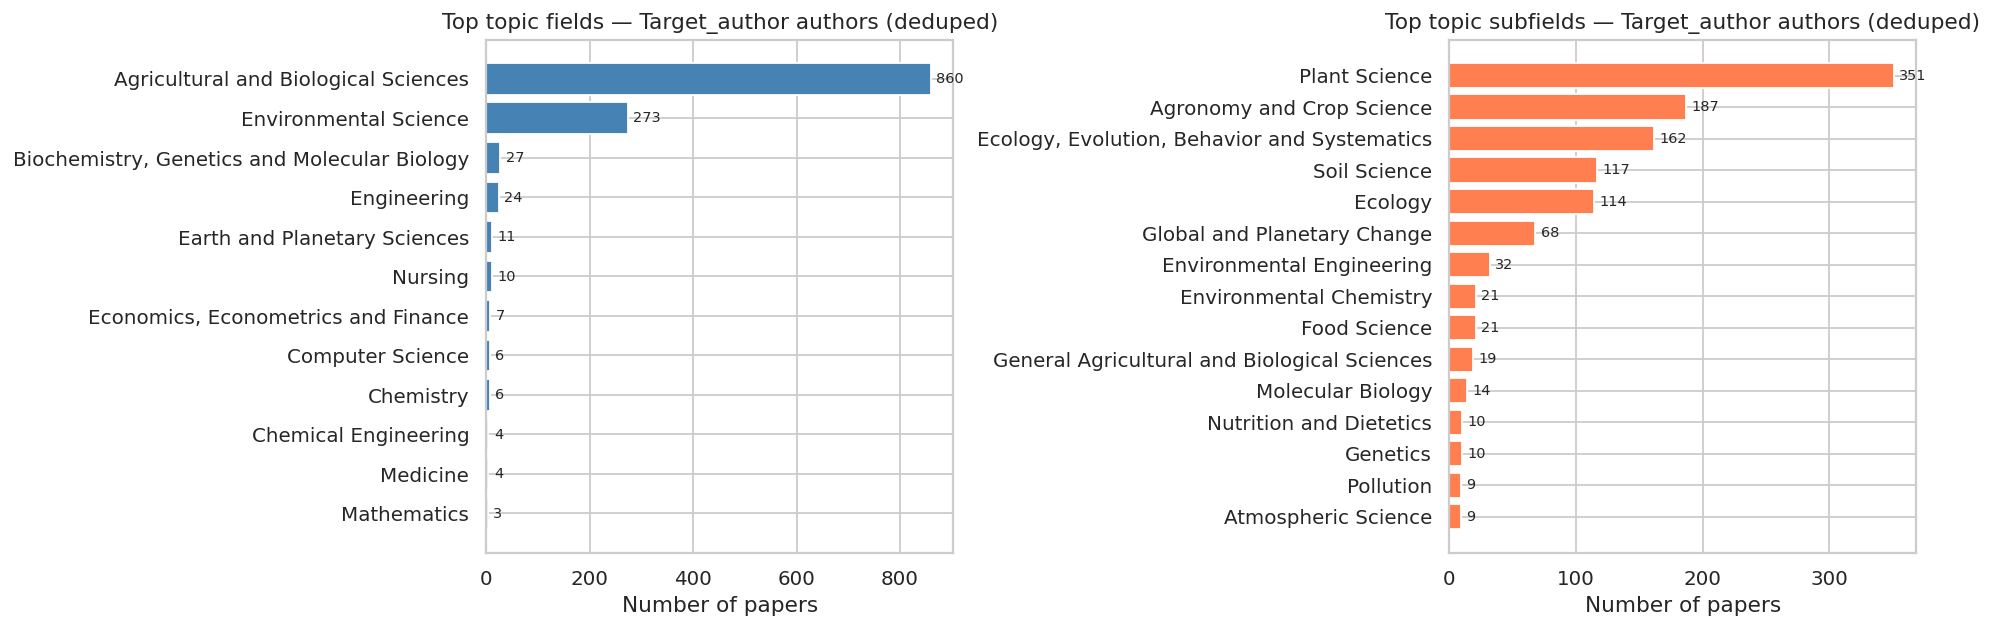

In [255]:
# ── Topic field & subfield distribution (Target_author deduped papers) ──────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: top topic fields
top_tf = (
   filtered_TargetA_df.dropna(subset=["topic_field"])
    .groupby("topic_field")["article_id"].count()
    .sort_values(ascending=True).tail(12)
)
bars = axes[0].barh(top_tf.index, top_tf.values, color="steelblue", edgecolor="white")
axes[0].bar_label(bars, padding=3, fontsize=8)
axes[0].set_title("Top topic fields — Target_author authors (deduped)")
axes[0].set_xlabel("Number of papers")

# Right: top subfields
top_sf = (
    filtered_TargetA_df.dropna(subset=["topic_subfield"])
    .groupby("topic_subfield")["article_id"].count()
    .sort_values(ascending=True).tail(15)
)
bars2 = axes[1].barh(top_sf.index, top_sf.values, color="coral", edgecolor="white")
axes[1].bar_label(bars2, padding=3, fontsize=8)
axes[1].set_title("Top topic subfields — Target_author authors (deduped)")
axes[1].set_xlabel("Number of papers")

plt.tight_layout()
plt.show()


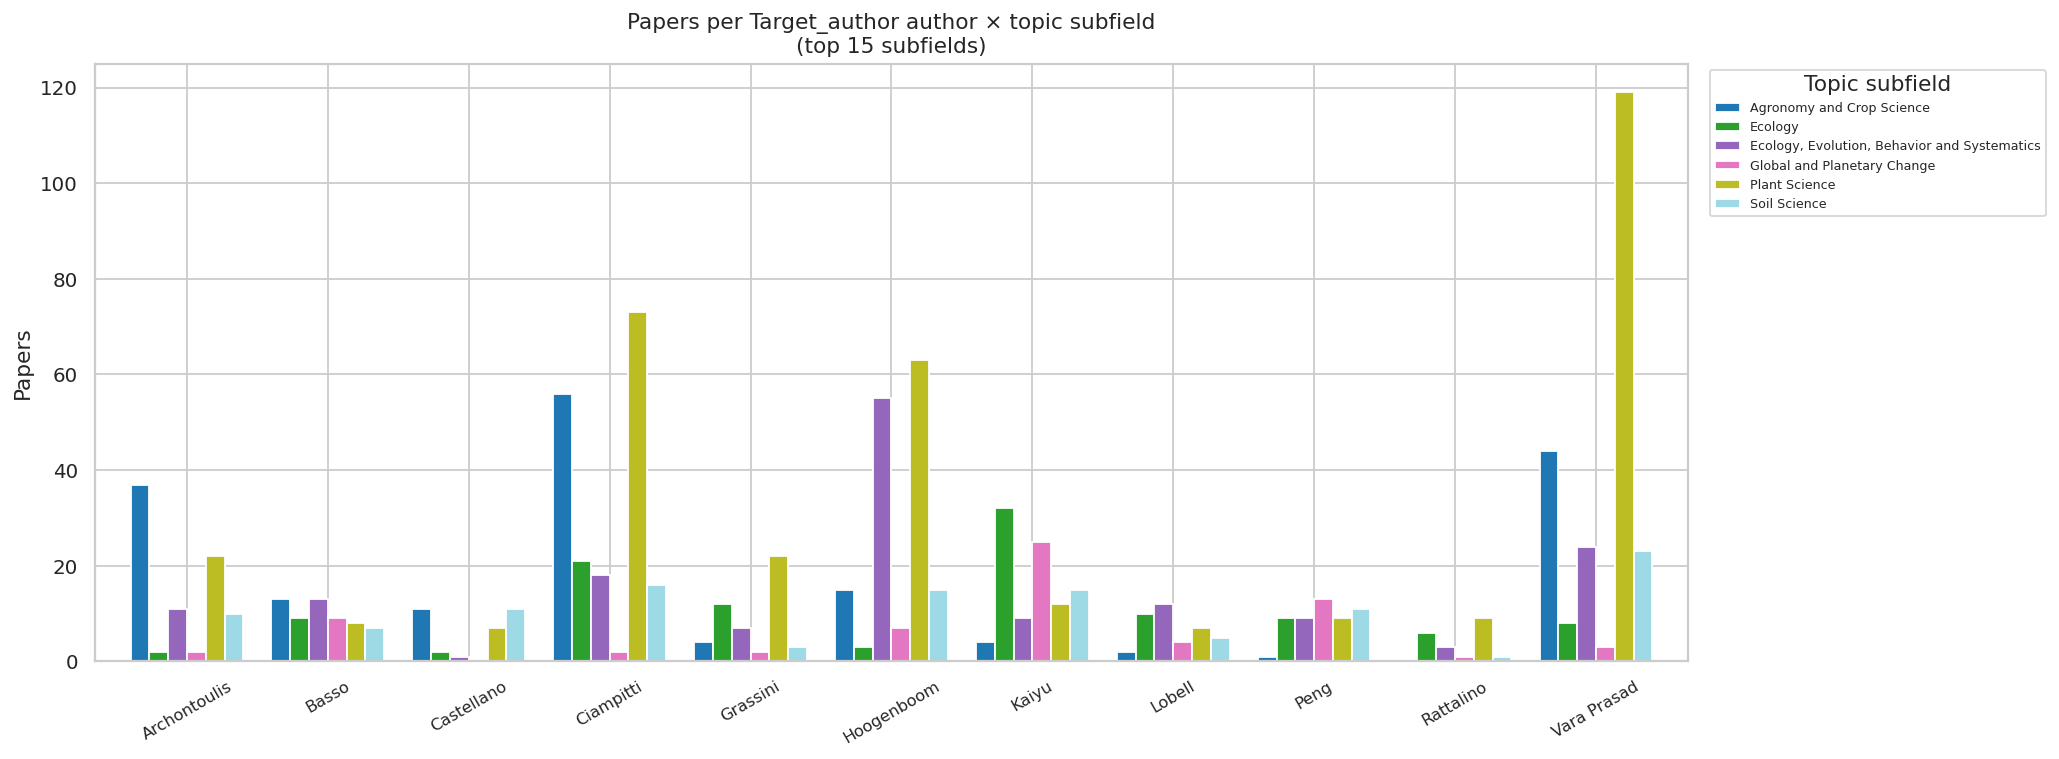


Top 3 topic subfields per Target_author author:
queried_author                               topic_subfield   n
   Vara Prasad                                Plant Science 119
     Ciampitti                                Plant Science  73
    Hoogenboom                                Plant Science  63
     Ciampitti                    Agronomy and Crop Science  56
    Hoogenboom Ecology, Evolution, Behavior and Systematics  55
   Vara Prasad                    Agronomy and Crop Science  44
  Archontoulis                    Agronomy and Crop Science  37
         Kaiyu                                      Ecology  32
         Kaiyu                  Global and Planetary Change  25
   Vara Prasad Ecology, Evolution, Behavior and Systematics  24
  Archontoulis                                Plant Science  22
      Grassini                                Plant Science  22
     Ciampitti                                      Ecology  21
    Hoogenboom                    Agronomy and Crop Sci

In [256]:

# ── Dominant topic subfield per Target_author author ────────────────────────────────
author_topic = (
    filtered_TargetA_df.dropna(subset=["topic_subfield"])
    .groupby(["queried_author", "topic_subfield"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .groupby("queried_author")
    .head(3)          # top 3 subfields per author
    .reset_index(drop=True)
)

# Also make a pivot for a bar chart (top 15 subfields)
top_subfields = author_topic.groupby("topic_subfield")["n"].sum().nlargest(15).index
author_subfield_pivot = (
    filtered_TargetA_df.dropna(subset=["topic_subfield"])
    .query("topic_subfield in @top_subfields")
    .groupby(["queried_author", "topic_subfield"])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(16, 6))
author_subfield_pivot.plot(
    kind="bar",
    stacked=False,
    colormap="tab20",
    ax=ax,
    width=0.8
)
ax.set_title("Papers per Target_author author × topic subfield\n(top 15 subfields)")
ax.set_xlabel("")
ax.set_ylabel("Papers")
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.legend(title="Topic subfield", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()

print("\nTop 3 topic subfields per Target_author author:")
print(author_topic.to_string(index=False))


### 7b. Concept Trends Over Time
How has the prevalence of each research theme shifted year by year (2020–2025)?

In [257]:
# # ── Build concept × year frequency table ─────────────────────────────────────
# # For every paper in Target_author_works, record which concepts it has per pub year
# concept_year_rows = []
# for work in Target_author_works:
#     year = work.get("publication_year")
#     if not year:
#         continue
#     for c in work.get("concepts", []):
#         if c["level"] >= 2:
#             concept_year_rows.append({
#                 "concept_name": c["display_name"],
#                 "year":         year,
#                 "score":        c.get("score", 0.0),
#             })

# concept_year_df = pd.DataFrame(concept_year_rows)

# # Total papers per year (denominator for normalisation)
# papers_per_year = (
#     pd.DataFrame([
#         {"year": w.get("publication_year"), "article_id": w.get("id")}
#         for w in Target_author_works if w.get("publication_year")
#     ])
#     .drop_duplicates("article_id")
#     .groupby("year").size()
#     .rename("total_papers")
# )

# # Count appearances of each concept per year
# concept_yearly = (
#     concept_year_df
#     .groupby(["concept_name", "year"])
#     .size()
#     .reset_index(name="n_papers")
# )

# # Join with total papers to get % prevalence
# concept_yearly = concept_yearly.merge(
#     papers_per_year.reset_index(), on="year", how="left"
# )
# concept_yearly["pct_papers"] = (concept_yearly["n_papers"] / concept_yearly["total_papers"] * 100).round(2)

# # Pivot: rows = concept, cols = year
# concept_pivot_abs = (
#     concept_yearly.pivot_table(index="concept_name", columns="year",
#                                values="n_papers", aggfunc="sum", fill_value=0)
# )
# concept_pivot_pct = (
#     concept_yearly.pivot_table(index="concept_name", columns="year",
#                                values="pct_papers", aggfunc="mean", fill_value=0)
# )

# print(f"Concepts tracked: {len(concept_pivot_abs)}  |  Years: {list(concept_pivot_abs.columns)}")

In [258]:
# # ── Line chart: top 15 concepts — % of papers per year ───────────────────────
# TOP_N = 15
# # Select top concepts by total count across all years
# top15_names = (
#     concept_pivot_abs.sum(axis=1)
#     .nlargest(TOP_N)
#     .index.tolist()
# )

# top15_pct = concept_pivot_pct.loc[
#     concept_pivot_pct.index.isin(top15_names)
# ].T  # transpose so years are rows

# years_available = sorted(top15_pct.index)
# top15_pct = top15_pct.loc[years_available]

# fig, ax = plt.subplots(figsize=(13, 6))
# cmap = plt.cm.get_cmap("tab20", TOP_N)
# for i, concept in enumerate(top15_names):
#     if concept in top15_pct.columns:
#         ax.plot(top15_pct.index, top15_pct[concept],
#                 marker="o", linewidth=2, label=concept, color=cmap(i))

# ax.set_xlabel("Publication year")
# ax.set_ylabel("% of papers tagged with concept")
# ax.set_title(f"Top {TOP_N} concepts — share of annual papers (2020–2025)")
# ax.set_xticks(years_available)
# ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, frameon=True)
# ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
# plt.tight_layout()
# plt.show()

In [259]:
# # ── Heatmap: concept × year (% prevalence, top 25 concepts) ──────────────────
# top25_names = (
#     concept_pivot_abs.sum(axis=1)
#     .nlargest(25)
#     .index.tolist()
# )

# heat_data = (
#     concept_pivot_pct.loc[concept_pivot_pct.index.isin(top25_names)]
#     .reindex(top25_names)
#     .sort_values(by=concept_pivot_pct.columns.max(), ascending=False)  # sort by most recent year
# )

# fig, ax = plt.subplots(figsize=(11, 9))
# sns.heatmap(
#     heat_data.round(1),
#     annot=True, fmt=".1f",
#     cmap="YlGnBu",
#     linewidths=0.4,
#     cbar_kws={"label": "% of papers tagged"},
#     ax=ax,
# )
# ax.set_title("Concept prevalence heatmap (% of papers per year)\nTop 25 specific concepts · Target_author authors")
# ax.set_xlabel("Publication year")
# ax.set_ylabel("")
# ax.tick_params(axis="x", rotation=0)
# ax.tick_params(axis="y", labelsize=9)
# plt.tight_layout()
# plt.show()

In [260]:
# # ── Rising vs declining concepts: slope-based ranking ────────────────────────
# # Fit a linear trend (slope) to the % prevalence time series for each concept
# from numpy.polynomial import polynomial as P

# years_arr = np.array(sorted(concept_pivot_pct.columns), dtype=float)

# slopes = {}
# for concept in concept_pivot_pct.index:
#     vals = concept_pivot_pct.loc[concept, sorted(concept_pivot_pct.columns)].values.astype(float)
#     if vals.sum() == 0:
#         continue
#     # Linear fit: slope of % per year
#     coef = np.polyfit(years_arr, vals, 1)
#     slopes[concept] = coef[0]  # slope (pp per year)

# slope_df = (
#     pd.Series(slopes, name="slope_pp_per_yr")
#     .reset_index()
#     .rename(columns={"index": "concept_name"})
#     .merge(
#         concept_pivot_abs.sum(axis=1).rename("total_appearances").reset_index()
#         .rename(columns={"concept_name": "concept_name"}),
#         on="concept_name", how="left",
#     )
#     .query("total_appearances >= 10")   # only concepts with meaningful sample size
#     .sort_values("slope_pp_per_yr")
# )

# # Top 10 rising & top 10 declining
# rising   = slope_df.nlargest(10, "slope_pp_per_yr")
# declining = slope_df.nsmallest(10, "slope_pp_per_yr")
# combined = pd.concat([declining, rising]).reset_index(drop=True)

# fig, ax = plt.subplots(figsize=(11, 7))
# colors_trend = ["coral" if s < 0 else "steelblue" for s in combined["slope_pp_per_yr"]]
# bars = ax.barh(combined["concept_name"], combined["slope_pp_per_yr"],
#                color=colors_trend, edgecolor="white")
# ax.axvline(0, color="black", linewidth=0.8)
# ax.set_xlabel("Linear trend slope (percentage points per year)")
# ax.set_title("Fastest rising and declining research concepts (2020–2025)\n"
#              "Based on linear fit of annual % share · Target_author authors · min 10 appearances")
# ax.bar_label(bars, fmt="%.2f pp/yr", padding=3, fontsize=8)
# plt.tight_layout()
# plt.show()

# print("\nTop 10 rising concepts:")
# print(rising[["concept_name", "slope_pp_per_yr", "total_appearances"]].to_string(index=False))
# print("\nTop 10 declining concepts:")
# print(declining[["concept_name", "slope_pp_per_yr", "total_appearances"]].to_string(index=False))

In [261]:
# # ── Small multiples: individual trend lines for selected themes ───────────────
# # Group concepts by broad theme for easier reading
# THEME_GROUPS = {
#     "Crop & Yield":       ["Crop yield", "Grain", "Harvest", "Biomass", "Photosynthesis"],
#     "Digital / Modeling": ["Machine learning", "Remote sensing", "Crop model",
#                            "Simulation", "Artificial intelligence", "Deep learning"],
#     "Soil & Nutrients":   ["Soil organic matter", "Nitrogen", "Fertilizer",
#                            "Soil carbon", "Nitrous oxide", "Phosphorus"],
#     "Climate & Water":    ["Climate change", "Drought", "Irrigation",
#                            "Precipitation", "Evapotranspiration", "Water use efficiency"],
#     "Agronomy Practice":  ["Tillage", "Cover crop", "Crop rotation",
#                            "Planting density", "Soybean", "Maize"],
# }

# fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=False)
# axes = axes.flatten()

# for ax_idx, (theme, keywords) in enumerate(THEME_GROUPS.items()):
#     ax = axes[ax_idx]
#     found_any = False
#     for kw in keywords:
#         # Case-insensitive partial match against concept names
#         matches = [c for c in concept_pivot_pct.index
#                    if kw.lower() in c.lower()]
#         for concept in matches[:1]:   # take the best match only
#             series = concept_pivot_pct.loc[
#                 concept, sorted(concept_pivot_pct.columns)
#             ].astype(float)
#             ax.plot(series.index, series.values, marker="o",
#                     linewidth=2, label=concept)
#             found_any = True

#     ax.set_title(theme, fontsize=10, fontweight="bold")
#     ax.set_xlabel("Year", fontsize=8)
#     ax.set_ylabel("% of papers", fontsize=8)
#     ax.set_xticks(sorted(concept_pivot_pct.columns))
#     ax.tick_params(labelsize=7)
#     ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
#     if found_any:
#         ax.legend(fontsize=6.5, frameon=True, loc="best")
#     else:
#         ax.text(0.5, 0.5, "No matching concepts found",
#                 transform=ax.transAxes, ha="center", va="center",
#                 fontsize=8, color="gray")

# # Hide unused subplot
# for i in range(len(THEME_GROUPS), len(axes)):
#     axes[i].set_visible(False)

# fig.suptitle("Concept theme trends over time (2020–2025) — Target_author authors",
#              fontsize=12, fontweight="bold", y=1.01)
# plt.tight_layout()
# plt.show()

---
## 8. Temporal Trends
How has publication volume, citation reception, and topic composition evolved from 2020 to 2025?  
Which authors drove output in each year? What was the dominant research topic each year?


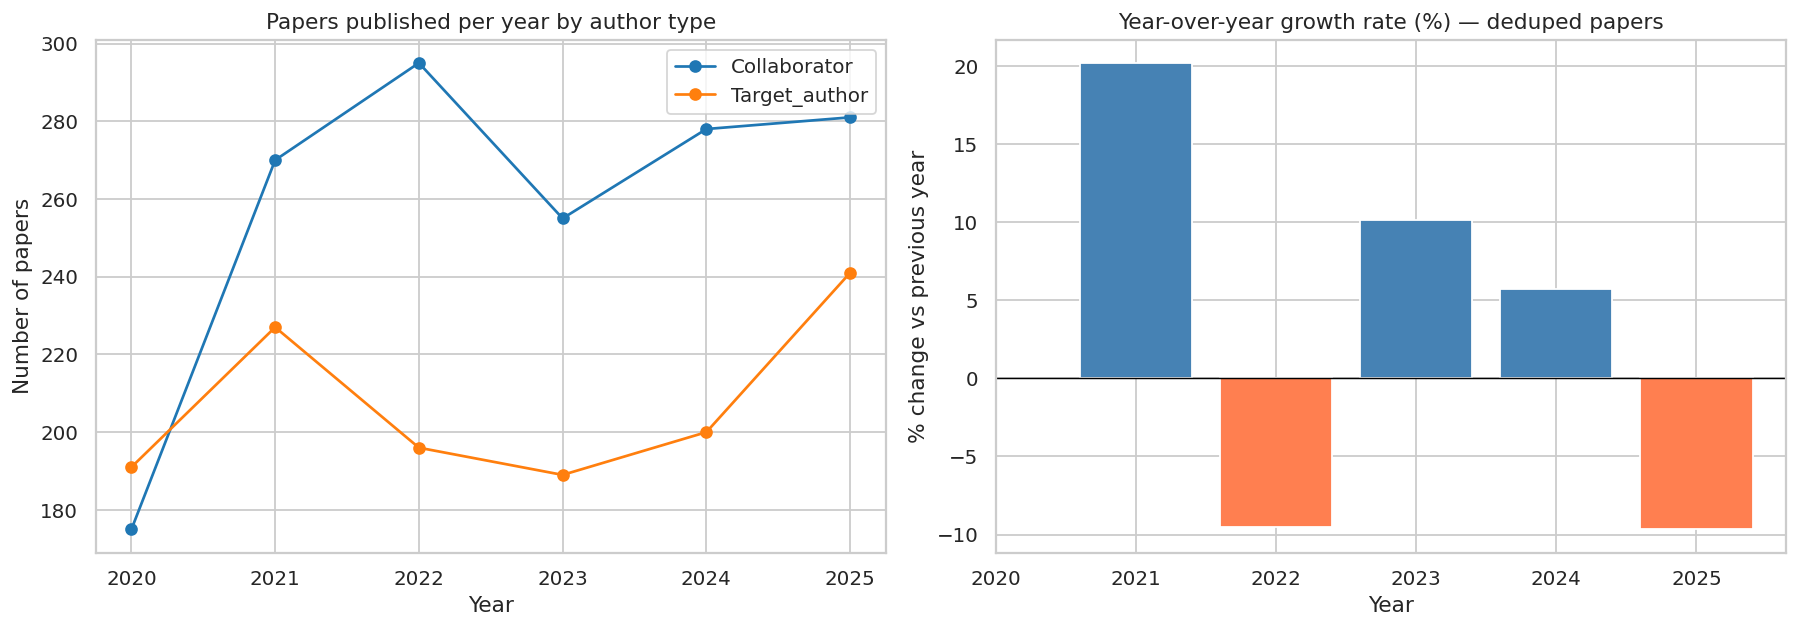

In [262]:
# ── Papers per year — split by author type ────────────────────────────────────
yearly = (
    filtered_all_df
    .dropna(subset=["publication_year"])
    .groupby(["publication_year", "author_type"])
    .size()
    .reset_index(name="n_papers")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for author_type, grp in yearly.groupby("author_type"):
    axes[0].plot(grp["publication_year"], grp["n_papers"], marker="o", label=author_type)
axes[0].set_title("Papers published per year by author type")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of papers")
axes[0].legend()
axes[0].set_xticks(sorted(yearly["publication_year"].unique()))

# Growth rate (deduped, all authors combined)
yearly_total = (
    all_df_dedup.dropna(subset=["publication_year"])
    .groupby("publication_year").size()
    .rename("n_papers")
    .reset_index()
    .sort_values("publication_year")
)
yearly_total["yoy_growth"] = yearly_total["n_papers"].pct_change() * 100

axes[1].bar(yearly_total["publication_year"], yearly_total["yoy_growth"],
            color=["coral" if v < 0 else "steelblue" for v in yearly_total["yoy_growth"]],
            edgecolor="white")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Year-over-year growth rate (%) — deduped papers")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("% change vs previous year")
axes[1].set_xticks(sorted(yearly_total["publication_year"].unique()))

plt.tight_layout()
plt.show()

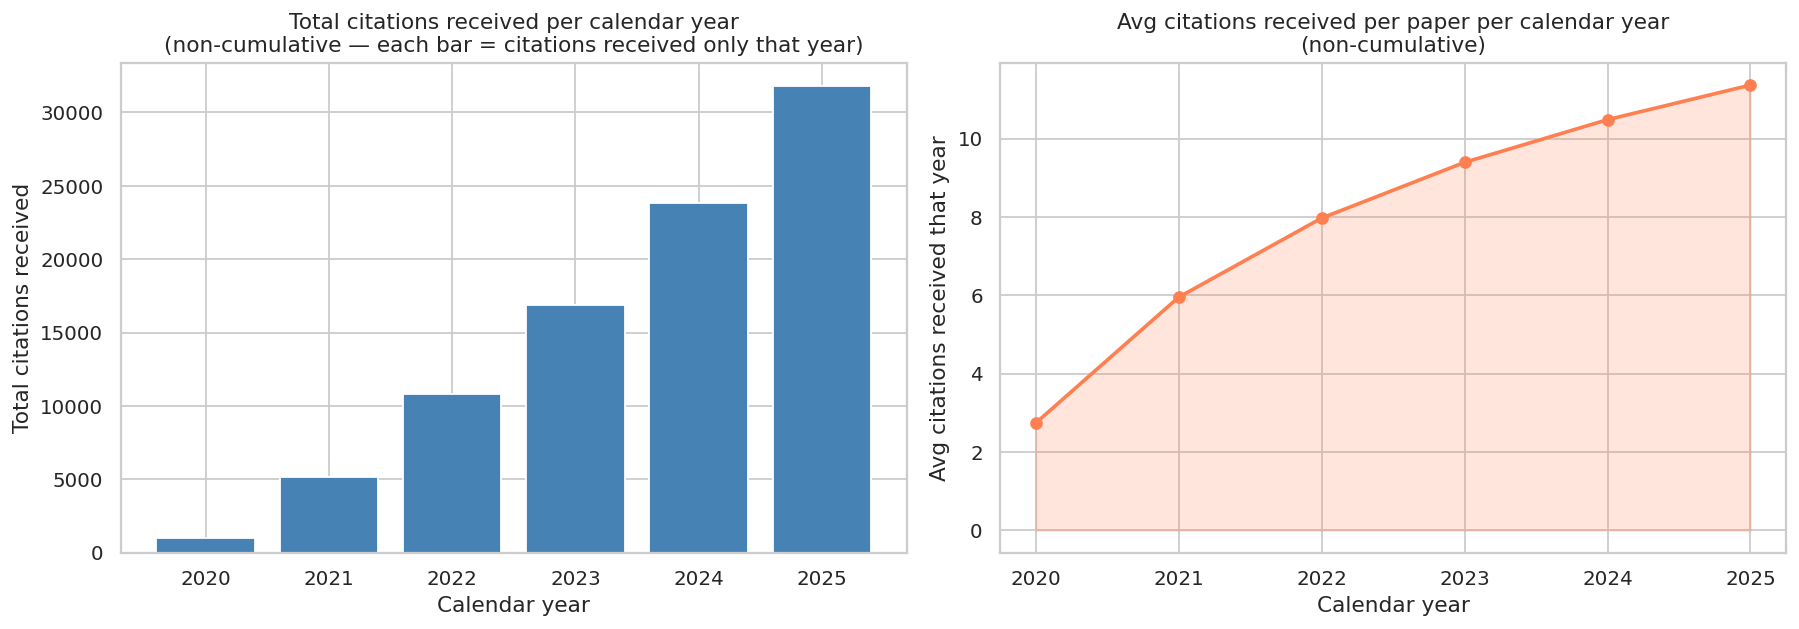

 calendar_year  total_cit   avg_cit    n
          2020     1002.0  2.737705  278
          2021     5134.0  5.949015  641
          2022    10789.0  7.968242  991
          2023    16886.0  9.391546 1313
          2024    23855.0 10.481107 1679
          2025    31795.0 11.363474 2054


In [263]:
# ── Citations received per calendar year (non-cumulative, deduped papers) ─────
# citations_year_k = citations received in (publication_year + k).
# We convert offsets → calendar years so each data point = citations
# received only in that specific year (not accumulated over all time).

cit_year_cols = [c for c in filtered_all_df.columns if c.startswith("citations_year_")]

melted = (
    filtered_all_df
    .dropna(subset=["publication_year"])
    [["article_id", "publication_year"] + cit_year_cols]
    .melt(id_vars=["article_id", "publication_year"],
          value_vars=cit_year_cols,
          var_name="cit_col", value_name="citations")
)
melted["offset"]        = melted["cit_col"].str.extract(r"(\d+)$").astype(int)
melted["calendar_year"] = melted["publication_year"].astype(int) + melted["offset"]
melted["citations"]     = melted["citations"].fillna(0)

# Keep only complete past calendar years
melted = melted[(melted["calendar_year"] >= 2020) & (melted["calendar_year"] <= CURRENT_YEAR - 1)]

cit_yearly = (
    melted.groupby("calendar_year")
    .agg(total_cit=("citations", "sum"),
         avg_cit=("citations", "mean"),
         n=("article_id", "nunique"))
    .reset_index()
    .sort_values("calendar_year")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(cit_yearly["calendar_year"], cit_yearly["total_cit"],
            color="steelblue", edgecolor="white")
axes[0].set_title("Total citations received per calendar year\n(non-cumulative — each bar = citations received only that year)")
axes[0].set_xlabel("Calendar year")
axes[0].set_ylabel("Total citations received")
axes[0].set_xticks(cit_yearly["calendar_year"])

axes[1].plot(cit_yearly["calendar_year"], cit_yearly["avg_cit"],
             marker="o", color="coral", linewidth=2)
axes[1].fill_between(cit_yearly["calendar_year"], cit_yearly["avg_cit"],
                     alpha=0.2, color="coral")
axes[1].set_title("Avg citations received per paper per calendar year\n(non-cumulative)")
axes[1].set_xlabel("Calendar year")
axes[1].set_ylabel("Avg citations received that year")
axes[1].set_xticks(cit_yearly["calendar_year"])

plt.tight_layout()
plt.show()
print(cit_yearly.to_string(index=False))


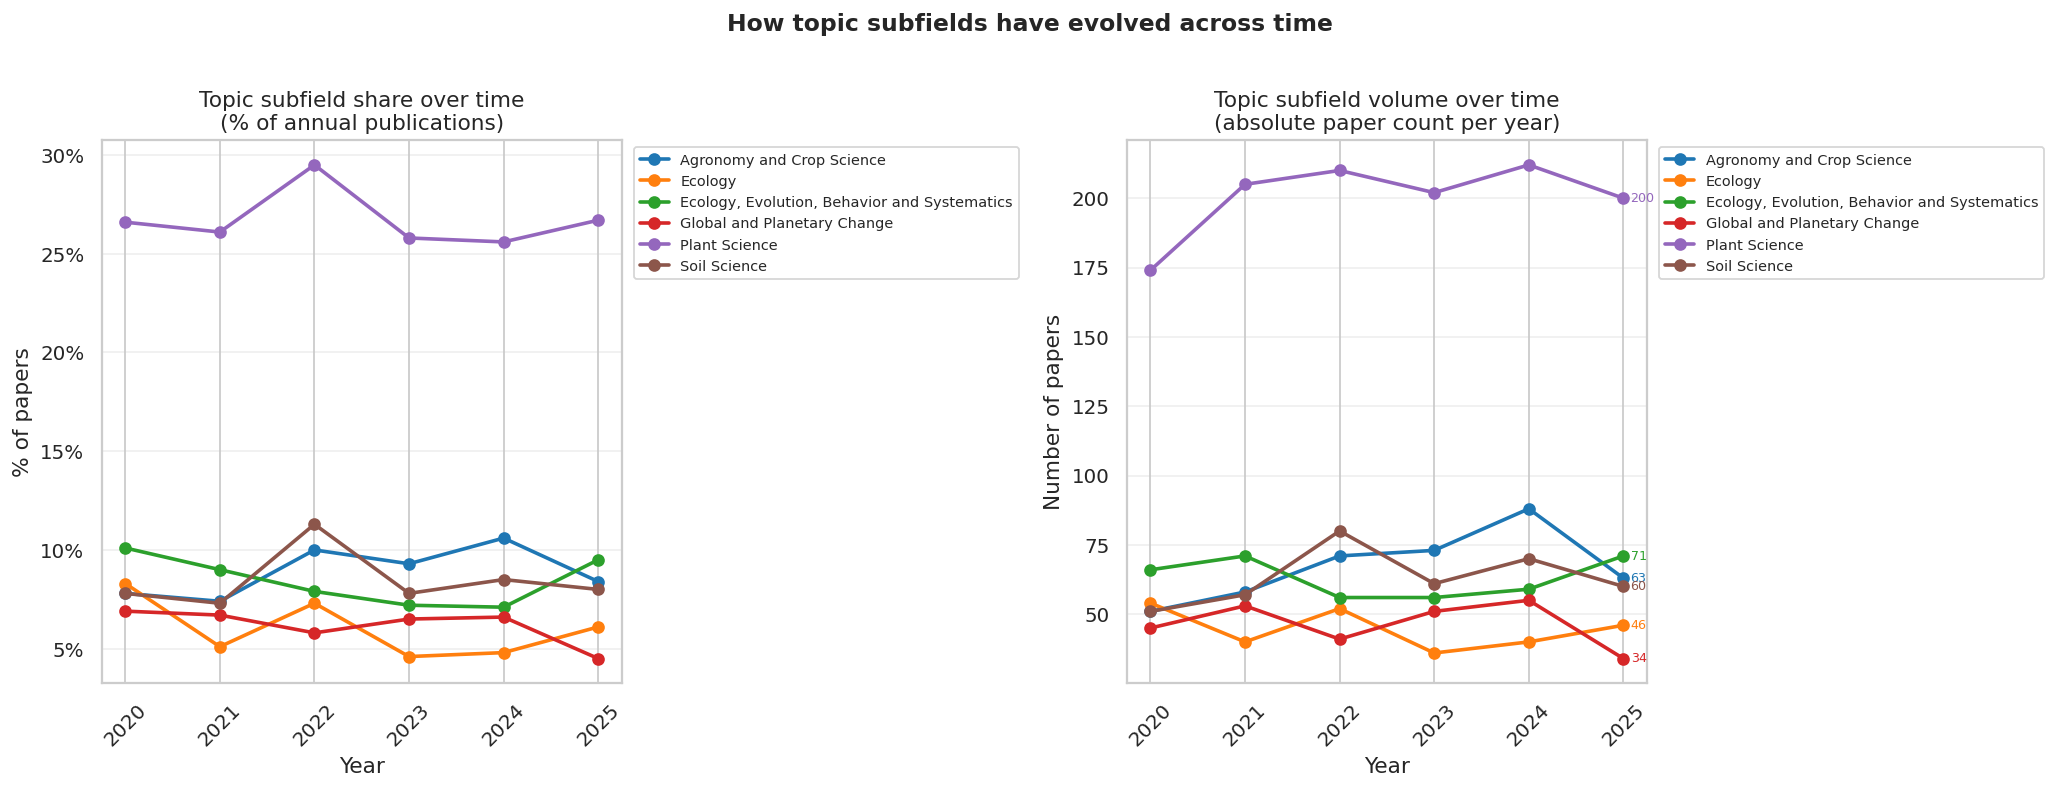


Most common topic subfield per year:
 publication_year top_topic_subfield  n_papers
             2020      Plant Science       174
             2021      Plant Science       205
             2022      Plant Science       210
             2023      Plant Science       202
             2024      Plant Science       212
             2025      Plant Science       200


In [264]:

# ── Topic subfield presence across time ─────────────────────────────────────
topic_yearly_counts = (
    all_df_dedup
    .dropna(subset=["topic_subfield", "publication_year"])
    .groupby(["publication_year", "topic_subfield"])
    .size()
    .reset_index(name="n_papers")
    .sort_values(["publication_year", "n_papers"], ascending=[True, False])
)

# Top topic subfield per year
top_topic_per_year = (
    topic_yearly_counts
    .groupby("publication_year")
    .first()
    .reset_index()[["publication_year", "topic_subfield", "n_papers"]]
    .rename(columns={"topic_subfield": "top_topic_subfield"})
)

# Topic subfield counts and % per year (top 6 subfields)
top6_subfields = (
    all_df_dedup.dropna(subset=["topic_subfield"])
    .groupby("topic_subfield")["article_id"].count()
    .nlargest(6).index.tolist()
)

subfield_yr = (
    all_df_dedup
    .dropna(subset=["topic_subfield", "publication_year"])
    .query("topic_subfield in @top6_subfields")
    .groupby(["publication_year", "topic_subfield"])
    .size()
    .reset_index(name="n")
)
total_per_yr = (
    all_df_dedup.dropna(subset=["publication_year"])
    .groupby("publication_year")["article_id"].count()
    .rename("total")
)
subfield_yr = subfield_yr.merge(total_per_yr.reset_index(), on="publication_year")
subfield_yr["pct"] = (subfield_yr["n"] / subfield_yr["total"] * 100).round(1)

sorted_years = sorted(all_df_dedup["publication_year"].dropna().unique())
colors_list = plt.get_cmap("tab10").colors

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: % share over time
for i, (subfield, grp) in enumerate(subfield_yr.groupby("topic_subfield")):
    grp = grp.sort_values("publication_year")
    axes[0].plot(grp["publication_year"], grp["pct"],
                 marker="o", linewidth=2, label=subfield, color=colors_list[i % 10])
axes[0].set_title("Topic subfield share over time\n(% of annual publications)", fontsize=12)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("% of papers")
axes[0].set_xticks(sorted_years)
axes[0].tick_params(axis="x", rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
axes[0].legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

# Right: absolute paper count over time
for i, (subfield, grp) in enumerate(subfield_yr.groupby("topic_subfield")):
    grp = grp.sort_values("publication_year")
    axes[1].plot(grp["publication_year"], grp["n"],
                 marker="o", linewidth=2, label=subfield, color=colors_list[i % 10])
    # Annotate last data point
    last = grp.iloc[-1]
    axes[1].annotate(
        f"{int(last['n'])}",
        xy=(last["publication_year"], last["n"]),
        xytext=(4, 0), textcoords="offset points",
        fontsize=7, va="center", color=colors_list[i % 10]
    )
axes[1].set_title("Topic subfield volume over time\n(absolute paper count per year)", fontsize=12)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of papers")
axes[1].set_xticks(sorted_years)
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("How topic subfields have evolved across time", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\nMost common topic subfield per year:")
print(top_topic_per_year.to_string(index=False))


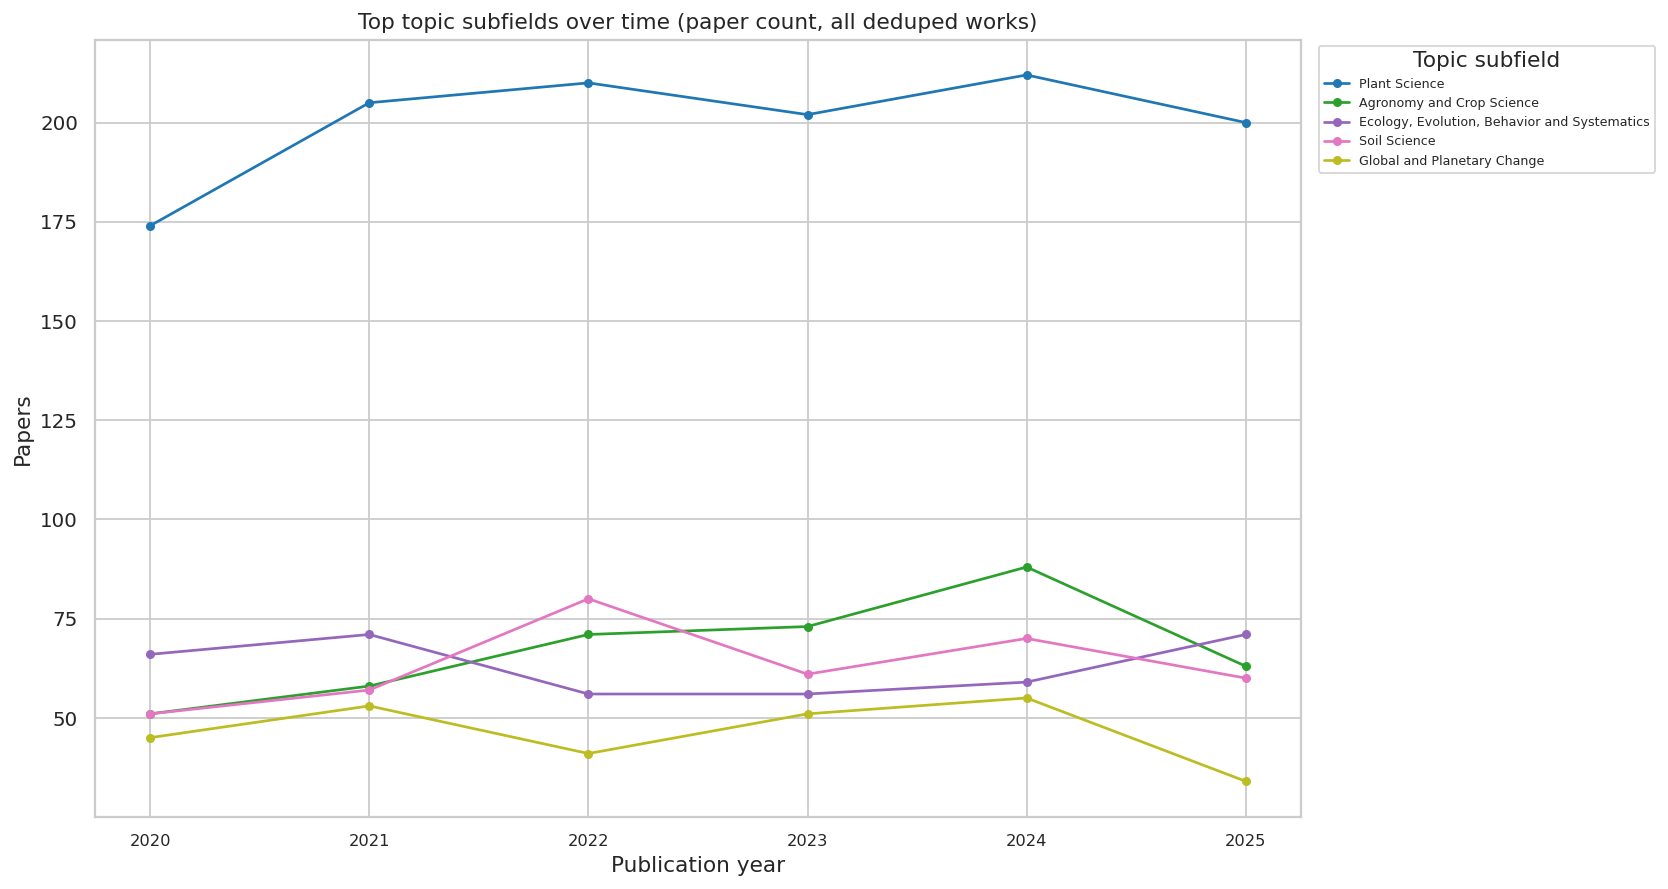

In [265]:

# ── Top topic subfields × year line plot (absolute counts) ───────────────────
top20_topics = (
    all_df_dedup.dropna(subset=["topic_subfield"])
    .groupby("topic_subfield")["article_id"].count()
    .nlargest(5).index.tolist()
)

topic_yr_pivot = (
    all_df_dedup
    .dropna(subset=["topic_subfield", "publication_year"])
    .query("topic_subfield in @top20_topics")
    .groupby(["topic_subfield", "publication_year"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        all_df_dedup.dropna(subset=["topic_subfield"])
        .groupby("topic_subfield")["article_id"].count()
        .reindex(top20_topics)
        .sort_values(ascending=False).index
    )
)

fig, ax = plt.subplots(figsize=(13, 7))
cmap_lines = plt.get_cmap("tab20")
for i, topic in enumerate(topic_yr_pivot.index):
    ax.plot(
        topic_yr_pivot.columns,
        topic_yr_pivot.loc[topic],
        marker="o", markersize=4,
        linewidth=1.5,
        color=cmap_lines(i / len(topic_yr_pivot)),
        label=topic
    )
ax.set_title("Top topic subfields over time (paper count, all deduped works)")
ax.set_xlabel("Publication year")
ax.set_ylabel("Papers")
ax.tick_params(axis="x", rotation=0, labelsize=9)
ax.legend(title="Topic subfield", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()


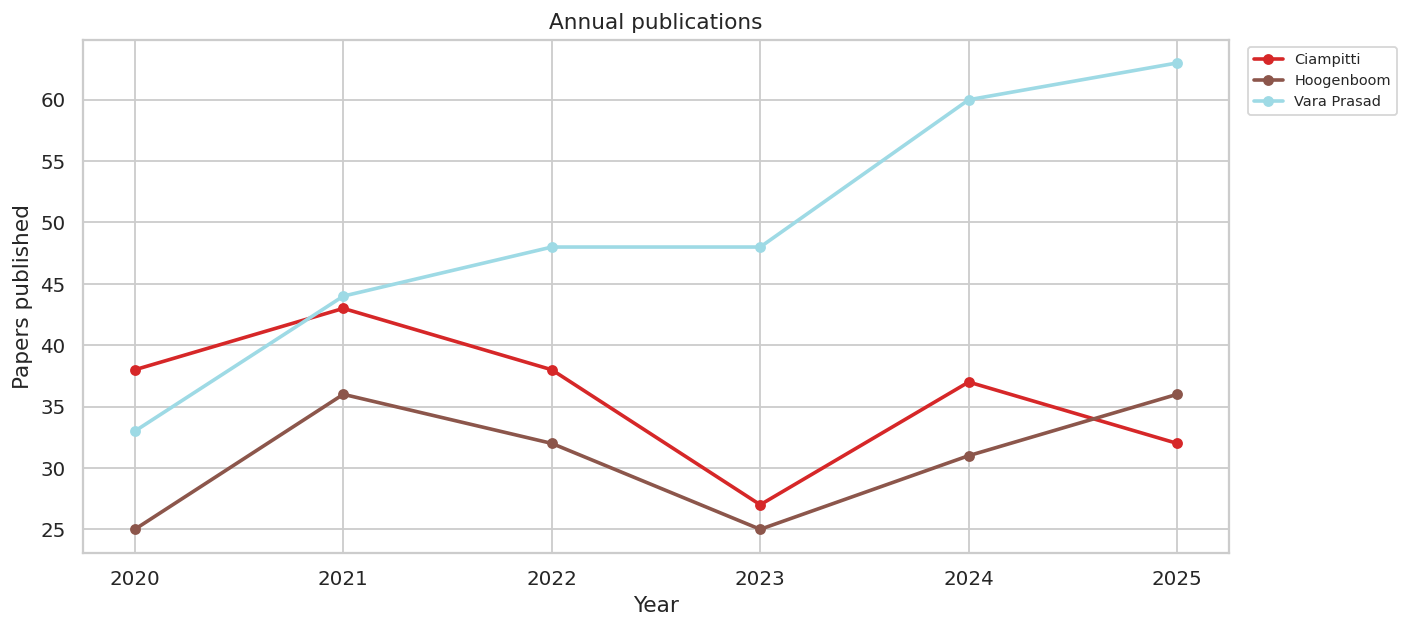

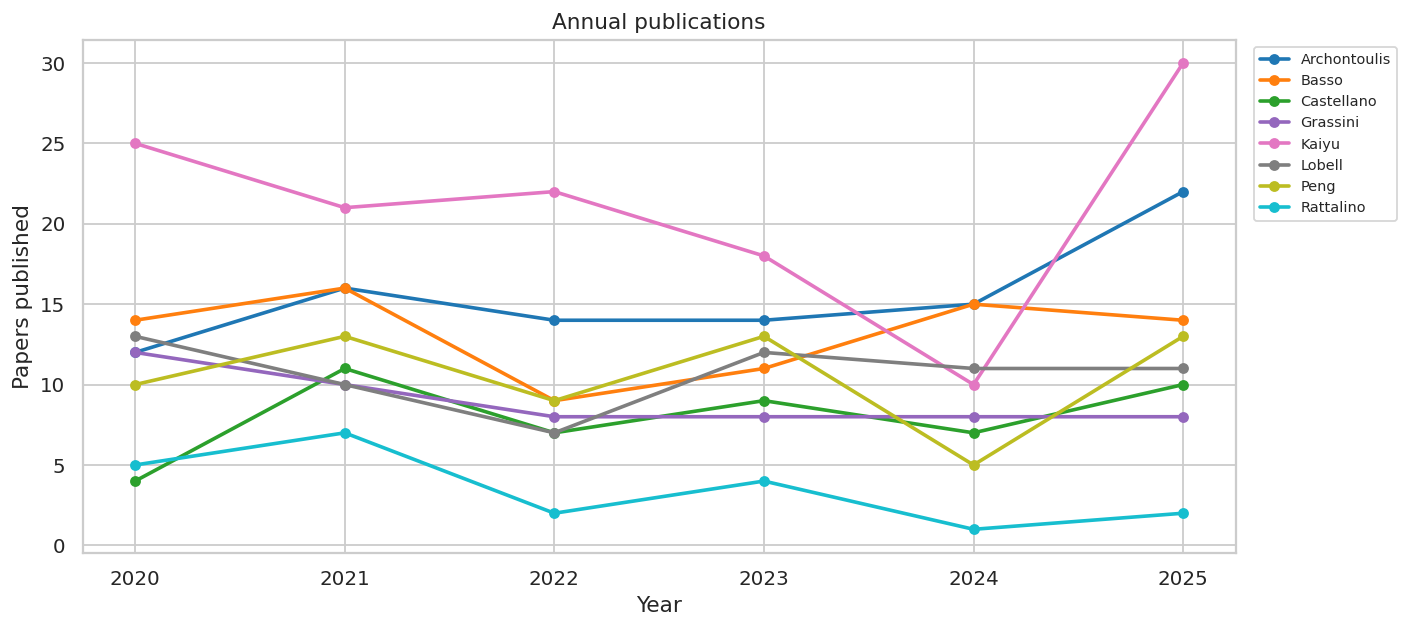

Most prolific Target_author author each year:
 publication_year  top_author  papers
             2020   Ciampitti      38
             2021 Vara Prasad      44
             2022 Vara Prasad      48
             2023 Vara Prasad      48
             2024 Vara Prasad      60
             2025 Vara Prasad      63


In [266]:

# ── Annual publications per Target_author author – line plots by productivity group ──
author_yearly = (
    filtered_TargetA_df
    .dropna(subset=["publication_year"])
    .groupby(["queried_author", "publication_year"])
    .size()
    .reset_index(name="n_papers")
)

# Most prolific author each year
yearly_leader = (
    author_yearly
    .sort_values("n_papers", ascending=False)
    .groupby("publication_year")
    .first()
    .reset_index()[["publication_year", "queried_author", "n_papers"]]
    .rename(columns={"queried_author": "top_author", "n_papers": "papers"})
)

# Split authors: "high output" = >30 papers in at least 2 years
years_above_30 = (
    author_yearly[author_yearly["n_papers"] > 30]
    .groupby("queried_author")
    .size()
)
high_output = years_above_30[years_above_30 >= 2].index.tolist()
low_output  = [a for a in author_yearly["queried_author"].unique() if a not in high_output]

cmap_all = plt.get_cmap("tab20")
all_authors = sorted(author_yearly["queried_author"].unique())
author_colors = {a: cmap_all(i / max(len(all_authors) - 1, 1)) for i, a in enumerate(all_authors)}

for group_label, group_authors in [
    ("High-output authors (>30 papers in ≥2 years)", high_output),
    ("Other authors", low_output),
]:
    if not group_authors:
        continue
    fig, ax = plt.subplots(figsize=(11, 5))
    for author in group_authors:
        grp = author_yearly[author_yearly["queried_author"] == author]
        ax.plot(
            grp["publication_year"], grp["n_papers"],
            marker="o", linewidth=2, markersize=5,
            color=author_colors[author], label=author
        )
    ax.set_title(f"Annual publications")
    ax.set_xlabel("Year")
    ax.set_ylabel("Papers published")
    ax.set_xticks(sorted(filtered_TargetA_df["publication_year"].dropna().unique()))
    ax.tick_params(axis="x", rotation=0)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, frameon=True)
    plt.tight_layout()
    plt.show()

print("Most prolific Target_author author each year:")
print(yearly_leader.to_string(index=False))


---
## 9. Co-authorship Network Overview
How frequently do the Target_author authors collaborate with each other? We extract co-author pairs from the raw `authorships` field and build a collaboration frequency matrix.

In [267]:
# ── Build co-authorship frequency matrix among Target_author authors ────────────────
Target_author_aid_to_name = {aid: name for aid, name in author_ids.items()}
Target_author_names = sorted(author_ids.values())

coauth_matrix = pd.DataFrame(0, index=Target_author_names, columns=Target_author_names)

for work in Target_author_works:
    # All Target_author author IDs on this paper
    present_primaries = [
        Target_author_aid_to_name[auth["author"]["id"]]
        for auth in work.get("authorships", [])
        if auth.get("author", {}).get("id") in Target_author_aid_to_name
    ]
    # For every pair, increment
    for i, a in enumerate(present_primaries):
        for b in present_primaries[i + 1:]:
            coauth_matrix.loc[a, b] += 1
            coauth_matrix.loc[b, a] += 1

print("Co-authorship frequency matrix (Target_author authors only):\n")
print(coauth_matrix.to_string())

Co-authorship frequency matrix (Target_author authors only):

              Archontoulis  Basso  Castellano  Ciampitti  Grassini  Hoogenboom  Kaiyu  Lobell  Peng  Rattalino  Vara Prasad
Archontoulis             0     33          58         17        16          47     36       8    36          9            0
Basso                   33      0           3          0         0          61     32       0    25          0            0
Castellano              58      3           0          7         7           0      3       0     0          0            0
Ciampitti               17      0           7          2         7           0      6       0     3          3          197
Grassini                16      0           7          7         0           0      0       0     0         58            0
Hoogenboom              47     61           0          0         0           0     41       0    33          0            0
Kaiyu                   36     32           3          6         0    

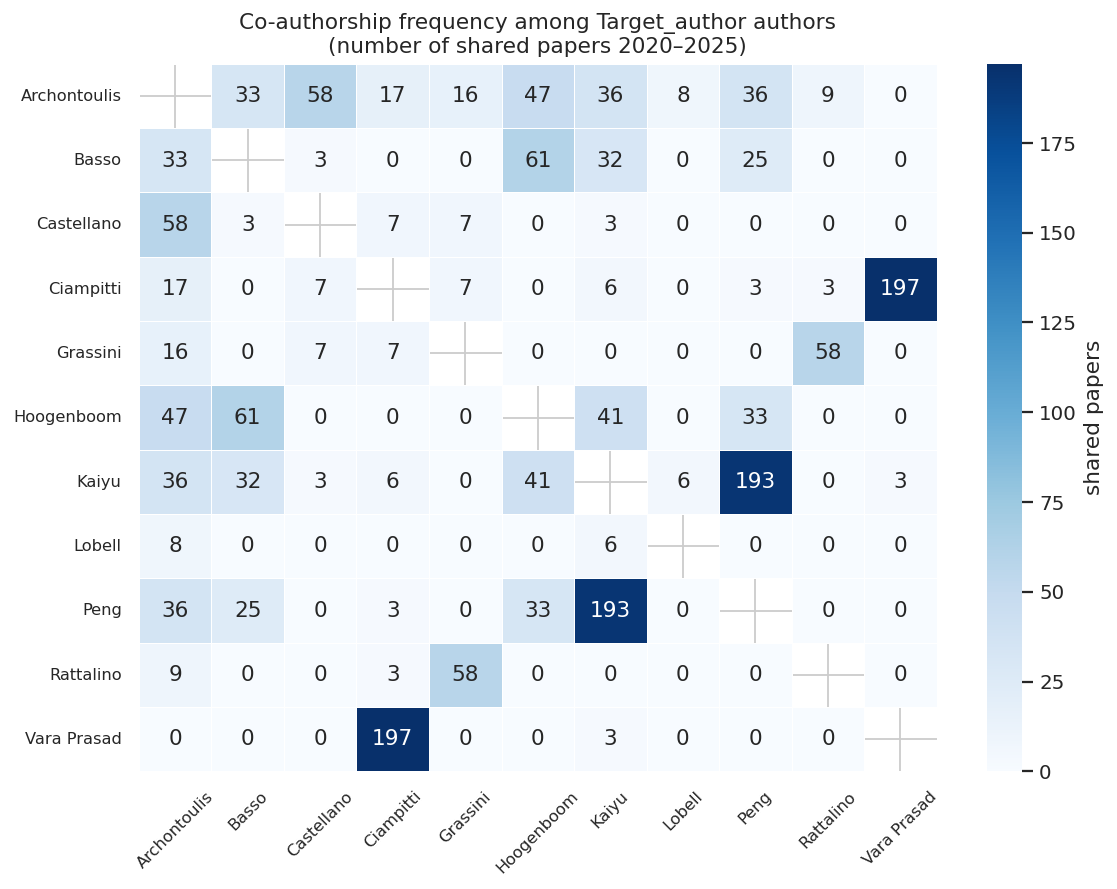

In [268]:
# ── Co-authorship heatmap ─────────────────────────────────────────────────────
mask_diag = np.eye(len(coauth_matrix), dtype=bool)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    coauth_matrix,
    mask=mask_diag,
    annot=True, fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "shared papers"},
    ax=ax,
)
ax.set_title("Co-authorship frequency among Target_author authors\n(number of shared papers 2020–2025)")
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

In [269]:
# ── Network graph of co-authorship (networkx) ─────────────────────────────────
try:
    import networkx as nx

    G = nx.Graph()
    G.add_nodes_from(Target_author_names)

    for i, a in enumerate(Target_author_names):
        for j, b in enumerate(Target_author_names):
            if i < j and coauth_matrix.loc[a, b] > 0:
                G.add_edge(a, b, weight=int(coauth_matrix.loc[a, b]))

    # Node size ∝ total papers
    node_sizes = {
        name: filtered_TargetA_dedup[filtered_TargetA_dedup["queried_author"] == name]["article_id"].nunique()
        for name in Target_author_names
    }

    fig, ax = plt.subplots(figsize=(10, 7))
    pos = nx.spring_layout(G, seed=42, k=1.5)

    nx.draw_networkx_nodes(
        G, pos,
        node_size=[node_sizes.get(n, 10) * 15 for n in G.nodes()],
        node_color="steelblue", alpha=0.85, ax=ax,
    )
    edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
    nx.draw_networkx_edges(
        G, pos,
        width=[w * 0.8 for w in edge_weights],
        edge_color="gray", alpha=0.7, ax=ax,
    )
    nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)

    # Edge labels (weight)
    edge_labels = {(u, v): G[u][v]["weight"] for u, v in G.edges() if G[u][v]["weight"] > 1}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, ax=ax)

    ax.set_title("Co-authorship network — Target_author authors\n(node size ∝ papers, edge width ∝ shared papers)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

except ImportError:
    print("networkx not installed. Run: pip install networkx")
    print("Showing the matrix table instead:")
    print(coauth_matrix.to_string())

networkx not installed. Run: pip install networkx
Showing the matrix table instead:
              Archontoulis  Basso  Castellano  Ciampitti  Grassini  Hoogenboom  Kaiyu  Lobell  Peng  Rattalino  Vara Prasad
Archontoulis             0     33          58         17        16          47     36       8    36          9            0
Basso                   33      0           3          0         0          61     32       0    25          0            0
Castellano              58      3           0          7         7           0      3       0     0          0            0
Ciampitti               17      0           7          2         7           0      6       0     3          3          197
Grassini                16      0           7          7         0           0      0       0     0         58            0
Hoogenboom              47     61           0          0         0           0     41       0    33          0            0
Kaiyu                   36     32           3   

---
## Summary & Next Steps

### What this EDA covered
| Section | Key questions answered |
|---|---|
| API structure | What fields OpenAlex returns and their completeness |
| Publications DF | Shape, types, missing values |
| Citations | Distribution skew, top papers, accumulation speed, OA vs citation lift |
| Authors | Productivity, role breakdown, corresponding-author impact |
| Journals | Publication volume, 2-year citation velocity, OA mix |
| Concepts | Dominant research themes (crop yield, soil, modeling, remote sensing…) and their co-occurrence |
| Temporal | Year-by-year growth, cohort citation curves |
| Network | Which authors collaborate and how intensely |

### Suggested next steps
- **Topic modeling (LDA / BERTopic)** — cluster papers by title/abstract semantics  
- **Abstract-level text analysis** — keyword frequency, n-grams, emerging terms  
- **Field-level benchmarking** — compare these authors to the broader agronomy literature  
- **Citation network** — who cites whom, identify bridge papers  
- **Journal submission strategy** — gap analysis between where authors publish and where high-impact work appears

In [270]:
# #| include: false

# # ── Summary table: field coverage across ALL works ────────────────────
# field_presence = {}
# for work in all_works:
#     for k, v in work.items():
#         is_present = v is not None and v != [] and v != {}
#         field_presence.setdefault(k, 0)
#         if is_present:
#             field_presence[k] += 1

# total = len(all_works)
# coverage = (
#     pd.DataFrame.from_dict(field_presence, orient="index", columns=["present"])
#     .assign(pct=lambda d: (d["present"] / total * 100).round(1))
#     .sort_values("pct", ascending=False)
#     .reset_index()
#     .rename(columns={"index": "field"})
# )

# print(f"Field coverage across {total} works:\n")
# print(coverage.to_string(index=False))


In [271]:
# # ── Summary table: field coverage across ALL Target_author works ────────────────────
# field_presence = {}
# for work in Target_author_works:
#     for k, v in work.items():
#         is_present = v is not None and v != [] and v != {}
#         field_presence.setdefault(k, 0)
#         if is_present:
#             field_presence[k] += 1

# total = len(Target_author_works)
# coverage = (
#     pd.DataFrame.from_dict(field_presence, orient="index", columns=["present"])
#     .assign(pct=lambda d: (d["present"] / total * 100).round(1))
#     .sort_values("pct", ascending=False)
#     .reset_index()
#     .rename(columns={"index": "field"})
# )

# print(f"Field coverage across {total} Target_author works:\n")
# print(coverage.to_string(index=False))

In [272]:
# # ── Missing value audit ────────────────────────────────────────────────────────
# missing = (
#     filtered_df_dedup[base_cols]
#     .isnull()
#     .mean()
#     .mul(100)
#     .round(1)
#     .sort_values(ascending=True)
#     .rename("% missing")
#     .rename_axis("field")
#     .reset_index()
# )

# fig, ax = plt.subplots(figsize=(8, 6))
# ax.barh(missing["field"], missing["% missing"], color="steelblue", edgecolor="white")
# ax.set_xlabel("% missing")
# ax.set_title("Missing values by field (filtered_df_dedup)")
# ax.axvline(5, color="red", linestyle="--", linewidth=0.8, label="5 % threshold")
# ax.legend()
# plt.tight_layout()
# plt.show()

# missing
